# Heads Up: Predicting Late Deliveries Before They Happen
### IT3091 Machine Learning, Group 5. The complete project in one notebook

**Dataset:** DataCo Smart Supply Chain (180,519 order lines, 53 columns).
**Main question (primary lens):** when an order is placed, can we warn the team that it will probably arrive late, while there is still time to act?
**Second question (secondary lens):** if the team cannot chase every warning, which orders should they handle first?

This notebook joins all six of our working notebooks into one story, in the same order we did the work. Nothing is skipped: every step, every check, every mistake we caught and every decision is here, written in simple words and shown with pictures, so that anyone can read it from top to bottom without opening another file.

### How the six notebooks fit into this one

| Part | What it covers | Comes from our notebook |
|---|---|---|
| 1 | Understanding the data and exploring it with pictures | 01 eda |
| 2 | Cleaning the data and splitting it by time | 02 preprocessing |
| 3 | Building the model inputs (features) | 03 feature engineering |
| 4 | A baseline rule and eleven models, compared fairly | 04 model development |
| 5 | Tuning, explaining the model, choosing the alert line, final exam on test data | 05 hyperparameter tuning and evaluation |
| 6 | Ranking orders by priority (risk times order value) | 06 shipment prioritization |
| 7 | Wrap up: comparison table, the app, decision log, limits and lessons | New summary |

### How to read it

Every section has a short plain explanation, then code, then a picture or table, then a line that starts with **What we found**. If you are in a hurry, read only the "What we found" lines and look at the pictures.

### Words used in this notebook

* **Late delivery risk:** a yes or no label. 1 means the order arrived late, 0 means it did not.
* **Recall:** of all the orders that really were late, how many did we catch? This is our main goal.
* **Precision:** of the orders we warned about, how many really were late?
* **F1:** one number that mixes Recall and Precision.
* **ROC AUC and PR AUC:** how well the model puts late orders above on time orders in a ranked list. 0.5 for ROC AUC is a coin toss, 1.0 is perfect.
* **Threshold:** the risk line. If the model's risk is above it, we raise an alert.
* **Leakage:** using information that we would not really have at the time of the order. It makes results look better than they truly are, so we avoid it.
* **Validation set:** data we use to choose settings. **Test set:** data we open only once at the end, like a final exam.

### Final results in one table (so you know where we are going)

| | Random Forest (report model) | XGBoost (live app model) |
|---|---|---|
| Alert threshold (chosen on validation) | 0.38 | 0.39 |
| Test Recall | 0.882 | 0.855 |
| Test Precision | 0.606 | 0.631 |
| Test ROC AUC | 0.752 | 0.772 |
| Test PR AUC | 0.823 | 0.837 |

> **Run it.** Open this file from the `notebooks` folder and choose Run All. It reads the raw data and the saved results from the project folders, and it checks its own numbers against the saved files with `assert` lines. It takes a few minutes.

### Contents

1. Part 1: Data understanding and EDA
2. Part 2: Preprocessing
3. Part 3: Feature engineering
4. Part 4: Baseline and model development
5. Part 5: Tuning, explainability, threshold and final test
6. Part 6: Shipment prioritization
7. Part 7: Wrap up

## Setup

We load our tools, choose one colour palette for every picture, and point to the project folders.

In [1]:
import json, re, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import joblib
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (recall_score, precision_score, f1_score, roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve, confusion_matrix, classification_report)
from IPython.display import Image, display
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60); pd.set_option('display.width', 170); pd.set_option('display.max_colwidth', 160)

ROOT = Path('..') if Path('../data').exists() else Path('.')
RAW    = ROOT / 'data' / 'raw data' / 'DataCoSupplyChainDataset.csv'
DESC   = ROOT / 'data' / 'raw data' / 'DescriptionDataCoSupplyChain.csv'
DATA   = ROOT / 'data' / 'processed'
MODELS = ROOT / 'models'
ART    = ROOT / 'app' / 'backend' / 'artifacts'
IMG    = ROOT / 'app' / 'frontend' / 'public' / 'img'

BLUE, ORANGE, PURPLE, TEAL = '#2a6fdb', '#c8691a', '#8a63d2', '#1b9e8a'
GREY, RED, GREEN, GOLD = '#8a93b0', '#d1344b', '#0c9a76', '#c9a227'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': .25, 'axes.titleweight': 'bold',
                     'axes.titlesize': 11, 'font.size': 9.5})
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print('Project root:', ROOT.resolve())

def show_img(name, width=640, caption=None):
    # shows a figure saved by our earlier runs, if the file is present
    f = IMG / name
    if f.exists():
        if caption: print(caption)
        display(Image(filename=str(f), width=width))

Project root: /tmp/repo


# Part 1. Data understanding and EDA

**Goal of this part.** Before we build anything, we answer the basic questions: what is in the data, can we trust the label we want to predict, which columns are safe to use, and what problems do we need to fix?

We go in this order: schema and dictionary, unit of analysis, missing values and duplicates, target audit, class balance, geography, time, shipping mode and category, numbers and outliers, leakage classification, and a summary.

## 1.1 Loading the data

The file contains some accented letters (for example in city names) that break the normal text reader, so we use the `ISO-8859-1` reader, which is the usual fix for this dataset.

In [2]:
raw = pd.read_csv(RAW, encoding='ISO-8859-1')
print(f'Shape: {raw.shape[0]:,} rows and {raw.shape[1]} columns')
raw.head(3)

Shape: 180,519 rows and 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


## 1.2 Schema and data dictionary

For every column we list its type, how many different values it has, how much is missing, and an example. We also read the description file that came with the dataset, so each column has a plain meaning.

In [3]:
schema = pd.DataFrame({
    'column': raw.columns,
    'type': raw.dtypes.astype(str).values,
    'unique_values': raw.nunique().values,
    'missing': raw.isnull().sum().values,
    'missing_pct': (raw.isnull().mean().values * 100).round(2),
    'example': [raw[c].dropna().iloc[0] if raw[c].notna().any() else None for c in raw.columns]})
desc = pd.read_csv(DESC, encoding='ISO-8859-1')
desc.columns = [c.strip() for c in desc.columns]
print('Columns of the description file:', list(desc.columns))
schema.sort_values('missing_pct', ascending=False).head(10)

Columns of the description file: ['FIELDS', 'DESCRIPTION']


,column,type,unique_values,missing,missing_pct,example
46,Product Description,float64,0,180519,100.00,None
43,Order Zipcode,float64,609,155679,86.24,99301.0
2,Days for shipment (scheduled),int64,4,0,0.00,4
1,Days for shipping (real),int64,7,0,0.00,3
0,Type,str,4,0,0.00,DEBIT
5,Delivery Status,str,4,0,0.00,Advance shipping
6,Late_delivery_risk,int64,2,0,0.00,0
7,Category Id,int64,51,0,0.00,73
8,Category Name,str,50,0,0.00,Sporting Goods
9,Customer City,str,563,0,0.00,Caguas


In [4]:
# Full data dictionary with the plain meaning from the description file
name_col = desc.columns[0]; meaning_col = desc.columns[1]
meaning = dict(zip(desc[name_col].astype(str).str.strip(), desc[meaning_col].astype(str).str.strip().str.lstrip(': ').str.strip()))
schema['meaning'] = schema['column'].map(meaning)
schema.to_csv(DATA / 'data_dictionary_raw_columns.csv', index=False)
print('Saved data_dictionary_raw_columns.csv with', len(schema), 'columns. A short look:')
schema[['column', 'type', 'unique_values', 'missing_pct', 'meaning']].head(12)

Saved data_dictionary_raw_columns.csv with 53 columns. A short look:


,column,type,unique_values,missing_pct,meaning
0,Type,str,4,0.0,Type of transaction made
1,Days for shipping (real),int64,7,0.0,Actual shipping days of the purchased product
2,Days for shipment (scheduled),int64,4,0.0,Days of scheduled delivery of the purchased product
3,Benefit per order,float64,21998,0.0,Earnings per order placed
4,Sales per customer,float64,2927,0.0,Total sales per customer made per customer
5,Delivery Status,str,4,0.0,"Delivery status of orders: Advance shipping , Late delivery , Shipping canceled , Shipping on time"
6,Late_delivery_risk,int64,2,0.0,"Categorical variable that indicates if sending is late (1), it is not late (0)."
7,Category Id,int64,51,0.0,Product category code
8,Category Name,str,50,0.0,Description of the product category
9,Customer City,str,563,0.0,City where the customer made the purchase


**What we found**

* The file has the correct size: 180,519 rows and 53 columns.
* `Product Description` is 100 percent empty. It carries no information, so we drop it.
* `Order Zipcode` is about 86 percent empty. This looks structural (zip codes only apply to some countries) and not random. We confirm this in Part 2.
* `Customer Lname` (8 missing) and `Customer Zipcode` (3 missing) are tiny and do not matter.
* Everything else is fully filled. This dataset is clean, so our cleaning work is small and targeted.
* `Customer Country` has only 2 values (Puerto Rico and US) while `Order Country` has 164. The customer side of the data is limited, so all our place features use `Order Country`, `Order Region` and `Order City`.
* `Category Id` has 51 values but `Category Name` has 50. We check this properly in Part 2.
* `order date (DateOrders)` is stored as text, so we turn it into real dates before using it.

## 1.3 Unit of analysis: one row is not one order

We want one prediction per **order**. Let us check what one row of this file really is.

In [5]:
n_rows, n_orders = len(raw), raw['Order Id'].nunique()
print(f'Rows: {n_rows:,}')
print(f'Unique Order Id values: {n_orders:,}')
print(f'Unique Order Item Id values: {raw["Order Item Id"].nunique():,}')
print(f'Average lines per order: {n_rows / n_orders:.2f}')

# Look at the busiest order
sample_id = raw['Order Id'].value_counts().index[0]
raw.loc[raw['Order Id'] == sample_id, ['Order Id', 'Delivery Status', 'Late_delivery_risk', 'Sales', 'Order Item Quantity', 'Order Item Product Price']]

Rows: 180,519
Unique Order Id values: 65,752
Unique Order Item Id values: 180,519
Average lines per order: 2.75


,Order Id,Delivery Status,Late_delivery_risk,Sales,Order Item Quantity,Order Item Product Price
49,45461,Shipping on time,0,79.980003,2,39.990002
515,45461,Shipping on time,0,200.000000,4,50.000000
112661,45461,Shipping on time,0,149.940002,3,49.980000
179242,45461,Shipping on time,0,129.990005,1,129.990005
179305,45461,Shipping on time,0,199.979996,2,99.989998


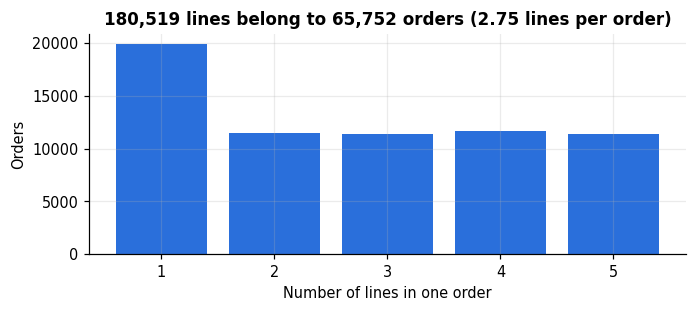

In [6]:
lines = raw.groupby('Order Id').size()
fig, ax = plt.subplots(figsize=(7, 2.6))
vc = lines.value_counts().sort_index()
ax.bar(vc.index, vc.values, color=BLUE)
ax.set_xlabel('Number of lines in one order'); ax.set_ylabel('Orders')
ax.set_title(f'{n_rows:,} lines belong to {n_orders:,} orders ({n_rows / n_orders:.2f} lines per order)')
plt.show()

**What we found**

* The data is at **order line** level, not order level. 180,519 lines belong to 65,752 orders, which is 2.75 lines per order.
* The delivery outcome is the same on every line of an order (an order is delivered once). So the target can be collapsed cleanly to one value per order.
* Numbers such as price, quantity and sales differ between lines, so each needs a clear rule when we combine lines. We write those rules in Part 2.

**Decision logged:** the unit of analysis is the order, and every column gets its own combining rule.

## 1.4 Missing values and duplicates

,column,missing,missing_pct
14,Customer Lname,8,0.00
19,Customer Zipcode,3,0.00
43,Order Zipcode,155679,86.24
46,Product Description,180519,100.00


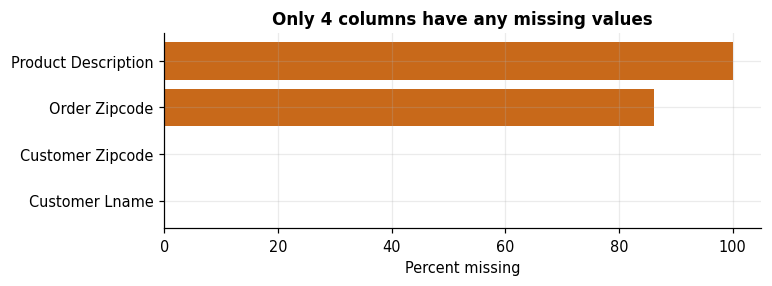

Exact duplicate rows: 0
Repeated Order Id values: 114,767 (expected, because one order has many lines)


In [7]:
miss = schema[schema['missing'] > 0].sort_values('missing_pct')
display(miss[['column', 'missing', 'missing_pct']])
fig, ax = plt.subplots(figsize=(7, 2.3))
ax.barh(miss['column'], miss['missing_pct'], color=ORANGE); ax.set_xlabel('Percent missing'); ax.set_title('Only 4 columns have any missing values')
plt.show()
print('Exact duplicate rows:', raw.duplicated().sum())
print('Repeated Order Id values:', f"{raw['Order Id'].duplicated().sum():,}", '(expected, because one order has many lines)')

**What we found**

* Only 4 columns have missing values: `Product Description` (100 percent), `Order Zipcode` (86.24 percent), and two tiny ones.
* There are **zero** exact duplicate rows, so no de duplication is needed.
* The 114,767 repeated order ids are not a problem. They are simple arithmetic: 180,519 lines minus 65,752 orders.

**Bottom line:** very little imputation work. We drop one column outright, study one more, and ignore the tiny ones.

## 1.5 Target audit: can we trust `Late_delivery_risk`?

We do not trust a ready made label blindly. We cross check it against the detailed `Delivery Status` column, and in particular we look at how `Shipping canceled` orders are labelled.

Late_delivery_risk,0,1,All
Delivery Status,,,
Advance shipping,41592,0,41592
Late delivery,0,98977,98977
Shipping canceled,7754,0,7754
Shipping on time,32196,0,32196
All,81542,98977,180519


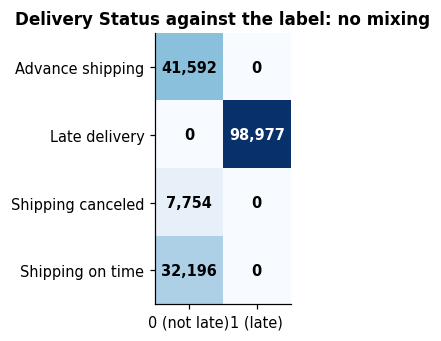

In [8]:
audit = pd.crosstab(raw['Delivery Status'], raw['Late_delivery_risk'], margins=True)
display(audit)
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ct = pd.crosstab(raw['Delivery Status'], raw['Late_delivery_risk'])
im = ax.imshow(ct.values, cmap='Blues'); ax.grid(False)
ax.set_xticks([0, 1]); ax.set_xticklabels(['0 (not late)', '1 (late)']); ax.set_yticks(range(len(ct))); ax.set_yticklabels(ct.index)
for (i, j), v in np.ndenumerate(ct.values):
    ax.text(j, i, f'{v:,}', ha='center', va='center', color='white' if v > ct.values.max() / 2 else 'black', fontweight='bold')
ax.set_title('Delivery Status against the label: no mixing')
plt.show()

**What we found**

The audit is completely clean. Every `Delivery Status` maps to exactly one label value:

| Delivery Status | Lines | Late_delivery_risk |
|---|---|---|
| Advance shipping | 41,592 | 0 |
| Shipping on time | 32,196 | 0 |
| **Shipping canceled** | **7,754** | **0** |
| Late delivery | 98,977 | 1 |

So we can use `Late_delivery_risk` as our target, and we have written proof that we checked.

**One real judgement call.** `Shipping canceled` (about 4.3 percent of lines) is labelled 0, the same as a good delivery. A canceled order is not really a success, but it is not a late delivery either. We considered three options: keep as is, remove canceled orders from training, or flag them separately. **We kept the label as is.** It is the simplest and most defensible choice, and now it is an evidence based choice and not a silent default.

## 1.6 Class balance

Late_delivery_risk
1    98977
0    81542
Late_delivery_risk
1    54.83
0    45.17


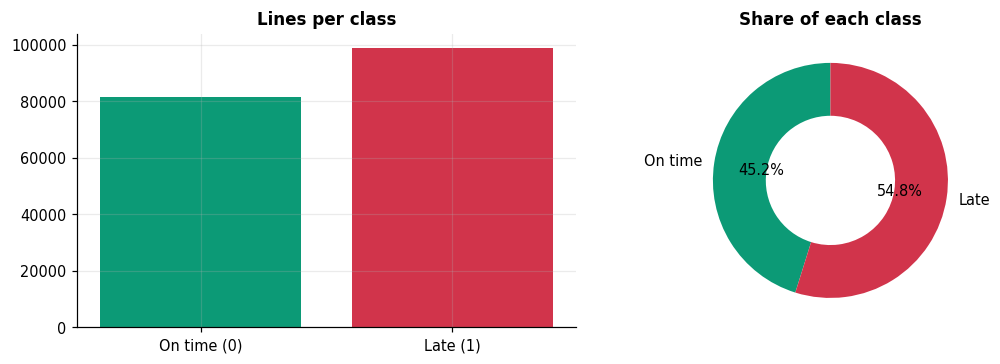

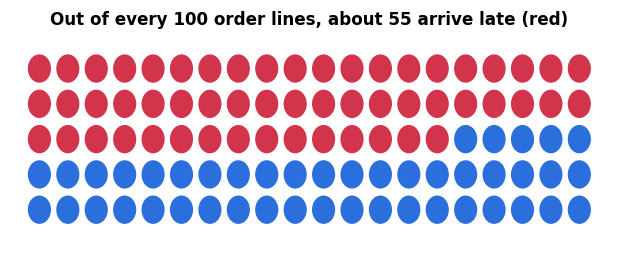

In [9]:
cc = raw['Late_delivery_risk'].value_counts(); cp = raw['Late_delivery_risk'].value_counts(normalize=True) * 100
print(cc.to_string()); print(cp.round(2).to_string())
fig, axs = plt.subplots(1, 2, figsize=(10, 3.4))
axs[0].bar(['On time (0)', 'Late (1)'], [cc[0], cc[1]], color=[GREEN, RED]); axs[0].set_title('Lines per class')
axs[1].pie([cp[0], cp[1]], labels=['On time', 'Late'], colors=[GREEN, RED], autopct='%1.1f%%', startangle=90, wedgeprops={'width': .45})
axs[1].set_title('Share of each class')
plt.tight_layout(); plt.show()

# 100 dot picture
n_late = round(cp[1])
fig, ax = plt.subplots(figsize=(7, 2.5))
for i in range(100):
    r, c = divmod(i, 20); ax.add_patch(plt.Circle((c, -r), .38, color=RED if i < n_late else BLUE))
ax.set_xlim(-1, 20); ax.set_ylim(-5, 1); ax.axis('off'); ax.set_title(f'Out of every 100 order lines, about {n_late} arrive late (red)')
plt.show()

**What we found**

* 98,977 late lines (54.83 percent) against 81,542 not late (45.17 percent). The classes are close to balanced.
* So we do not need special tricks for imbalance (no SMOTE, no heavy class weights).
* **We still make Recall our main goal, and the reason is precise:** it is a cost argument, not an imbalance argument. Missing a late delivery costs the business more than a false alarm. A missed late order means nobody acts. A false alarm only means someone looked at an order that turned out fine.
* Because more than half of all deliveries are late, a model that says "everything is late" has 100 percent Recall. So we must always look at Recall together with Precision and ranking quality.

## 1.7 Geographic patterns

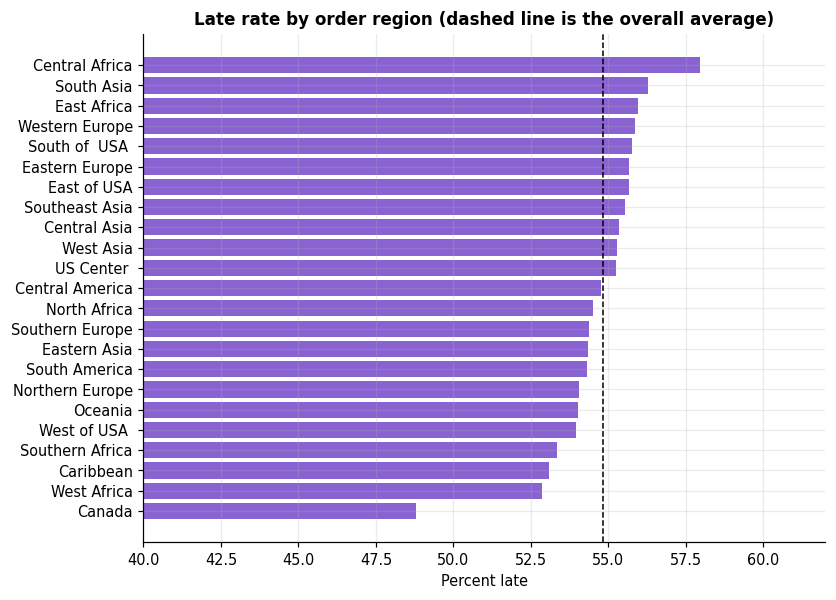

Region spread: 48.8 to 58.0 percent, about 9 points


In [10]:
reg = raw.groupby('Order Region')['Late_delivery_risk'].agg(['mean', 'count']).sort_values('mean')
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(reg.index, reg['mean'] * 100, color=PURPLE)
ax.axvline(raw['Late_delivery_risk'].mean() * 100, color='black', ls='--', lw=1)
ax.set_xlabel('Percent late'); ax.set_title('Late rate by order region (dashed line is the overall average)'); ax.set_xlim(40, 62)
plt.show()
print(f'Region spread: {reg["mean"].min()*100:.1f} to {reg["mean"].max()*100:.1f} percent, about {(reg["mean"].max()-reg["mean"].min())*100:.0f} points')

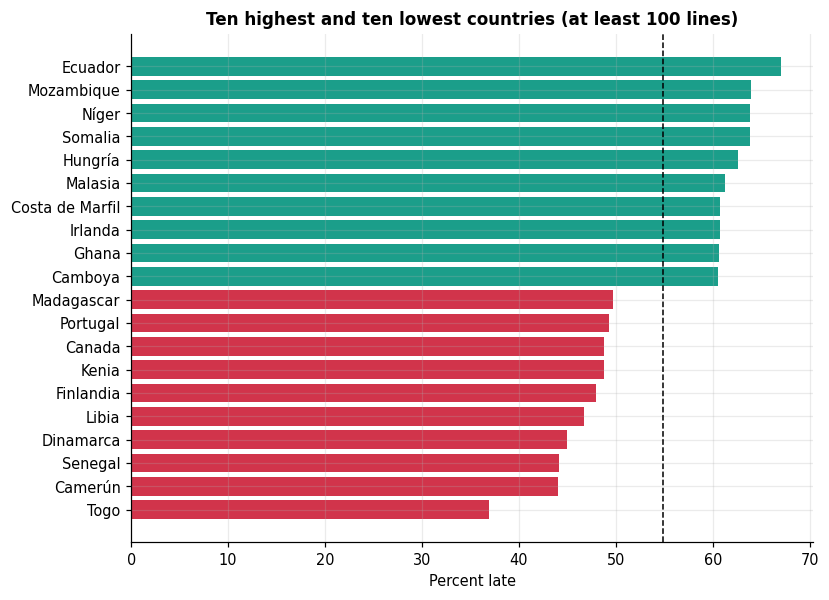

Country spread: 36.9 to 67.0 percent, about 30 points


In [11]:
cty = raw.groupby('Order Country')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
cty = cty[cty['count'] >= 100].sort_values('mean', ascending=False)
sel = pd.concat([cty.head(10), cty.tail(10)]).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(sel['Order Country'], sel['mean'] * 100, color=[RED] * 10 + [TEAL] * 10)
ax.axvline(raw['Late_delivery_risk'].mean() * 100, color='black', ls='--', lw=1)
ax.set_xlabel('Percent late'); ax.set_title('Ten highest and ten lowest countries (at least 100 lines)')
plt.show()
print(f'Country spread: {cty["mean"].min()*100:.1f} to {cty["mean"].max()*100:.1f} percent, about {(cty["mean"].max()-cty["mean"].min())*100:.0f} points')

**What we found**

* The spread across **regions** is narrow: about 9 points, around the 54.8 percent average. Region is only a moderate signal.
* The spread across **countries** is much wider: from about 37 percent (Togo) to about 67 percent (Ecuador), roughly 30 points. Country carries more detail. Some extreme countries have few orders (Togo has only 122), so treat their exact rates as a guide, not as certain.
* **A fairness note.** Central Africa, South Asia and East Africa show the highest region rates. In our final recommendation, region linked risk should lead to extra logistics support for those regions, and must never be a reason to give them worse service.
* *(We first thought the country names mixed English and Spanish. Part 2 corrects this.)*

**Decision logged:** country level late rate is a stronger feature candidate than region level.

## 1.8 Patterns over time

Date range: 2015-01-01 00:00:00 to 2018-01-31 23:38:00


,mean,count
order_year,,
2015,0.548635,62650
2016,0.550695,62550
2017,0.544477,53196
2018,0.562883,2123


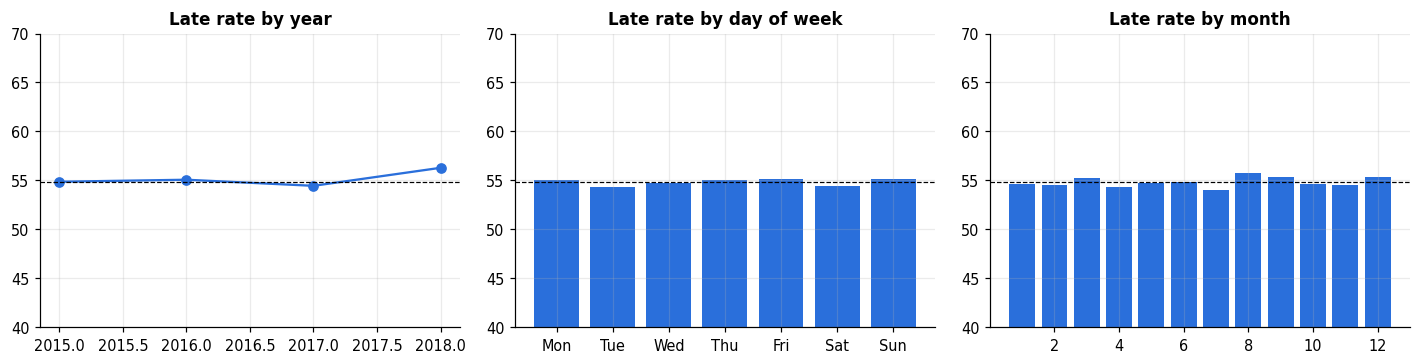

In [12]:
raw['order_dt'] = pd.to_datetime(raw['order date (DateOrders)'], errors='coerce')
raw['order_year'] = raw['order_dt'].dt.year; raw['order_month'] = raw['order_dt'].dt.month
raw['order_dow'] = raw['order_dt'].dt.day_name(); raw['order_hour'] = raw['order_dt'].dt.hour
print('Date range:', raw['order_dt'].min(), 'to', raw['order_dt'].max())
yr = raw.groupby('order_year')['Late_delivery_risk'].agg(['mean', 'count']); display(yr)

fig, axs = plt.subplots(1, 3, figsize=(13, 3.4))
axs[0].plot(yr.index, yr['mean'] * 100, 'o-', color=BLUE); axs[0].set_ylim(40, 70); axs[0].set_title('Late rate by year')
dow = raw.groupby('order_dow')['Late_delivery_risk'].mean().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']) * 100
axs[1].bar([d[:3] for d in dow.index], dow.values, color=BLUE); axs[1].set_ylim(40, 70); axs[1].set_title('Late rate by day of week')
mon = raw.groupby('order_month')['Late_delivery_risk'].mean() * 100
axs[2].bar(mon.index, mon.values, color=BLUE); axs[2].set_ylim(40, 70); axs[2].set_title('Late rate by month')
for a in axs: a.axhline(raw['Late_delivery_risk'].mean() * 100, color='black', ls='--', lw=.8)
plt.tight_layout(); plt.show()

**What we found**

* The data runs from January 2015 to January 2018. The 2018 slice is tiny (2,123 lines, one month).
* The late rate is stable year after year (about 54 to 56 percent). There is no drift.
* Day of week and month are flat too (about 53 to 55 percent). Calendar columns will not help much on their own.
* **What this means for the split.** Stability weakens the "drift" argument for splitting by time, but the thin 2018 tail makes a strict calendar split (train 2015 to 2017, test 2018) a poor choice anyway, because that test set would be only one month of January.

**Decision logged:** we split by **proportion over time**: sort by order date, and keep the most recent part as test (roughly mid 2017 to January 2018). This keeps the rule "test on the future, never on a random shuffle", without a tiny test set.

## 1.9 Shipping mode and product category

,late_percent,count
Shipping Mode,,
First Class,95.32,27814
Second Class,76.63,35216
Same Day,45.74,9737
Standard Class,38.07,107752


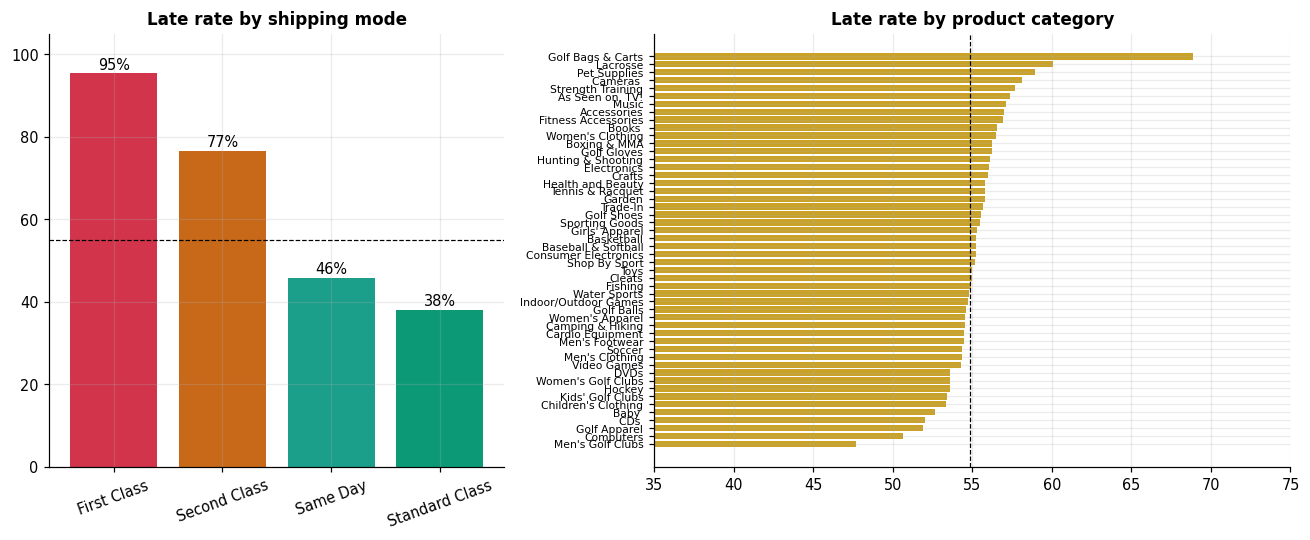

Category spread: 48 to 69 percent


In [13]:
sm = raw.groupby('Shipping Mode')['Late_delivery_risk'].agg(['mean', 'count']).sort_values('mean', ascending=False)
display(sm.assign(mean=(sm['mean'] * 100).round(2)).rename(columns={'mean': 'late_percent'}))
fig, axs = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1.4]})
axs[0].bar(sm.index, sm['mean'] * 100, color=[RED, ORANGE, TEAL, GREEN])
for i, v in enumerate(sm['mean'] * 100): axs[0].text(i, v + 1, f'{v:.0f}%', ha='center')
axs[0].axhline(raw['Late_delivery_risk'].mean() * 100, color='black', ls='--', lw=.8); axs[0].set_ylim(0, 105)
axs[0].set_title('Late rate by shipping mode'); axs[0].tick_params(axis='x', rotation=20)
ct = raw.groupby('Category Name')['Late_delivery_risk'].agg(['mean', 'count']); ct = ct[ct['count'] >= 50].sort_values('mean')
axs[1].barh(ct.index, ct['mean'] * 100, color=GOLD); axs[1].axvline(raw['Late_delivery_risk'].mean() * 100, color='black', ls='--', lw=.8)
axs[1].set_xlim(35, 75); axs[1].set_title('Late rate by product category'); axs[1].tick_params(axis='y', labelsize=7)
plt.tight_layout(); plt.show()
print(f'Category spread: {ct["mean"].min()*100:.0f} to {ct["mean"].max()*100:.0f} percent')

**What we found**

**Shipping mode is by far the strongest signal in the whole EDA.**

| Shipping Mode | Late rate | Lines |
|---|---|---|
| First Class | **95.32%** | 27,814 |
| Second Class | 76.63% | 35,216 |
| Same Day | 45.74% | 9,737 |
| Standard Class | 38.07% | 107,752 |

That is a 57 point spread, much wider than region (9 points) or country (30 points). **Likely reason:** faster modes promise tighter delivery windows, so even a small real delay counts as "late" against a one day promise but not against a four day promise. This is a real operational pattern, not a data mistake.

* This feature will probably dominate every model. It also means a simple rule based on shipping mode is a tough baseline, not a token one.
* `Shipping Mode` and `Days for shipment (scheduled)` may carry the same information. We test that in Part 3.
* Product category has a moderate spread (about 21 points), a real but secondary signal.

## 1.10 Numbers and outliers

,Sales,Benefit per order,Order Item Quantity,Days for shipment (scheduled)
count,180519.00,180519.00,180519.00,180519.00
mean,203.77,21.97,2.13,2.93
std,132.27,104.43,1.45,1.37
min,9.99,-4274.98,1.00,0.00
25%,119.98,7.00,1.00,2.00
50%,199.92,31.52,1.00,4.00
75%,299.95,64.80,3.00,4.00
max,1999.99,911.80,5.00,4.00


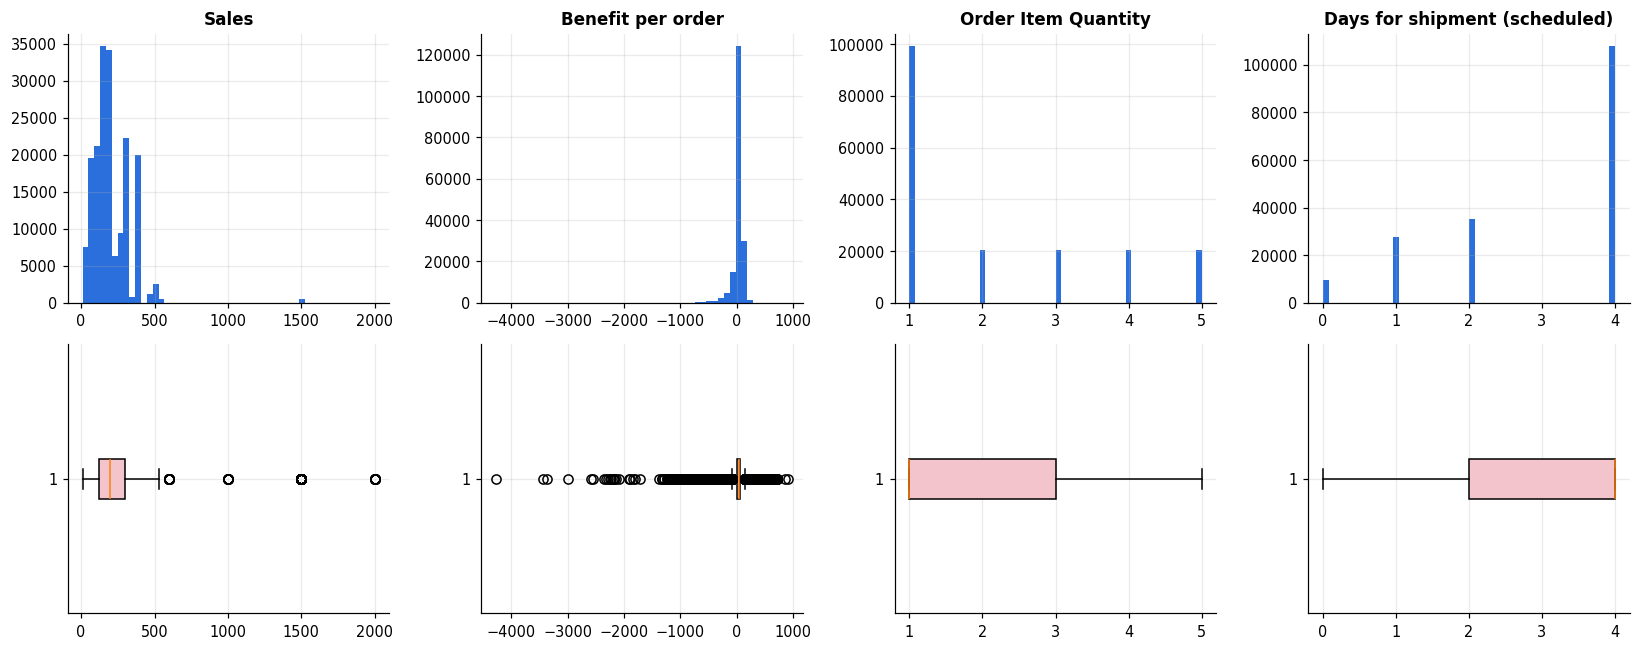

Sales: 488 outliers (0.27%) by the IQR rule
Benefit per order: 18,942 outliers (10.49%) by the IQR rule
Order Item Quantity: 0 outliers (0.00%) by the IQR rule
Days for shipment (scheduled): 0 outliers (0.00%) by the IQR rule


In [14]:
num_cols = ['Sales', 'Benefit per order', 'Order Item Quantity', 'Days for shipment (scheduled)']
display(raw[num_cols].describe().round(2))
fig, axs = plt.subplots(2, 4, figsize=(15, 6))
for i, c in enumerate(num_cols):
    axs[0, i].hist(raw[c], bins=50, color=BLUE); axs[0, i].set_title(f'{c}')
    axs[1, i].boxplot(raw[c], vert=False, patch_artist=True, boxprops=dict(facecolor='#f3c4cb'))
plt.tight_layout(); plt.show()
for c in num_cols:
    q1, q3 = raw[c].quantile([.25, .75]); iqr = q3 - q1
    n = ((raw[c] < q1 - 1.5 * iqr) | (raw[c] > q3 + 1.5 * iqr)).sum()
    print(f'{c}: {n:,} outliers ({n / len(raw) * 100:.2f}%) by the IQR rule')

**What we found**

| Column | Outliers (IQR rule) | Note |
|---|---|---|
| `Sales` | 488 (0.27%) | Slightly right skewed, not a concern |
| `Benefit per order` | **18,942 (10.49%)** | **Needs a real decision** |
| `Order Item Quantity` | 0 | Whole numbers 1 to 5, nothing to do |
| `Days for shipment (scheduled)` | 0 | Whole numbers 0 to 4, nothing to do |

`Benefit per order` is extreme: the average is about 22 dollars, but the lowest is about minus 4,275 and the highest about 912. These are real big losses, not errors. They matter for the second lens: should an order that loses a lot of money count as "high value"? We decided to (1) cap `Benefit per order` for model stability and (2) use **Sales**, which is always positive, as the "value" in the priority formula, so a loss making order is never mistaken for a valuable one.

**Is using Sales and Benefit as model inputs leakage?** No. Both are known when the order is placed. Nothing in the EDA suggested they act as a hidden shortcut. The real issue here is outliers, which is a data quality issue, not leakage.

## 1.11 Leakage field classification

This table is our reference for every later step. A column is **safe** only if we truly know it at the moment the order is placed.

In [15]:
role = {
 'Late_delivery_risk': 'target', 'Delivery Status': 'excluded (the target comes from it)',
 'Days for shipping (real)': 'excluded (known only after delivery)', 'shipping date (DateOrders)': 'excluded (known only after shipping)',
 'Shipping Mode': 'safe', 'Days for shipment (scheduled)': 'safe', 'Order Region': 'safe', 'Order Country': 'safe',
 'Order City': 'safe', 'Order State': 'safe', 'Category Name': 'safe', 'Category Id': 'safe', 'Order Item Quantity': 'safe',
 'Order Item Product Price': 'safe', 'Sales': 'safe', 'Benefit per order': 'safe', 'Customer Segment': 'safe', 'Type': 'safe',
 'order date (DateOrders)': 'safe', 'Order Id': 'id (used only for grouping lines)',
 'Product Description': 'dropped (100 percent empty)', 'Order Zipcode': 'dropped (86 percent empty)',
 'Customer Email': 'dropped (private, no signal)', 'Customer Password': 'dropped (private, no signal)', 'Product Image': 'dropped (no signal)'}
cls = pd.DataFrame({'column': list(role), 'classification': list(role.values())})
cls

,column,classification
0,Late_delivery_risk,target
1,Delivery Status,excluded (the target comes from it)
2,Days for shipping (real),excluded (known only after delivery)
3,shipping date (DateOrders),excluded (known only after shipping)
4,Shipping Mode,safe
5,Days for shipment (scheduled),safe
6,Order Region,safe
7,Order Country,safe
8,Order City,safe
9,Order State,safe


## 1.12 EDA summary

| # | Finding | What we do about it |
|---|---|---|
| 1 | Data is at order line level: 65,752 orders, 2.75 lines each. The target is the same on every line of an order. | Combine lines into one row per order, with a rule for each column. |
| 2 | Target audit is clean. `Shipping canceled` (4.3 percent) is coded 0. | Keep `Late_delivery_risk` as is, as a documented decision. |
| 3 | 54.83 percent late, 45.17 percent not late. | No imbalance tricks. Recall is the main goal because of cost, not imbalance. |
| 4 | Late rate is stable over time. The 2018 tail is thin. Day and month are flat. | Split by time in proportions, not by calendar year. |
| 5 | Country spread (30 points) is much wider than region spread (9 points). | Use a country level late rate as a feature. |
| 6 | Shipping mode spread is 57 points. Category spread is 21 points. | Check shipping mode against scheduled days. A rule baseline is a tough benchmark. |
| 7 | `Benefit per order` has 10.49 percent outliers and a minimum of minus 4,275. | Cap it. Use Sales as the value in the priority formula. |
| 8 | All planned inputs are known at order time. | Use the leakage table above as the reference. |

# Part 2. Preprocessing

**Input:** the raw order line data. **Output:** clean train, validation and test files with one row per order.

We work in five steps: (1) combine lines into orders, (2) deal with missing values, (3) standardize categories, (4) handle outliers, (5) split by time. Several steps here differ from what a quick default would do, because looking at the data directly showed real problems worth catching before modelling.

## 2.1 Combining order lines into orders

Before choosing a rule for each column, we check which columns are really the same on every line of an order, and which ones change. A careless "take the first value" on a column that changes would silently throw information away.

In [16]:
check_cols = ['Shipping Mode', 'Order Region', 'Order Country', 'Order City', 'Order State', 'Customer Segment', 'Type',
              'Days for shipment (scheduled)', 'Category Name', 'Category Id', 'Late_delivery_risk', 'Delivery Status']
variation = raw.groupby('Order Id')[check_cols].nunique().max().sort_values(ascending=False)
display(variation.to_frame('most distinct values inside one order'))

,most distinct values inside one order
Category Name,5
Category Id,5
Shipping Mode,1
Order Region,1
Order City,1
Order Country,1
Order State,1
Customer Segment,1
Days for shipment (scheduled),1
Type,1


**What we found:** every planned column is the same on every line of an order, **except `Category Name` and `Category Id`**, which can take up to 5 different values inside one order. That makes sense: one order can contain different product types (for example camping gear and a water sports item), while shipping mode, region and the others belong to the whole order (one shipment, one destination).

So "take the first value" for category would keep one of up to 5 categories at random. We use the **most common category** (the mode) instead, and we add a new column, `n_distinct_categories`, so the signal "this was a mixed order" is kept and not lost.

Shape after combining: 65,752 rows and 20 columns
Orders with more than one category: 44,563 (67.77%)
Class balance after combining: {1: 0.5482, 0: 0.4518}


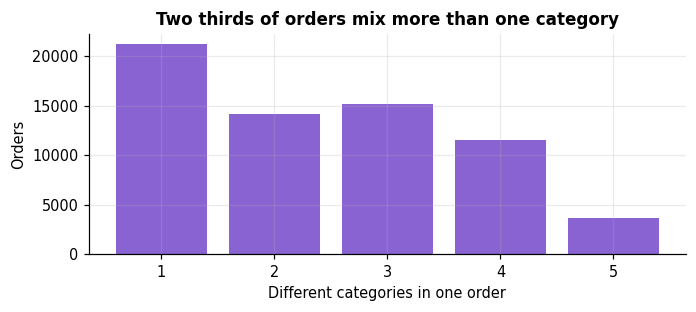

In [17]:
def mode_or_first(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else s.iloc[0]

rules = {'Late_delivery_risk': 'first', 'Delivery Status': 'first', 'Shipping Mode': 'first', 'Order Region': 'first',
         'Order Country': 'first', 'Order City': 'first', 'Order State': 'first', 'Order Zipcode': 'first',
         'Customer Segment': 'first', 'Type': 'first', 'Days for shipment (scheduled)': 'first',
         'Category Name': mode_or_first, 'Category Id': mode_or_first,
         'Sales': 'sum', 'Order Item Quantity': 'sum', 'Benefit per order': 'sum', 'order date (DateOrders)': 'first'}
orders = raw.groupby('Order Id').agg(rules).reset_index()
orders['n_line_items'] = raw.groupby('Order Id').size().values
orders['n_distinct_categories'] = raw.groupby('Order Id')['Category Name'].nunique().values

assert len(orders) == raw['Order Id'].nunique() == 65752
assert orders['Late_delivery_risk'].isnull().sum() == 0
multi = (orders['n_distinct_categories'] > 1).sum()
print(f'Shape after combining: {orders.shape[0]:,} rows and {orders.shape[1]} columns')
print(f'Orders with more than one category: {multi:,} ({multi / len(orders) * 100:.2f}%)')
print('Class balance after combining:', orders['Late_delivery_risk'].value_counts(normalize=True).round(4).to_dict())

fig, ax = plt.subplots(figsize=(7, 2.6))
vc = orders['n_distinct_categories'].value_counts().sort_index()
ax.bar(vc.index, vc.values, color=PURPLE); ax.set_xlabel('Different categories in one order'); ax.set_ylabel('Orders')
ax.set_title('Two thirds of orders mix more than one category'); plt.show()

**What we found:** the mixed category issue is not a rare edge case. **44,563 orders (67.77 percent of the dataset) contain more than one product category.** With a simple "first" rule, two thirds of the data would carry an almost random category. The class balance after combining (54.82 percent late) matches the line level figure, so the target collapsed correctly.

**Decision logged:** category is combined by mode, not first. `n_line_items` and `n_distinct_categories` are new order level columns.

## 2.2 Missing values: `Order Zipcode`

EDA suspected the zip code is missing for structural reasons. We confirm it by checking how often it is present in each country.

Order Zipcode missing: 57,482 of 65,752 orders (87.42%)
Countries with zero zipcode availability: 163 of 164


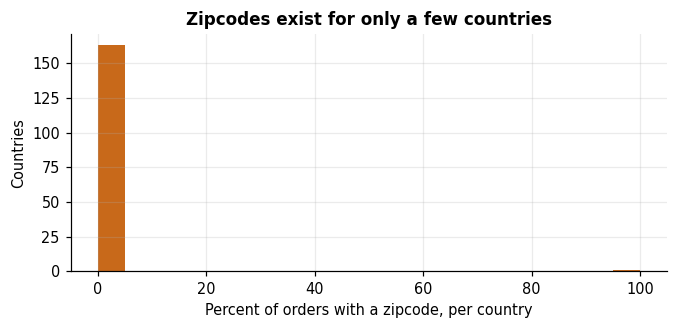

In [18]:
zmiss = orders['Order Zipcode'].isnull()
print(f'Order Zipcode missing: {zmiss.sum():,} of {len(orders):,} orders ({zmiss.mean() * 100:.2f}%)')
avail = orders.groupby('Order Country')['Order Zipcode'].apply(lambda s: s.notna().mean()).sort_values()
print('Countries with zero zipcode availability:', int((avail == 0).sum()), 'of', len(avail))
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.hist(avail.values * 100, bins=20, color=ORANGE); ax.set_xlabel('Percent of orders with a zipcode, per country'); ax.set_ylabel('Countries')
ax.set_title('Zipcodes exist for only a few countries'); plt.show()

**What we found:** it is structural, not random. About 87 percent of orders have no zip code, and **163 of the 164 countries have exactly 0 percent** availability. Zip codes exist for essentially one country only in this dataset.

**Decision logged:** drop `Order Zipcode` completely. A "zip is known" flag would be almost the same as `Order Country` itself, so it adds nothing.

In [19]:
orders = orders.drop(columns=['Order Zipcode'])
left = orders.isnull().sum(); left = left[left > 0]
print('Missing values left:', left.to_dict() if len(left) else 'none')
print(f'Shape: {orders.shape[0]:,} rows and {orders.shape[1]} columns')

Missing values left: none
Shape: 65,752 rows and 19 columns


No missing values remain. `Customer Lname` and `Customer Zipcode` (the two tiny ones from EDA) were never carried into this order table, because they are not model inputs.

## 2.3 Standardizing categories

Two things from EDA needed a closer look: whether `Order Country` mixes English and Spanish names, and why `Category Id` (51 values) and `Category Name` (50 values) do not match.

In [20]:
countries = sorted(orders['Order Country'].unique())
print(f'Distinct Order Country values: {len(countries)}')
print('A sample:', ', '.join(countries[:12]), '...')

Distinct Order Country values: 164
A sample: Afganistán, Albania, Alemania, Angola, Arabia Saudí, Argelia, Argentina, Armenia, Australia, Austria, Azerbaiyán, Bangladés ...


**What we found (this corrects our earlier EDA guess).** Looking at the full list of 164 countries, the names are **consistently Spanish**. They are not a mix. The "English looking" names we noticed (Ghana, Canada, Portugal, Argentina) are simply countries whose English and Spanish spellings are the same. **No language fix is needed.** One cosmetic oddity: `SudAfrica` has no space, but it does not create a duplicate, so we leave it.

In [21]:
id_to_names = orders.groupby('Category Id')['Category Name'].nunique()
name_to_ids = orders.groupby('Category Name')['Category Id'].nunique()
print(f'Category Ids that map to more than one name: {(id_to_names > 1).sum()}')
print(f'Category Names that map to more than one Id: {(name_to_ids > 1).sum()}')
paired = raw.groupby(['Department Id', 'Category Id'])['Category Name'].nunique()
print(f'(Department Id, Category Id) pairs with more than one name: {(paired > 1).sum()}')

Category Ids that map to more than one name: 28
Category Names that map to more than one Id: 24
(Department Id, Category Id) pairs with more than one name: 0


**What we found:** the problem is much bigger than "51 against 50". It is a many to many mix: 28 `Category Id` values map to more than one name, and 24 names are shared by several ids (for example `Category Id` 17 means both "Accessories" and "Cleats"). Our idea was that ids are numbered **inside each department**, not across the whole shop.

The check gives **zero** problems once we pair the id with `Department Id`. So the idea is confirmed. This is not a data error, just a normal id numbering habit. Therefore:

* `Category Name` is the reliable category feature.
* `Category Id` alone must not be used as a feature.

## 2.4 Outliers and the value of an order

We re check outliers at order level, because adding lines together changes the shape of the data.

Sales: 152 outliers (0.23%) outside [-535.03, 1600.94]
Benefit per order: 5,188 outliers (7.89%) outside [-218.51, 384.98]

Capped Benefit per order to [-645.22, 422.12]: 1,316 orders changed (2.00%)


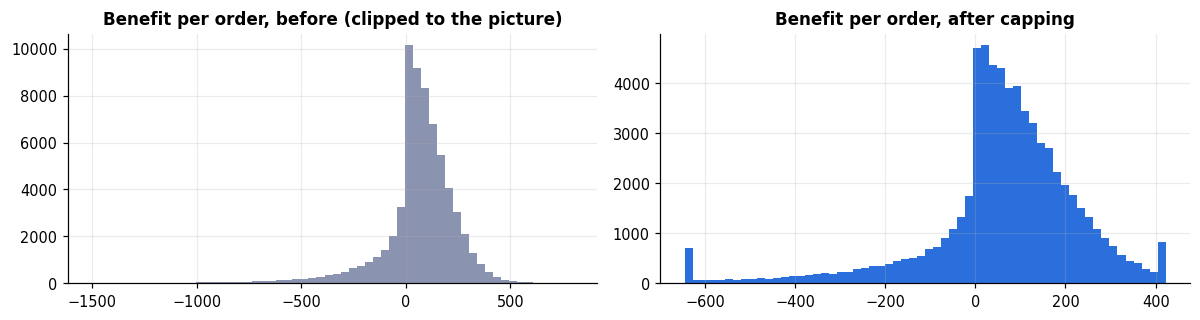

In [22]:
for col in ['Sales', 'Benefit per order']:
    q1, q3 = orders[col].quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((orders[col] < lo) | (orders[col] > hi)).sum()
    print(f'{col}: {n:,} outliers ({n / len(orders) * 100:.2f}%) outside [{lo:.2f}, {hi:.2f}]')

lo_cap, hi_cap = orders['Benefit per order'].quantile([.01, .99])
orders['Benefit_per_order_capped'] = orders['Benefit per order'].clip(lo_cap, hi_cap)
n_cap = ((orders['Benefit per order'] < lo_cap) | (orders['Benefit per order'] > hi_cap)).sum()
print(f'\nCapped Benefit per order to [{lo_cap:.2f}, {hi_cap:.2f}]: {n_cap:,} orders changed ({n_cap / len(orders) * 100:.2f}%)')
orders['priority_value_component'] = orders['Sales']   # value used by the second lens

fig, axs = plt.subplots(1, 2, figsize=(11, 3))
axs[0].hist(orders['Benefit per order'].clip(-1500, 800), bins=60, color=GREY); axs[0].set_title('Benefit per order, before (clipped to the picture)')
axs[1].hist(orders['Benefit_per_order_capped'], bins=60, color=BLUE); axs[1].set_title('Benefit per order, after capping')
plt.tight_layout(); plt.show()

**What we found**

* Outliers dropped after combining lines: `Sales` from 0.27 to 0.23 percent, and `Benefit per order` from **10.49 down to 7.89 percent**. Adding lines smooths out extremes, it does not pile them up.
* The IQR figure tells us the *size* of the outlier problem. The treatment, percentile capping, changes a different and smaller group (2 percent of orders). Both numbers are right, they just measure different things.

**Decision, with reasoning:** the priority score uses `Sales` (always positive), not `Benefit per order`. This stops a big loss order from being counted as "high value". The capped benefit stays available for reporting but does not drive the ranking.

## 2.5 Split by time into train, validation and test

We sort the orders by date and cut them in three parts. We use three parts and not two because tuning settings with Optuna tries many combinations, and scoring each one with full cross validation would be too slow. One fixed validation set lets every try be scored once, and **the test set stays untouched until the final exam**.

| Part | Share | Use |
|---|---|---|
| Train | 70% | Teach the model |
| Validation | 12% | Choose settings and the alert threshold |
| Test | 18% | Final exam, opened once |

,Part,Orders,Share,From,To,Late share
0,Train,46026,70.0%,2015-01-01,2017-03-16,54.85%
1,Validation,7890,12.0%,2017-03-16,2017-08-02,54.23%
2,Test,11836,18.0%,2017-08-02,2018-01-31,55.14%


The rebuilt split is identical to the saved train, val and test files.


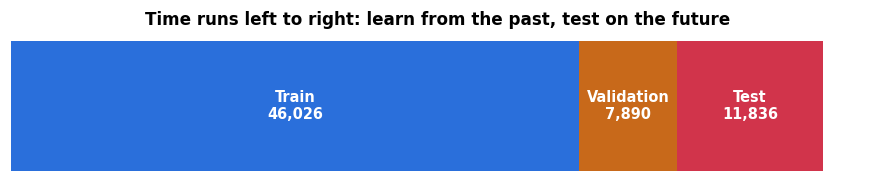

In [23]:
orders['order date (DateOrders)'] = pd.to_datetime(orders['order date (DateOrders)'], errors='coerce')
srt = orders.sort_values('order date (DateOrders)').reset_index(drop=True)
n = len(srt); t_val, t_test = int(n * (1 - .18 - .12)), int(n * (1 - .18))
train, val, test = [srt.iloc[a:b].reset_index(drop=True) for a, b in [(0, t_val), (t_val, t_test), (t_test, n)]]

rows = []
for name, p in [('Train', train), ('Validation', val), ('Test', test)]:
    rows.append([name, len(p), f'{len(p) / n * 100:.1f}%', p['order date (DateOrders)'].min().date(), p['order date (DateOrders)'].max().date(),
                 f"{p['Late_delivery_risk'].mean() * 100:.2f}%"])
display(pd.DataFrame(rows, columns=['Part', 'Orders', 'Share', 'From', 'To', 'Late share']))

# the saved split files must be identical to our rebuild
for name, part in [('train', train), ('val', val), ('test', test)]:
    saved = pd.read_csv(DATA / f'{name}.csv', usecols=['Order Id'])
    assert (saved['Order Id'].values == part['Order Id'].values).all(), name
print('The rebuilt split is identical to the saved train, val and test files.')

fig, ax = plt.subplots(figsize=(10, 1.7)); x0 = 0
for (name, p), col in zip([('Train', train), ('Validation', val), ('Test', test)], [BLUE, ORANGE, RED]):
    ax.barh(0, len(p), left=x0, color=col); ax.text(x0 + len(p) / 2, 0, f'{name}\n{len(p):,}', ha='center', va='center', color='white', fontweight='bold'); x0 += len(p)
ax.axis('off'); ax.set_title('Time runs left to right: learn from the past, test on the future'); plt.show()

**What we found:** the late share is almost the same in all three parts (54.85, 54.23 and 55.14 percent), within one point of the overall average. This confirms the "no drift" finding from EDA even at a finer level, and it makes the test a fair exam.

### Part 2 summary

| # | Decision | Reason |
|---|---|---|
| 1 | Category combined by mode, plus `n_line_items` and `n_distinct_categories` | 67.77 percent of orders mix categories, so "first" would be nearly random |
| 2 | `Order Zipcode` dropped | 87.42 percent missing and structural, a flag would copy `Order Country` |
| 3 | No country name fixing | The names are consistently Spanish. Our earlier guess was wrong |
| 4 | `Category Name` is the category feature, `Category Id` alone is not used | Ids are numbered inside departments, so they repeat |
| 5 | `Benefit per order` capped at the 1st and 99th percentile, `Sales` is the value for ranking | Avoid extremes in training and avoid counting loss orders as valuable |
| 6 | Split by time into 70, 12 and 18 percent | No drift, but a thin 2018 tail. A validation set keeps tuning feasible |

# Part 3. Feature engineering

**Input:** the three order files from Part 2. **Output:** model ready tables with 28 input features and the target, fully encoded and scaled.

A **feature** is one input number the model can use. We build them in five steps: time features, shipping and order features, place features, encoding of the remaining categories, and the final scaled matrix.

> **The rule that protects us from leakage.** Anything that is *learned from data* (the late rate of each country, how common each category is, the scaler that puts numbers on one scale) is learned from the **training part only**, then simply applied to validation and test.

## 3.1 Time features

We build the order hour, day of week, month, a weekend flag and a holiday season flag (November and December). EDA said these are weak on their own. We keep them anyway, because a weak single effect can still matter in combination with other columns (and, as Part 5 shows, the hour matters a lot for one special group).

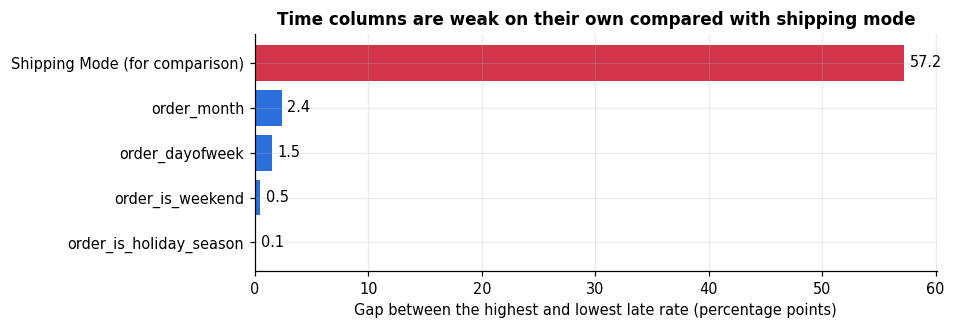

In [24]:
def add_time(df):
    d = df['order date (DateOrders)']
    o = pd.DataFrame(index=df.index)
    o['order_hour'] = d.dt.hour; o['order_dayofweek'] = d.dt.dayofweek; o['order_month'] = d.dt.month
    o['order_is_weekend'] = (o['order_dayofweek'] >= 5).astype(int)
    o['order_is_holiday_season'] = o['order_month'].isin([11, 12]).astype(int)
    return o
tt = pd.concat([add_time(train), train[['Late_delivery_risk']]], axis=1)
spread = {c: tt.groupby(c)['Late_delivery_risk'].mean().agg(lambda s: s.max() - s.min()) * 100
          for c in ['order_dayofweek', 'order_month', 'order_is_weekend', 'order_is_holiday_season']}
spread['Shipping Mode (for comparison)'] = train.groupby('Shipping Mode')['Late_delivery_risk'].mean().agg(lambda s: s.max() - s.min()) * 100
sp = pd.Series(spread).sort_values()
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.barh(sp.index, sp.values, color=[BLUE] * 4 + [RED]); ax.set_xlabel('Gap between the highest and lowest late rate (percentage points)')
for i, v in enumerate(sp.values): ax.text(v + .5, i, f'{v:.1f}', va='center')
ax.set_title('Time columns are weak on their own compared with shipping mode'); plt.show()

**What we found:** all four time gaps are under 2.5 points (day of week 1.5, month 2.4, weekend 0.5, holiday season 0.1), tiny next to shipping mode (about 57). This matches EDA exactly. We keep them for possible interaction effects, but we do not expect them to rank high on their own.

## 3.2 Shipping and order features

EDA flagged a possible overlap between `Shipping Mode` and `Days for shipment (scheduled)`. We check it directly.

Days for shipment (scheduled),0,1,2,4
Shipping Mode,,,,
First Class,0,7049,0,0
Same Day,2478,0,0,0
Second Class,0,0,8929,0
Standard Class,0,0,0,27570


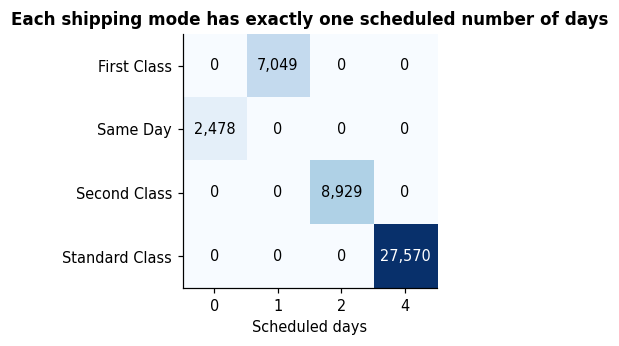

In [25]:
ctab = pd.crosstab(train['Shipping Mode'], train['Days for shipment (scheduled)'])
display(ctab)
fig, ax = plt.subplots(figsize=(6, 3)); ax.imshow(ctab.values, cmap='Blues'); ax.grid(False)
ax.set_xticks(range(ctab.shape[1])); ax.set_xticklabels(ctab.columns); ax.set_yticks(range(ctab.shape[0])); ax.set_yticklabels(ctab.index)
for (i, j), v in np.ndenumerate(ctab.values): ax.text(j, i, f'{v:,}', ha='center', va='center', color='white' if v > ctab.values.max() / 2 else 'black')
ax.set_xlabel('Scheduled days'); ax.set_title('Each shipping mode has exactly one scheduled number of days'); plt.show()

**What we found:** it is a **perfect one to one match**, with zero exceptions: First Class is 1 day, Same Day is 0 days, Second Class is 2 days, Standard Class is 4 days. So `Days for shipment (scheduled)` carries nothing that `Shipping Mode` does not already say. Keeping both would make Logistic Regression coefficients unstable, which is a real problem because we use it as an easy to read baseline.

**Decision:** drop `Days for shipment (scheduled)`, but only after using it to build one new feature, `sales_per_scheduled_day`. We also add `is_express_shipping` (First Class or Same Day).

Late rate, not express: 47.70%   express: 82.21%


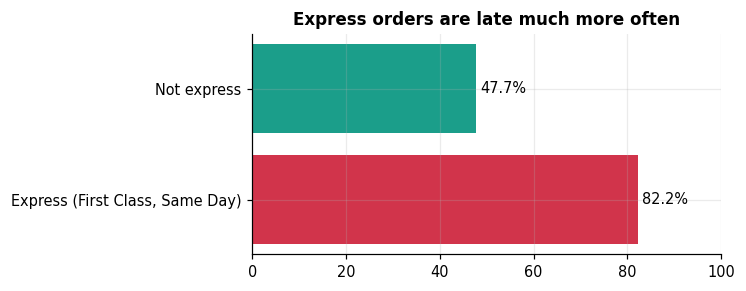

In [26]:
def add_ship(df):
    o = pd.DataFrame(index=df.index)
    spd = df['Sales'] / df['Days for shipment (scheduled)'].replace(0, np.nan)
    o['sales_per_scheduled_day'] = spd.fillna(df['Sales'])        # Same Day has 0 days, so we use Sales itself
    o['is_express_shipping'] = df['Shipping Mode'].isin(['First Class', 'Same Day']).astype(int)
    return o
ex = pd.concat([add_ship(train), train[['Late_delivery_risk']]], axis=1)
r = ex.groupby('is_express_shipping')['Late_delivery_risk'].mean() * 100
print(f'Late rate, not express: {r[0]:.2f}%   express: {r[1]:.2f}%')
fig, ax = plt.subplots(figsize=(5.5, 2.6)); ax.barh(['Express (First Class, Same Day)', 'Not express'], [r[1], r[0]], color=[RED, TEAL])
for i, v in enumerate([r[1], r[0]]): ax.text(v + 1, i, f'{v:.1f}%', va='center')
ax.set_xlim(0, 100); ax.set_title('Express orders are late much more often'); plt.show()

**What we found:** a large gap: **47.70 percent late** for non express against **82.21 percent** for express orders (First Class and Same Day together). This agrees with EDA, where these two modes sat well above the other two.

## 3.3 Place features (target encoding)

`Order Country` has 164 values, too many to turn into 164 columns. Instead we replace each country with **its late rate in the training data**. We do the same for region. This is called target encoding. The map is learned from **training only**. A country not seen in training would get the overall average.

train: 0 orders from a country unseen in training
val: 0 orders from a country unseen in training
test: 0 orders from a country unseen in training


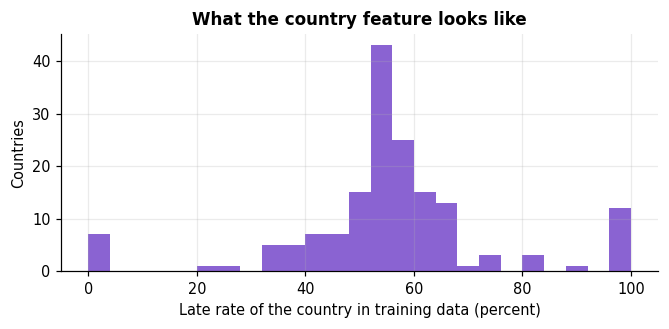

In [27]:
glob_mean = train['Late_delivery_risk'].mean()
country_map = train.groupby('Order Country')['Late_delivery_risk'].mean()
region_map = train.groupby('Order Region')['Late_delivery_risk'].mean()
for name, p in [('train', train), ('val', val), ('test', test)]:
    print(f'{name}: {(~p["Order Country"].isin(country_map.index)).sum()} orders from a country unseen in training')
fig, ax = plt.subplots(figsize=(7, 2.8)); ax.hist(country_map.values * 100, bins=25, color=PURPLE)
ax.set_xlabel('Late rate of the country in training data (percent)'); ax.set_ylabel('Countries'); ax.set_title('What the country feature looks like'); plt.show()

**What we found:** full coverage and no fallback needed. All 164 countries in training also appear in validation and test, so cutting the data by time still kept every country.

## 3.4 The remaining categories

* `Shipping Mode`, `Customer Segment` and `Type` (payment type) have few values, so each value becomes its own 0 or 1 column (**one hot encoding**): 4 + 3 + 4 = 11 columns.
* `Category Name` becomes **category_frequency**: how common that category is in the training data.

## 3.5 Final matrix and scaling

We drop the raw columns that are now replaced (ids, place names, category name, date, delivery status). Then we put 10 number columns on one scale with a `StandardScaler` that is **fit on training only**. The one hot columns stay 0 or 1.

Rebuilt features match the saved model_ready files exactly, with no missing values.
28 features. Shapes: train (46026, 28), validation (7890, 28), test (11836, 28)


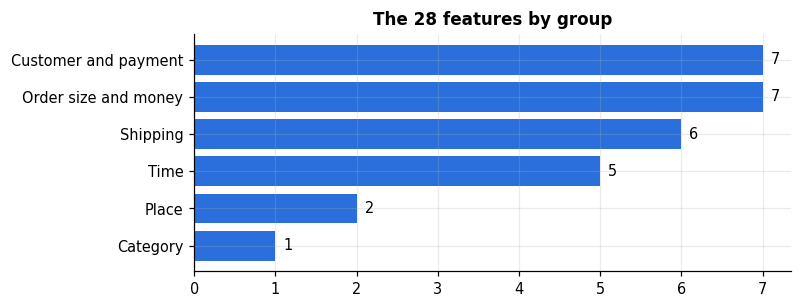

In [28]:
def base_features(df):
    o = pd.DataFrame(index=df.index)
    o['Late_delivery_risk'] = df['Late_delivery_risk']
    for c in ['Sales', 'Order Item Quantity', 'Benefit per order', 'n_line_items', 'n_distinct_categories', 'Benefit_per_order_capped', 'priority_value_component']:
        o[c] = df[c]
    return pd.concat([o, add_time(df), add_ship(df)], axis=1)

parts = [train, val, test]
F = [base_features(p) for p in parts]
for col, name, mp in [('Order Country', 'country_delay_rate', country_map), ('Order Region', 'region_delay_rate', region_map)]:
    for o, p in zip(F, parts): o[name] = p[col].map(mp).fillna(glob_mean)
for col in ['Shipping Mode', 'Customer Segment', 'Type']:
    for o, p in zip(F, parts):
        for v in sorted(train[col].unique()): o[f'{col}_{v}'] = (p[col] == v)
freq = train['Category Name'].value_counts(normalize=True)
for o, p in zip(F, parts): o['category_frequency'] = p['Category Name'].map(freq).fillna(freq.min())

num_cols_scale = ['Sales', 'Order Item Quantity', 'Benefit_per_order_capped', 'n_line_items', 'n_distinct_categories',
                  'sales_per_scheduled_day', 'country_delay_rate', 'region_delay_rate', 'category_frequency', 'priority_value_component']
scaler = StandardScaler().fit(F[0][num_cols_scale])
for o in F: o[num_cols_scale] = scaler.transform(o[num_cols_scale])

# the rebuilt tables must equal the saved model ready files
for name, o in zip(['train', 'val', 'test'], F):
    ref = pd.read_csv(DATA / f'model_ready_{name}.csv')
    assert list(ref.columns) == list(o.columns), name
    assert np.allclose(ref.astype(float).values, o.astype(float).values, atol=1e-6, equal_nan=True), name
    assert o.isnull().sum().sum() == 0
print('Rebuilt features match the saved model_ready files exactly, with no missing values.')

FEATURES = [c for c in F[0].columns if c != 'Late_delivery_risk']
Xtr, Xva, Xte = [o[FEATURES].astype(float) for o in F]
ytr, yva, yte = [o['Late_delivery_risk'].values for o in F]
print(f'{len(FEATURES)} features. Shapes: train {Xtr.shape}, validation {Xva.shape}, test {Xte.shape}')
groups = {'Order size and money': ['Sales', 'Order Item Quantity', 'Benefit per order', 'n_line_items', 'n_distinct_categories', 'Benefit_per_order_capped', 'priority_value_component'],
          'Time': ['order_hour', 'order_dayofweek', 'order_month', 'order_is_weekend', 'order_is_holiday_season'],
          'Shipping': ['sales_per_scheduled_day', 'is_express_shipping'] + [c for c in FEATURES if c.startswith('Shipping Mode_')],
          'Place': ['country_delay_rate', 'region_delay_rate'],
          'Customer and payment': [c for c in FEATURES if c.startswith(('Customer Segment_', 'Type_'))],
          'Category': ['category_frequency']}
assert sum(len(v) for v in groups.values()) == len(FEATURES)
gt = pd.Series({k: len(v) for k, v in groups.items()}).sort_values()
fig, ax = plt.subplots(figsize=(7, 2.8)); ax.barh(gt.index, gt.values, color=BLUE)
for i, v in enumerate(gt.values): ax.text(v + .1, i, str(v), va='center')
ax.set_title('The 28 features by group'); plt.show()

**What we found:** the final shapes are train (46,026 by 29), validation (7,890 by 29) and test (11,836 by 29): 28 features plus the target, with no missing values. Our rebuild matches the saved files exactly.

A note about `priority_value_component` (which is Sales): it is scaled here for modelling, so it can be negative. A separate **unscaled** copy is kept for ranking and for the app, because a negative "order value" means nothing to a person.

### Part 3 summary

| # | Decision | Reason |
|---|---|---|
| 1 | Time features kept even though each one is weak alone | They may matter in combination |
| 2 | `Days for shipment (scheduled)` dropped after building `sales_per_scheduled_day` | A perfect one to one match with `Shipping Mode` would make Logistic Regression unstable |
| 3 | Country and region late rates learned from train only | Prevents leakage. No unseen countries appeared |
| 4 | One hot for mode, segment and payment type. Frequency for category | Few values suit one hot. Category name is reliable (Part 2) |
| 5 | Scaler fit on train only. Unscaled Sales kept separately | Fair for linear models, and real money values for the app |

# Part 4. Baseline and model development

**Input:** the model ready train and validation tables (46,026 and 7,890 orders, 28 features).
**Output:** a ranked comparison of one rule baseline and eleven machine learning models, all scored on the same validation data.

> **The test set is not touched in this part.** It stays closed until the final exam in Part 5.

| # | Model | Family |
|---|---|---|
| 1 | Rule baseline | Not machine learning, the floor to beat |
| 2 | Logistic Regression | Linear |
| 3 | Random Forest | Many trees, averaged (bagging) |
| 4 | XGBoost | Trees built one after another (boosting) |
| 5 | SVM (linear) | Linear |
| 6 | Neural Network (PyTorch) | Deep learning |
| 7 | LightGBM | Boosting |
| 8 | CatBoost | Boosting |
| 9 | Gradient Boosting and AdaBoost | Classic boosting |
| 10 | Voting Classifier | Combines several models by averaging |
| 11 | Stacking Classifier | Combines several models with a second model |

To keep this notebook quick, the models that take long to train or need extra libraries (SVM, LightGBM, CatBoost, Gradient Boosting, AdaBoost, Voting, Stacking) are read from the results our earlier run saved in `data/processed/metrics_*.json`. The four most important ones (rule baseline, Logistic Regression, Random Forest, XGBoost and the Neural Network) are **trained again here**, and compared with the saved numbers as a check.

In [29]:
def ev(y, p, t=0.5):
    # all five metrics for scores p at threshold t
    pred = (p >= t).astype(int)
    return {'recall': recall_score(y, pred), 'precision': precision_score(y, pred, zero_division=0), 'f1': f1_score(y, pred),
            'roc_auc': roc_auc_score(y, p), 'pr_auc': average_precision_score(y, p)}

def saved(name): return json.load(open(DATA / f'metrics_{name}.json'))

def compare_saved(name, got):
    s = saved(name)
    print(f'{s["model"]}: rerun vs saved')
    print(pd.DataFrame({'rerun': got, 'saved': {k: s[k] for k in got}}).round(4).T.to_string())

def small_eval(y, p, title, t=0.5):
    fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
    cm = confusion_matrix(y, (p >= t).astype(int)); axs[0].imshow(cm, cmap='Blues'); axs[0].grid(False)
    for (i, j), v in np.ndenumerate(cm): axs[0].text(j, i, f'{v:,}', ha='center', va='center', color='white' if v > cm.max() / 2 else 'black', fontweight='bold')
    axs[0].set_xticks([0, 1]); axs[0].set_xticklabels(['Said fine', 'Said late']); axs[0].set_yticks([0, 1]); axs[0].set_yticklabels(['On time', 'Late']); axs[0].set_title('Confusion matrix')
    fpr, tpr, _ = roc_curve(y, p); axs[1].plot(fpr, tpr, color=BLUE, lw=2, label=f'AUC {roc_auc_score(y, p):.3f}'); axs[1].plot([0, 1], [0, 1], '--', color=GREY)
    axs[1].set_title('ROC curve'); axs[1].legend(loc='lower right')
    pr, rc, _ = precision_recall_curve(y, p); axs[2].plot(rc, pr, color=RED, lw=2, label=f'AUC {average_precision_score(y, p):.3f}'); axs[2].set_title('Precision and Recall curve'); axs[2].legend(loc='lower left')
    plt.suptitle(title, fontweight='bold'); plt.tight_layout(); plt.show()

## 4.1 The rule baseline

A baseline is the simplest sensible method. A model is only worth building if it beats it. Ours: look up the late rate of each shipping mode in the training data, and say "late" when that rate is above 50 percent.

In [30]:
mode_rate = train.groupby('Shipping Mode')['Late_delivery_risk'].mean()
print('Late rate by shipping mode (train):'); print((mode_rate * 100).round(1).to_string())

Late rate by shipping mode (train):
Shipping Mode
First Class       95.5
Same Day          44.4
Second Class      76.9
Standard Class    38.3


### A bug we found and fixed

> **The first rule was wrong.** It said "late" if *either* the shipping mode rate was above 50 percent *or* the region rate was above 50 percent.
>
> **Why it broke.** The overall late rate is already 54.8 percent. Region rates all sit close to that average (EDA found only a 9 point spread), so almost every region was above 50 percent, and the region part fired for nearly every order.
>
> **The result.** The rule quietly became "always predict late". It showed 100 percent Recall (easy, when you flag everything) and 0 percent specificity (it never once said "on time").
>
> **The fix.** Remove the region part. Shipping mode alone separates well: First Class and Second Class sit clearly above 50 percent, Same Day and Standard Class clearly below.

,Rule,Recall,Precision,Specificity,Share flagged
0,Broken rule (mode OR region),1.000,0.542,0.000,1.000
1,Fixed rule (mode only),0.535,0.839,0.878,0.346


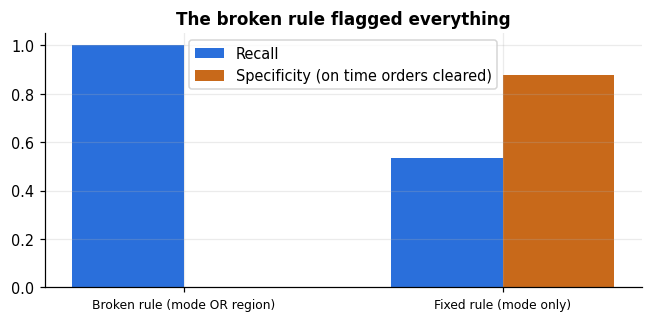

In [31]:
region_rate = train.groupby('Order Region')['Late_delivery_risk'].mean()
def rule_either(df):   # the broken first version
    return ((df['Shipping Mode'].map(mode_rate) > .5) | (df['Order Region'].map(region_rate) > .5)).astype(int)
def rule_fixed(df):    # shipping mode only
    return (df['Shipping Mode'].map(mode_rate) > .5).astype(int)

def spec(y, pred): return ((pred == 0) & (y == 0)).sum() / (y == 0).sum()
rows = []
for name, fn in [('Broken rule (mode OR region)', rule_either), ('Fixed rule (mode only)', rule_fixed)]:
    pr = fn(val).values
    rows.append([name, recall_score(yva, pr), precision_score(yva, pr), spec(yva, pr), pr.mean()])
bug = pd.DataFrame(rows, columns=['Rule', 'Recall', 'Precision', 'Specificity', 'Share flagged']).round(3); display(bug)

fig, ax = plt.subplots(figsize=(7, 3)); w = .35; x = np.arange(len(bug))
ax.bar(x - w / 2, bug['Recall'], w, color=BLUE, label='Recall'); ax.bar(x + w / 2, bug['Specificity'], w, color=ORANGE, label='Specificity (on time orders cleared)')
ax.set_xticks(x); ax.set_xticklabels(bug['Rule'], fontsize=8); ax.legend(); ax.set_title('The broken rule flagged everything'); plt.show()

Rule-based baseline: rerun vs saved
       recall  precision      f1  roc_auc  pr_auc
rerun  0.5349     0.8391  0.6533    0.727  0.7429
saved  0.5349     0.8391  0.6533    0.727  0.7429


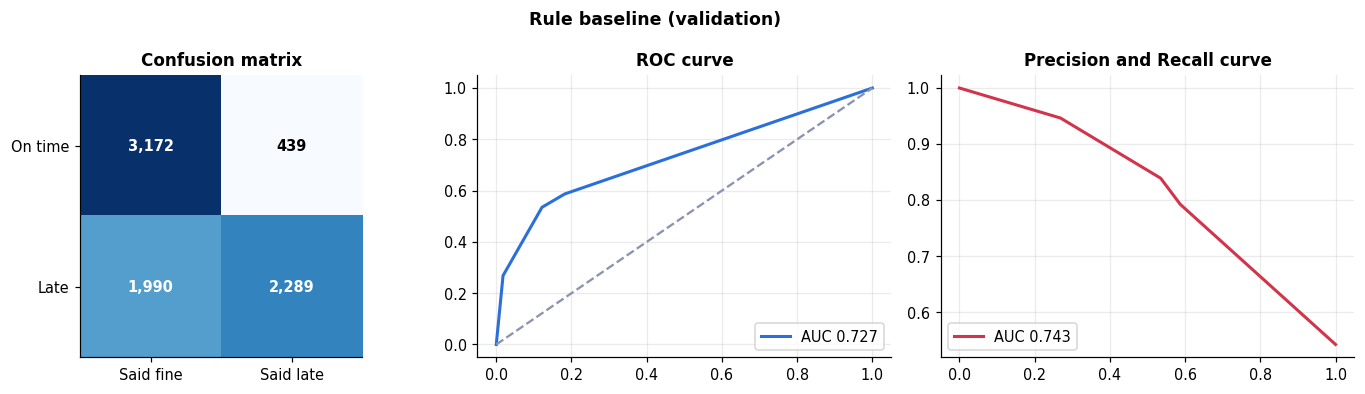

In [32]:
score_base = val['Shipping Mode'].map(mode_rate).values
m_base = ev(yva, score_base, t=0.5000001)   # rate above 0.5 means flag
compare_saved('baseline', m_base)
small_eval(yva, score_base, 'Rule baseline (validation)', t=0.5000001)

**What we found (validation set)**

| Metric | Value |
|---|---|
| Recall | 0.5349 |
| Precision | 0.8391 |
| F1 | 0.6533 |
| ROC AUC | 0.7270 |

This is a meaningful floor. 84 percent Precision from one feature is a real result, not a token one. Its weakness is Recall: it misses almost half of the late orders, mainly those shipped by modes that are late just under half of the time (Same Day, Standard Class) but still late often enough to matter. Every model below is measured against this corrected baseline.

## 4.2 Logistic Regression

An easy to read linear model, trained on the 28 features.

Logistic Regression: rerun vs saved
       recall  precision      f1  roc_auc  pr_auc
rerun  0.5543     0.8379  0.6672   0.7394  0.8106
saved  0.5536     0.8377  0.6667   0.7394  0.8105


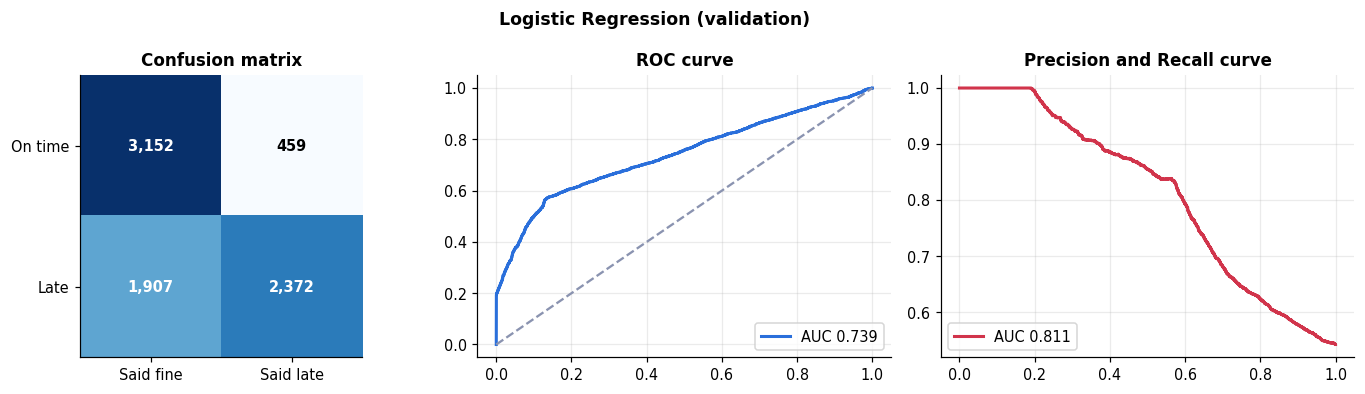

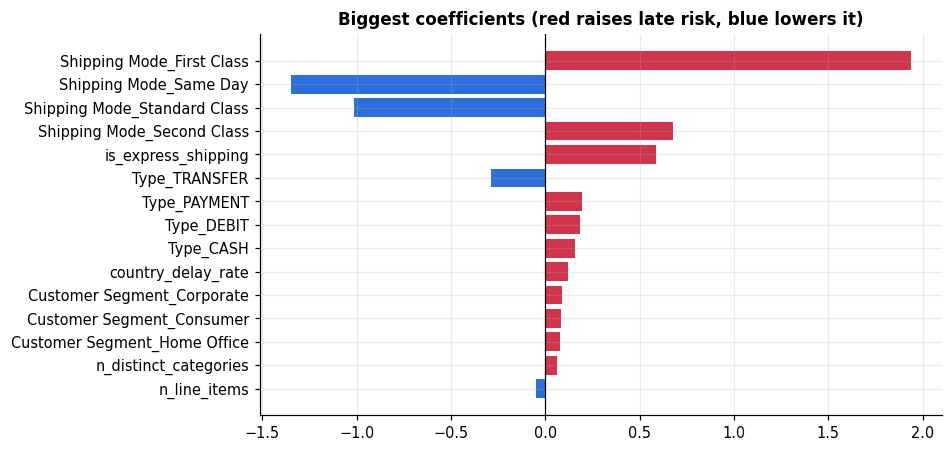

In [33]:
lr = LogisticRegression(max_iter=1000, random_state=SEED).fit(Xtr, ytr)
p_lr = lr.predict_proba(Xva)[:, 1]
compare_saved('logreg', ev(yva, p_lr))
small_eval(yva, p_lr, 'Logistic Regression (validation)')
coef = pd.Series(lr.coef_[0], index=FEATURES); top = coef.reindex(coef.abs().sort_values(ascending=False).index)[:15].iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.5)); ax.barh(top.index, top.values, color=[RED if v > 0 else BLUE for v in top.values]); ax.axvline(0, color='black', lw=.8)
ax.set_title('Biggest coefficients (red raises late risk, blue lowers it)'); plt.show()

**What we found:** a clean, steady improvement over the baseline on every metric (Recall 0.554, Precision 0.838 held flat, ROC AUC 0.739, PR AUC 0.811). PR AUC rose by nearly 7 points, which tells us there is room to gain by choosing a better threshold later.

**Shipping mode dominates the coefficients**, as the 57 point EDA spread predicted. The country late rate (EDA's second strongest signal on its own) gets only a modest coefficient. That is expected: once shipping mode explains most of the variation, a second feature adds less than its stand alone spread suggests.

## 4.3 Random Forest

We train 200 trees. We also look at **which features it relies on**, and we check an odd result.

Trained in 9 seconds
Random Forest: rerun vs saved
       recall  precision      f1  roc_auc  pr_auc
rerun  0.6200     0.7875  0.6938    0.758  0.8234
saved  0.6172     0.7924  0.6939    0.758  0.8234


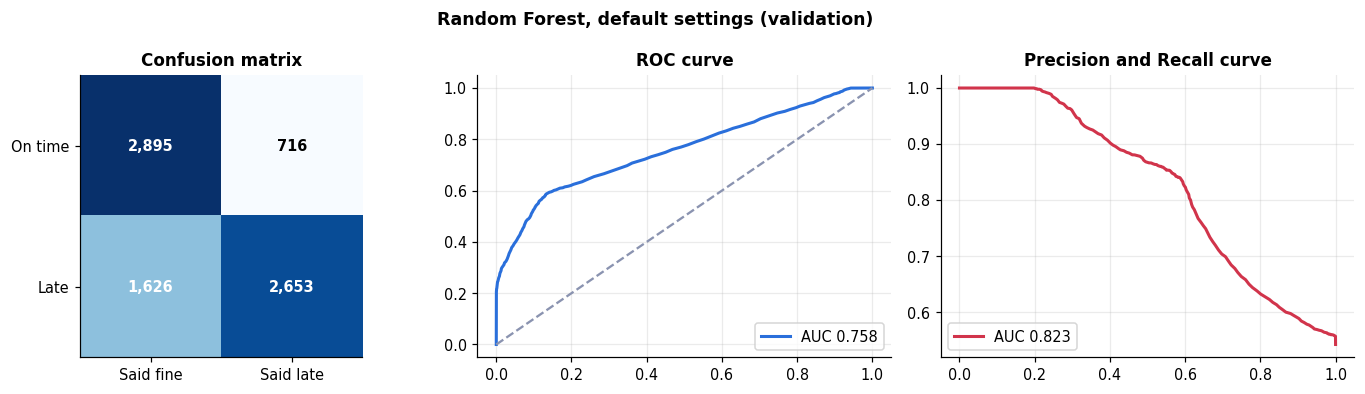

In [34]:
t0 = time.time()
rf_def = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=2).fit(Xtr, ytr)
p_rf_def = rf_def.predict_proba(Xva)[:, 1]
print(f'Trained in {time.time() - t0:.0f} seconds')
compare_saved('rf', ev(yva, p_rf_def))
small_eval(yva, p_rf_def, 'Random Forest, default settings (validation)')

**What we found:** a real Recall jump over Logistic Regression (about 6 points higher), at a proportionate Precision cost (0.617 Recall, 0.792 Precision). That is the right direction, since Recall is our main goal. (Our rerun above gives 0.620 Recall instead of 0.6172 because of a newer scikit-learn version. The ranking numbers are identical. Tables below use the saved numbers.)

> **A genuine finding to check.** The default importance of Random Forest (called MDI) ranks `order_hour` as the single most important feature, ahead of shipping mode. That contradicts every other model and the EDA. MDI is known to favour features with many different numbers (like the hour) over simple 0 or 1 columns. So we check with **permutation importance**: shuffle one feature and see how much the score drops. That method does not have this bias.

Permutation importance took 21 seconds


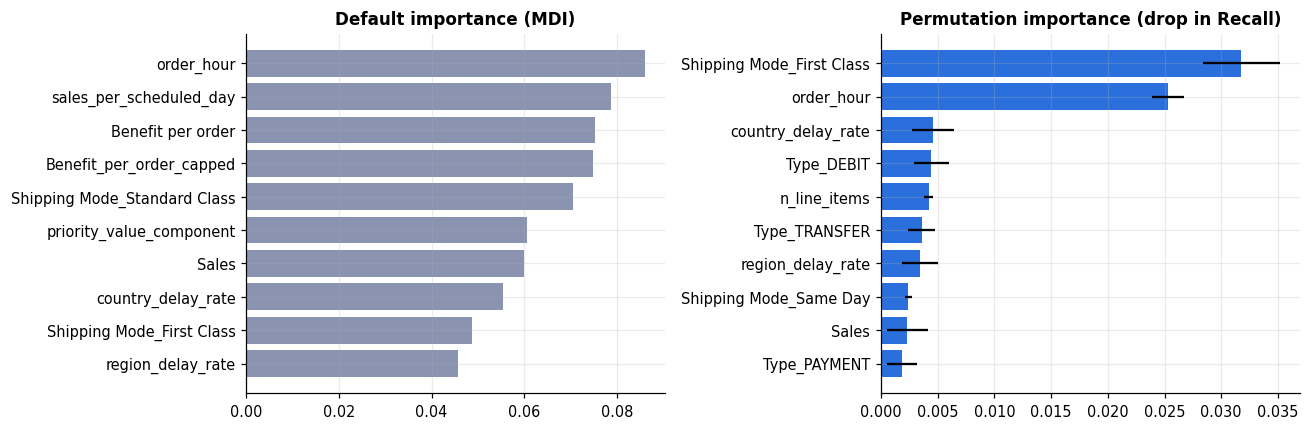

In [35]:
mdi = pd.Series(rf_def.feature_importances_, index=FEATURES).sort_values().tail(10)
t0 = time.time()
perm = permutation_importance(rf_def, Xva, yva, n_repeats=3, random_state=SEED, n_jobs=1, scoring='recall')
pi = pd.Series(perm.importances_mean, index=FEATURES); pe = pd.Series(perm.importances_std, index=FEATURES)
pi_top = pi.sort_values().tail(10)
print(f'Permutation importance took {time.time() - t0:.0f} seconds')
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].barh(mdi.index, mdi.values, color=GREY); axs[0].set_title('Default importance (MDI)')
axs[1].barh(pi_top.index, pi_top.values, xerr=pe[pi_top.index].values, color=BLUE); axs[1].set_title('Permutation importance (drop in Recall)')
plt.tight_layout(); plt.show()

**What we found:** this partly confirms the bias, with a surprise. `Shipping Mode_First Class` takes back the top place once the bias is removed, as expected. But `order_hour` **still ranks second**, and its error bar does not touch zero, so it is not just noise.

A likely explanation: permutation importance picks up combinations of features that a simple one feature look in EDA cannot see. `order_hour` may not predict lateness alone, but together with shipping mode it carries real signal. We did not claim this yet. It became an open question for the SHAP analysis in Part 5, where it is fully answered (it is the noon rule for Same Day orders).

## 4.4 XGBoost

XGBoost: rerun vs saved
       recall  precision      f1  roc_auc  pr_auc
rerun  0.6062      0.816  0.6956   0.7595   0.825
saved  0.6062      0.816  0.6956   0.7595   0.825


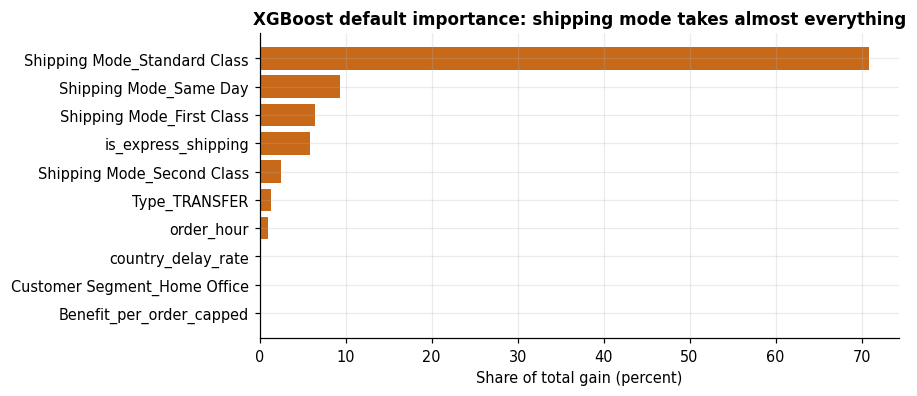

In [36]:
from xgboost import XGBClassifier
xgb_def = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='logloss', random_state=SEED, n_jobs=-1).fit(Xtr, ytr)
p_xgb_def = xgb_def.predict_proba(Xva)[:, 1]
compare_saved('xgb', ev(yva, p_xgb_def))
gain = pd.Series(xgb_def.get_booster().get_score(importance_type='gain')).reindex(FEATURES).fillna(0); gain = (gain / gain.sum()).sort_values().tail(10)
fig, ax = plt.subplots(figsize=(7.5, 3.6)); ax.barh(gain.index, gain.values * 100, color=ORANGE); ax.set_xlabel('Share of total gain (percent)')
ax.set_title('XGBoost default importance: shipping mode takes almost everything'); plt.show()

**What we found:** XGBoost is almost tied with Random Forest on F1, ROC AUC and PR AUC (differences under 0.002), but the two trade Recall and Precision in opposite directions:

* **Random Forest** has the higher Recall (0.6172 against 0.6062).
* **XGBoost** has the higher Precision (0.8160 against 0.7924).

Since Recall is our main goal, Random Forest is ahead on the metric that matters most, despite XGBoost's stronger reputation. We keep both for tuning.

**The importance disagreement.** XGBoost's own gain importance gives shipping mode over 90 percent of the credit and `order_hour` only about 1 percent. That directly contradicts Random Forest's `order_hour` finding. Two tree models disagreeing this much about one feature is the reason we use SHAP in Part 5. We should not trust either built in chart alone.

## 4.5 SVM (linear)

A different way of learning (it maximizes a margin and uses a different loss than Logistic Regression). We use a linear SVM and wrap it so it can give probabilities.

> **A convergence issue we caught.** The first run used the default `max_iter=5000` and printed a "failed to converge" warning. That unfinished run gave a dramatically different result from Logistic Regression (Recall 0.71 against 0.55), which looked like a believable story about a different loss function. After fixing the setting (`max_iter=20000` and `dual=False`, which is the correct choice when rows far outnumber features), the result changed completely.

In [37]:
s = saved('svm'); l = saved('logreg')
display(pd.DataFrame({'Logistic Regression': {k: l[k] for k in ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']},
                      'SVM (linear, converged)': {k: s[k] for k in ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']}}).round(4))

,Logistic Regression,"SVM (linear, converged)"
recall,0.5536,0.5618
precision,0.8377,0.8394
f1,0.6667,0.6731
roc_auc,0.7394,0.7392
pr_auc,0.8105,0.8102


**What we found:** once it converged, the SVM is **almost identical to Logistic Regression** (Recall 0.5618, ROC AUC 0.7392). The earlier "dramatic difference" was only an optimizer problem, not a real effect of the method. This is a good example of why a surprising result must be checked for basic problems (like convergence) before we believe it. It is kept in our decision log as proof of careful checking.

**Practical result:** the SVM adds nothing that Logistic Regression does not. There is no reason to carry both forward.

## 4.6 Neural Network (PyTorch)

A small feed forward network: 28 inputs, then 64 units, then 32 units, then 1 output, with dropout and the Adam optimizer. We said honestly in advance that we did **not** expect it to beat gradient boosting on 46,000 rows of table data. Reporting the result either way is a legitimate finding.

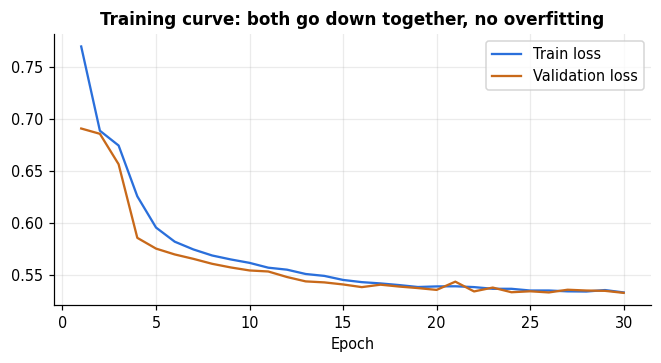

Neural Network (PyTorch): rerun vs saved
       recall  precision      f1  roc_auc  pr_auc
rerun  0.5864     0.8462  0.6927   0.7655  0.8291
saved  0.5857     0.8458  0.6921   0.7653  0.8301


In [38]:
class DelayRiskMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_features, 64), nn.ReLU(), nn.Dropout(0.3),
                                 nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1))
    def forward(self, x): return self.net(x)

Xtr_np, Xva_np, Xte_np = [x.values.astype(np.float32) for x in (Xtr, Xva, Xte)]
loader = DataLoader(TensorDataset(torch.tensor(Xtr_np), torch.tensor(ytr.astype(np.float32))), batch_size=256, shuffle=True)
torch.manual_seed(SEED)
nn_model = DelayRiskMLP(Xtr_np.shape[1]); crit = nn.BCEWithLogitsLoss(); opt = torch.optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
tr_loss, va_loss = [], []
for epoch in range(30):
    nn_model.train(); tot = 0
    for xb, yb in loader:
        opt.zero_grad(); loss = crit(nn_model(xb).squeeze(1), yb); loss.backward(); opt.step(); tot += loss.item() * len(xb)
    tr_loss.append(tot / len(Xtr_np)); nn_model.eval()
    with torch.no_grad(): va_loss.append(crit(nn_model(torch.tensor(Xva_np)).squeeze(1), torch.tensor(yva.astype(np.float32))).item())
fig, ax = plt.subplots(figsize=(7, 3.2)); ax.plot(range(1, 31), tr_loss, color=BLUE, label='Train loss'); ax.plot(range(1, 31), va_loss, color=ORANGE, label='Validation loss')
ax.set_xlabel('Epoch'); ax.legend(); ax.set_title('Training curve: both go down together, no overfitting'); plt.show()
with torch.no_grad(): p_nn_def = torch.sigmoid(nn_model(torch.tensor(Xva_np)).squeeze(1)).numpy()
compare_saved('nn', ev(yva, p_nn_def))

**What we found:** the training curve is healthy. Train and validation loss fall together and end close, so there is no overfitting.

Against our own expectation, the Neural Network has the **best ROC AUC (0.7653), PR AUC (0.8301) and Precision (0.8458)** of all models in the comparison. It does not lead on Recall (Random Forest still does). So "gradient boosting always wins on table data" did not automatically hold here, at least not on every metric. That is a tested result and not an assumption. (Small differences between our rerun and the saved numbers come from random starting values.)

## 4.7 The other boosting models, and the two ensembles

These were trained in our earlier run. Their results are in the saved files. What each one taught us:

**LightGBM** grows trees leaf by leaf instead of level by level, a real difference in method. Result: essentially tied with XGBoost (every difference under one point). Two independent implementations agreeing is a good sign that the patterns are real. Its default importance chart (by number of splits) showed the same bias as Random Forest: `Shipping Mode` was not even in its top 15, while continuous columns like `Benefit per order` and `Sales` led. That is the second tree model whose built in chart looked misleading, which is why SHAP is the right tool.

**CatBoost** handles categories natively. Result: a third boosting library with a nearly identical score. A version using the raw categories directly (no one hot or frequency encoding) gave Recall 0.5892, Precision 0.8446, ROC AUC 0.7672, equal or slightly better, with less preparation. That is a useful practical finding for a live system where new categories may appear over time.

**Gradient Boosting (scikit-learn) and AdaBoost** test whether "boosting got better over time" holds. Gradient Boosting (ROC AUC 0.7639) is statistically the same as XGBoost, LightGBM and CatBoost. AdaBoost (ROC AUC 0.7393) is clearly weaker and lands at the level of the linear models. So the real story: AdaBoost to Gradient Boosting was a true accuracy gain, but Gradient Boosting to the modern three was mainly a gain in **speed and engineering**, not accuracy, on this data.

**Voting and Stacking** combine the top 4 models (Random Forest, XGBoost, LightGBM, CatBoost). Voting averages their probabilities. Stacking lets a Logistic Regression learn how to weight them. Both ended **below Random Forest alone on Recall** (0.5966 and 0.5973 against 0.6172). The reason is that all four base models are tree models, so there is little variety to combine, and averaging Random Forest's aggressive high Recall style with three more careful models pulls the answer toward the cautious middle.

The stacking weights show this clearly (from our earlier run):

| Base model | Weight given by the second model |
|---|---|
| CatBoost | 3.80 |
| LightGBM | 0.95 |
| Random Forest | 0.63 |
| XGBoost | minus 0.13 |

CatBoost got by far the biggest weight even though it had the lowest Recall of the four, and XGBoost got a slightly negative weight although it was the second best on its own. The second model optimizes its own log loss, not our Recall goal, so it favours the models with the best calibrated probabilities. **Neither ensemble is recommended for tuning.** They do worse on our main metric and cost more to run.

## 4.8 The full comparison

All twelve rows (one baseline and eleven models), same validation data, default threshold 0.5. The numbers come from the saved files.

In [39]:
files = sorted(DATA.glob('metrics_*.json'))
lb = pd.DataFrame([json.load(open(f)) for f in files]).set_index('model').rename(index={'Rule-based baseline': 'Rule baseline'})
lb = lb[['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']].sort_values('recall', ascending=False)
print(len(lb), 'rows: 1 rule baseline and', len(lb) - 1, 'models (validation, threshold 0.5)')
display(lb.round(4))

12 rows: 1 rule baseline and 11 models (validation, threshold 0.5)


,recall,precision,f1,roc_auc,pr_auc
model,,,,,
Random Forest,0.6172,0.7924,0.6939,0.7580,0.8234
XGBoost,0.6062,0.8160,0.6956,0.7595,0.8250
LightGBM,0.6011,0.8236,0.6949,0.7643,0.8290
Stacking Classifier,0.5973,0.8299,0.6947,0.7641,0.8288
Voting Classifier,0.5966,0.8321,0.6950,0.7616,0.8276
CatBoost,0.5936,0.8358,0.6942,0.7642,0.8284
Gradient Boosting (sklearn),0.5917,0.8409,0.6947,0.7639,0.8290
Neural Network (PyTorch),0.5857,0.8458,0.6921,0.7653,0.8301
AdaBoost,0.5695,0.8363,0.6776,0.7393,0.8053


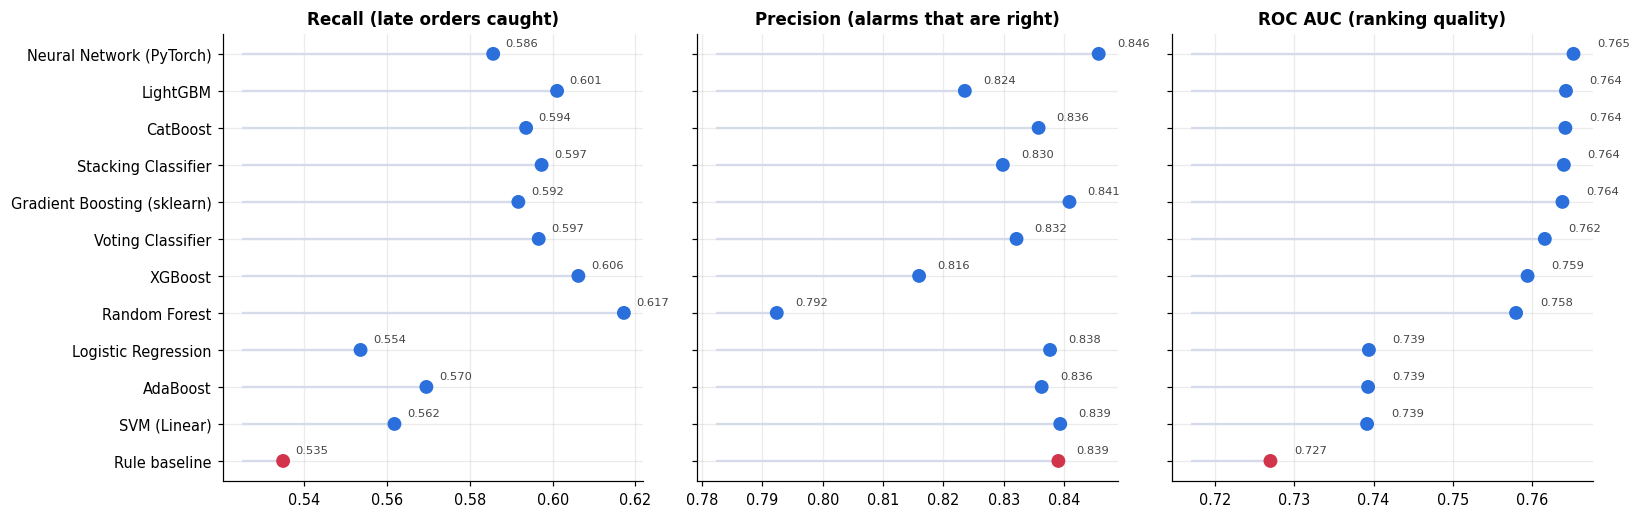

In [40]:
order = lb.sort_values('roc_auc').index
fig, axs = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, col, title in [(axs[0], 'recall', 'Recall (late orders caught)'), (axs[1], 'precision', 'Precision (alarms that are right)'), (axs[2], 'roc_auc', 'ROC AUC (ranking quality)')]:
    v = lb.loc[order, col]
    ax.hlines(range(len(v)), v.min() - .01, v.values, color='#d5dbea')
    ax.scatter(v.values, range(len(v)), s=65, color=[RED if m == 'Rule baseline' else BLUE for m in order], zorder=3)
    ax.set_yticks(range(len(v))); ax.set_yticklabels(order); ax.set_title(title)
    for i, x in enumerate(v.values): ax.text(x + .003, i + .2, f'{x:.3f}', fontsize=7.5, color='#444')
plt.tight_layout(); plt.show()

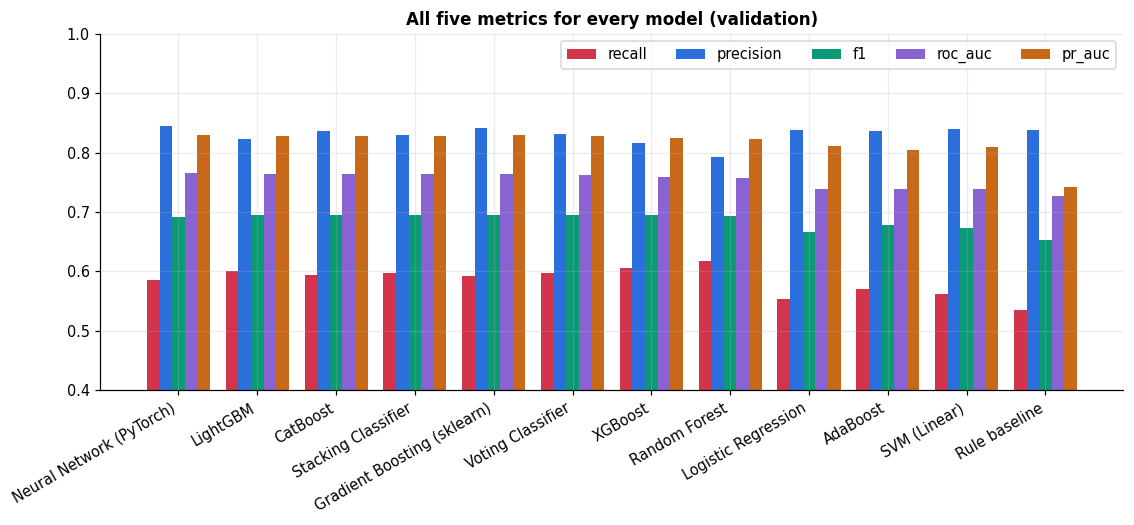

The same comparison as saved by the model development run:


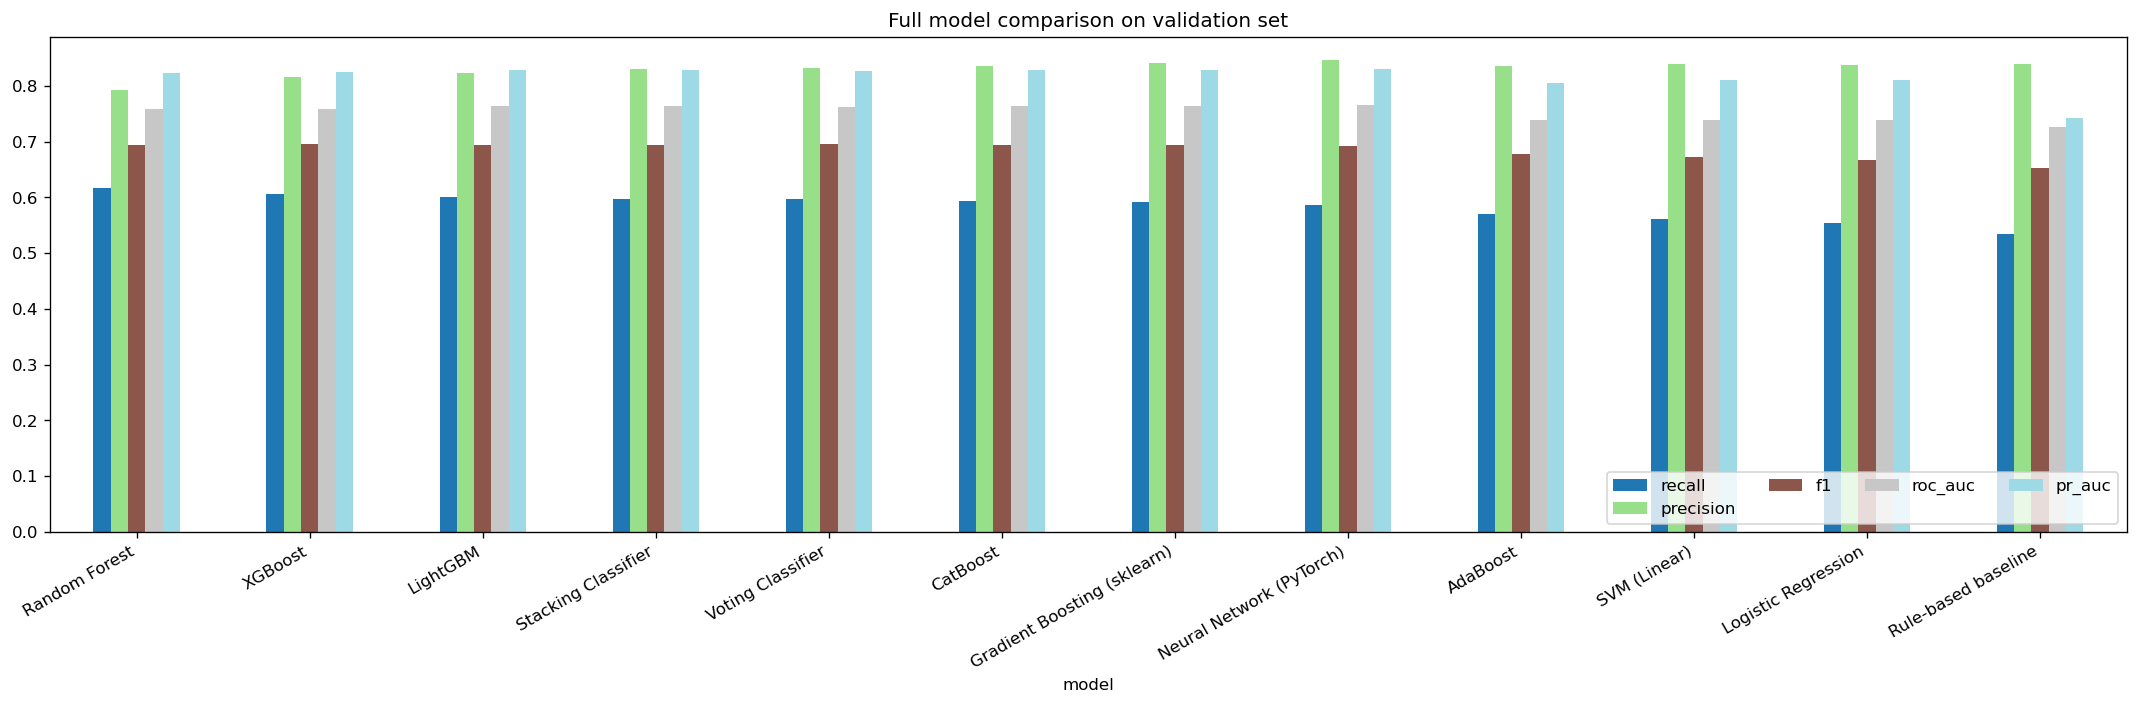

In [41]:
fig, ax = plt.subplots(figsize=(12, 4.2)); lbs = lb.sort_values('roc_auc', ascending=False); x = np.arange(len(lbs)); w = .16
for j, (col, colr) in enumerate([('recall', RED), ('precision', BLUE), ('f1', GREEN), ('roc_auc', PURPLE), ('pr_auc', ORANGE)]):
    ax.bar(x + (j - 2) * w, lbs[col], w, label=col, color=colr)
ax.set_xticks(x); ax.set_xticklabels(lbs.index, rotation=30, ha='right'); ax.set_ylim(.4, 1); ax.legend(ncol=5, loc='upper right'); ax.set_title('All five metrics for every model (validation)')
plt.show()
show_img('model_comparison_bars_final.png', 700, 'The same comparison as saved by the model development run:')

### Summary of Part 4

1. **Random Forest leads on Recall** (0.6172), ahead of every model including both ensembles. The gap from baseline to best is about 8 points.
2. **Boosting does not show a clean "newer is better" line.** AdaBoost is clearly weaker, while classic Gradient Boosting ties the three modern libraries. The modern ones are faster, not more accurate, here.
3. **Both ensembles did worse than the best single model on Recall.** The cause is a lack of variety among the base models and a second model that optimizes the wrong goal. This is a well explained negative result, not just a null one.
4. **The Neural Network has the best ranking quality** (ROC AUC, PR AUC and Precision), against our own expectation.
5. **SVM and Logistic Regression are the same** once the SVM converges.
6. At the default 0.5 line, **every model has Recall between 0.53 and 0.62, far below our 0.80 goal.** The threshold, not the model, is the next lever.

**Candidates carried to Part 5:** Random Forest (best Recall), Neural Network (best ranking quality, so the most to gain from a better threshold), and XGBoost (a close third). Neither ensemble is carried forward.

# Part 5. Tuning, explainability, threshold and final test

**Input:** train and validation tables. The test table is opened **once**, in section 5.8.
**Output:** tuned models, the chosen alert threshold, the final test results, and an explanation of what the model uses.

| Section | Question it answers |
|---|---|
| 5.1 | Setup: load the tuned models |
| 5.2 Random Forest | Does tuning improve the Recall leader? |
| 5.3 XGBoost | Same question, and why our first attempt was thrown away |
| 5.4 Neural Network | Does tuning close the gap to Random Forest? |
| 5.5 Model choice | Which model goes forward, compared fairly at the same Recall? |
| 5.6 SHAP | What is the model really using, and does `order_hour` matter? |
| 5.7 Threshold | Where do we draw the alert line, using validation only? |
| 5.8 Final test | How does the final model do on data it has never seen? |
| 5.9 The live app model | The same story for the XGBoost model used in the app |

### Headline results of this part

* **Final report model:** the tuned Random Forest. At the operating point we use (about 0.64 Precision at 0.80 Recall on validation), all three tuned models are tied, so the choice between them is not critical.
* **Alert threshold:** 0.38, chosen from a Recall target of 0.80. We first tried a cost ratio rule and rejected it, because with a 55 percent late rate it simply flags nearly every order.
* **Test result:** Recall 0.882, Precision 0.606, ROC AUC 0.752. About 80 percent of orders are flagged, so this works as a broad watch list. The top 10 percent of orders by risk were all late, which makes the ranking more useful than the yes or no flag.

## 5.1 Setup

**How the tuning was done.** We used Optuna, a tool that tries many setting combinations and learns which ones work. One Optuna try means one model fit and one score on the fixed validation set (full cross validation inside every try would be far too slow). Each search ran 50 trials for the tree models and 30 for the Neural Network. The searches take from about 1 minute (XGBoost) to about 60 minutes (Random Forest), so this notebook **loads the saved tuned models and the saved best settings** and shows the saved search charts. The code for the searches is in our experiment notebooks.

In [42]:
rf = joblib.load(MODELS / 'random_forest_tuned.pkl')
bst = xgb.Booster(); bst.load_model(str(ART / 'xgb.json'))
rf_params = json.load(open(DATA / 'optuna_rf_best_params.json'))
xgb_params = json.load(open(DATA / 'optuna_xgb_best_params.json'))
nn_params = json.load(open(DATA / 'optuna_nn_best_params.json'))
display(pd.DataFrame({'Random Forest': pd.Series(rf_params).astype(str), 'XGBoost': pd.Series(xgb_params).astype(str),
                      'Neural Network': pd.Series(nn_params).astype(str)}).fillna(''))

def p_rf(X): return rf.predict_proba(X)[:, 1]
def p_xgb(X): return bst.predict(xgb.DMatrix(X.values, feature_names=list(X.columns)))
rf_va, xgb_va = p_rf(Xva), p_xgb(Xva)
print('Late share: train %.3f, validation %.3f' % (ytr.mean(), yva.mean()))

def precision_at_recall(y, s, target):
    # best Precision among all thresholds that still reach the Recall target
    pr, rc, _ = precision_recall_curve(y, s)
    return pr[rc >= target].max()

,Random Forest,XGBoost,Neural Network
batch_size,,,256.0
class_weight,,,
colsample_bytree,,0.9667071475768111,
dropout1,,,0.1483369425619312
dropout2,,,0.31768647975092346
gamma,,4.945734128000581,
hidden1,,,64.0
hidden2,,,32.0
learning_rate,,0.013340015325724125,
lr,,,0.0013317437780275565


Late share: train 0.548, validation 0.542


## 5.2 Random Forest

Random Forest was the Recall leader at default settings (0.6172), so it is tuned first. The goal of the search was validation **Recall**.

> **A note.** This is the only model tuned on Recall. XGBoost and the Neural Network were tuned on PR AUC (the next sections explain why). The Random Forest result was checked against the ranking metrics and holds up, so it was not repeated.

Random Forest search history (each dot is one try, the line is the best so far):


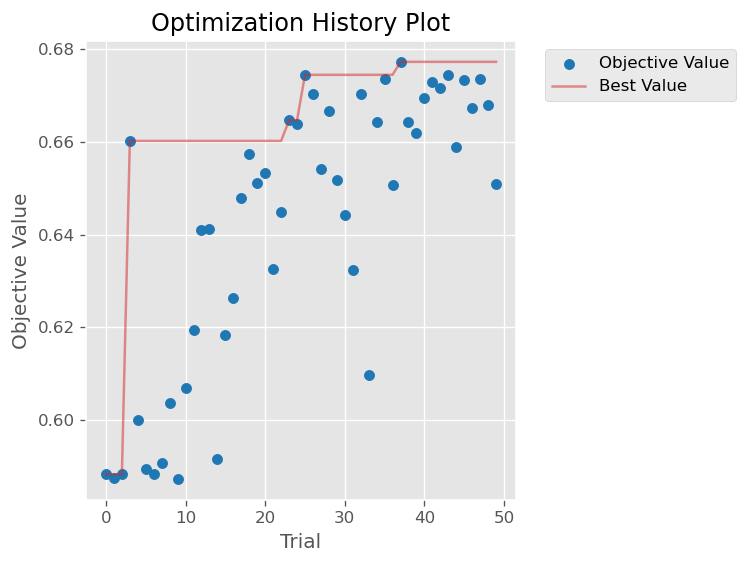

Which settings mattered most:


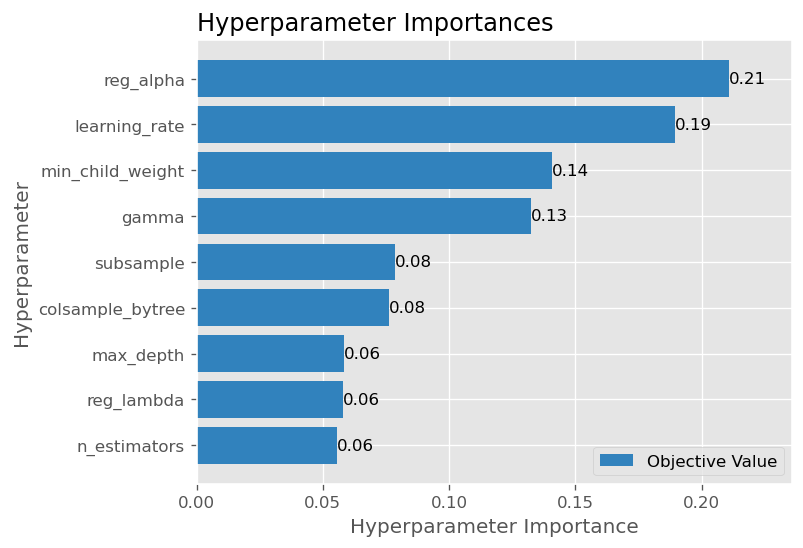

,Untuned RF,Tuned RF,Change
recall,0.6172,0.6289,0.0117
precision,0.7924,0.7751,-0.0173
f1,0.6939,0.6944,0.0005
roc_auc,0.7580,0.7621,0.0041
pr_auc,0.8234,0.8266,0.0032


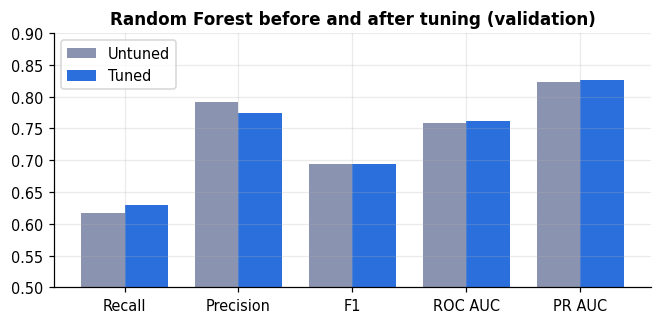

In [43]:
show_img('rf_optimization_history.png', 560, 'Random Forest search history (each dot is one try, the line is the best so far):')
show_img('rf_param_importance.png', 560, 'Which settings mattered most:')
untuned = {k: saved('rf')[k] for k in ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']}; tuned = ev(yva, rf_va)   # untuned numbers from the model development run
tab = pd.DataFrame({'Untuned RF': untuned, 'Tuned RF': tuned}); tab['Change'] = tab['Tuned RF'] - tab['Untuned RF']
display(tab.round(4))
fig, ax = plt.subplots(figsize=(7, 3)); x = np.arange(5); w = .38
ax.bar(x - w / 2, tab['Untuned RF'], w, color=GREY, label='Untuned'); ax.bar(x + w / 2, tab['Tuned RF'], w, color=BLUE, label='Tuned')
ax.set_xticks(x); ax.set_xticklabels(['Recall', 'Precision', 'F1', 'ROC AUC', 'PR AUC']); ax.set_ylim(.5, .9); ax.legend(); ax.set_title('Random Forest before and after tuning (validation)')
plt.show()

**Search record (original run, 50 trials, about 60 minutes)**

* The best validation Recall was **0.6289**, against 0.6172 untuned (plus 1.2 points). Our first run, capped at `max_depth=30`, scored 0.6125, below the default. Widening the range to 50 coincided with the gain.
* Best settings: `max_depth=50`, `n_estimators=124`, `min_samples_split=5`, `min_samples_leaf=1`, `max_features=None`, `class_weight=None`. Choosing `class_weight=None` fits the EDA finding that the classes are nearly balanced, so reweighting had nothing to fix.
* The best value climbed from 0.591 (try 1) to 0.6289 (try 46). Most of the gain came between tries 20 and 33, and the search was close to flat at the end.
* **Setting importance:** `min_samples_split` (0.47) and `min_samples_leaf` (0.34) explain over 80 percent of the variation in Recall.
* **Caveat:** the best of 50 tries scored on one validation set is slightly optimistic by design. Section 5.8 shows how much of it holds up on the test set.

**What we found:** tuning Random Forest on Recall genuinely helped, and it was not just a threshold effect. Both ranking metrics (ROC AUC and PR AUC) improved together with Recall, with a modest Precision cost and a flat F1. A forest has no learning rate or regularization strength that can push probabilities toward the extremes, so the only way to raise Recall is to find trees that separate the classes better, which the improved AUCs confirm.

## 5.3 XGBoost

XGBoost was the backup candidate (Recall 0.6062 at default settings, tied with LightGBM and CatBoost).

### The first attempt was discarded: Recall is the wrong goal for the search

The first search maximized validation Recall at the 0.5 threshold. It reached 0.6773, which looked like a 7 point win. The full check showed it was not:

| Metric | Untuned XGBoost | Tuned for Recall | Change |
|---|---|---|---|
| Recall | 0.6062 | 0.6773 | +0.0711 |
| Precision | 0.8160 | 0.7060 | minus 0.1100 |
| F1 | 0.6956 | 0.6913 | minus 0.0043 |
| ROC AUC | 0.7595 | 0.7405 | minus 0.0190 |
| PR AUC | 0.8250 | 0.8063 | minus 0.0187 |

The model had only moved its alert line toward "late". Precision fell 11 points and both ranking metrics got **worse**. We already have the proper tool for trading Recall against Precision (the threshold, section 5.7). Asking Optuna to do it silently, with no cost on false alarms, just pushes the model to over flag.

**The fix:** tune for ranking quality (**PR AUC**), which does not depend on the threshold, and choose the alert line separately. This also suits the second lens, which depends on how well orders are ranked by risk.

XGBoost search history (PR AUC objective):


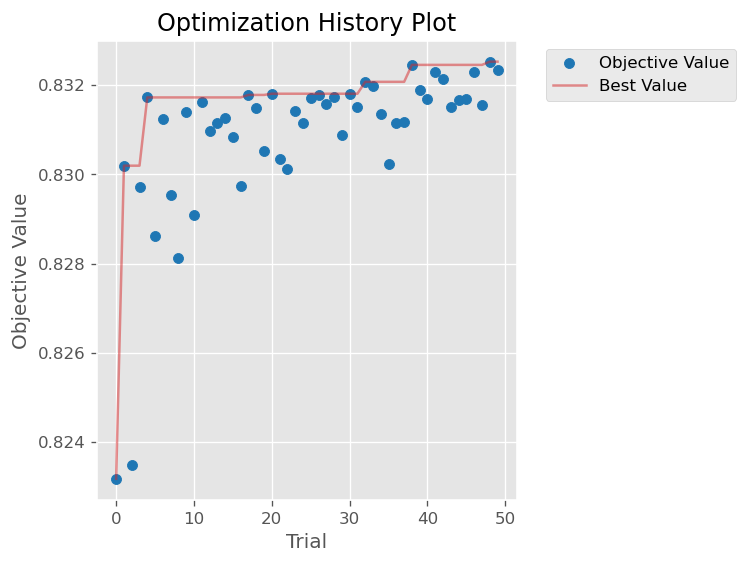

Which settings mattered most:


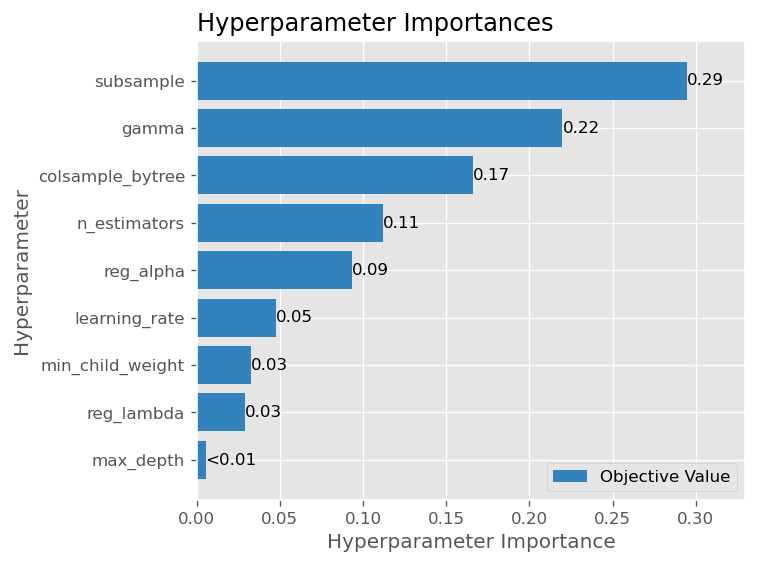

All metrics at the default 0.5 threshold:


,Untuned XGBoost,Tuned XGBoost,Change
recall,0.6062,0.5875,-0.0187
precision,0.8160,0.8462,0.0302
f1,0.6956,0.6935,-0.0021
roc_auc,0.7595,0.7684,0.0089
pr_auc,0.8250,0.8322,0.0072


Precision at the same Recall level:


,Target Recall,Untuned precision,Tuned precision,Difference
0,0.60,0.8261,0.8308,0.0047
1,0.65,0.7599,0.7721,0.0122
2,0.70,0.7033,0.7223,0.0190
3,0.75,0.6680,0.6789,0.0109


In [44]:
show_img('xgb_optuna_history.png', 560, 'XGBoost search history (PR AUC objective):')
show_img('xgb_optuna_importances.png', 560, 'Which settings mattered most:')
xt = pd.DataFrame({'Untuned XGBoost': ev(yva, p_xgb_def), 'Tuned XGBoost': ev(yva, xgb_va)}); xt['Change'] = xt['Tuned XGBoost'] - xt['Untuned XGBoost']
print('All metrics at the default 0.5 threshold:'); display(xt.round(4))
matched = pd.DataFrame([{'Target Recall': t, 'Untuned precision': precision_at_recall(yva, p_xgb_def, t), 'Tuned precision': precision_at_recall(yva, xgb_va, t)} for t in [.60, .65, .70, .75]])
matched['Difference'] = matched['Tuned precision'] - matched['Untuned precision']
print('Precision at the same Recall level:'); display(matched.round(4))

**Search record (original run, 50 trials, about 1 minute)**

* Best validation PR AUC **0.8325**, up from 0.8250 untuned (plus 0.0075). That small gain is the honest size of what tuning adds here, not the inflated 7 points from the Recall goal.
* The best settings describe a slow and steady model: `learning_rate=0.013` (the Recall run chose 0.25), `n_estimators=426`, `max_depth=10`, `subsample=0.99`, `colsample_bytree=0.97`, `gamma=4.95`, `min_child_weight=1`, and almost no L1 or L2 penalty.
* The best value jumped from 0.823 to 0.832 by try 4 and gained only about 0.001 over the other 46 tries, so the search could have stopped around try 10.
* The **setting importance changed completely** compared with the Recall run: `subsample` (0.29), `gamma` (0.22) and `colsample_bytree` (0.17) led, while `reg_alpha` and `learning_rate` led before. Chasing Recall rewards aggressive, fast fitting. Chasing PR AUC rewards control against overfitting.

**What we found: this is a real improvement, confirmed two ways.** At the default 0.5 line the tuned model has *lower* Recall (0.5875 against 0.6062) but higher Precision (0.846 against 0.816), ROC AUC (0.768 against 0.760) and PR AUC (0.832 against 0.825). That alone could be a different line, so the real test is the second table: at **every** Recall level, the tuned model has higher Precision (about 0.5 to 2 points). At the same Recall it gets more of its "late" alerts right, which can only happen if it ranks orders better. The gain is modest but real, exactly what a goal built to reward ranking should produce.

## 5.4 Neural Network

The Neural Network had the best ROC AUC, PR AUC and Precision at default settings but trailed Random Forest on Recall. Does tuning the layer sizes, dropout, learning rate, weight decay and batch size close the gap?

Each try trains a full small network (15 epochs), so tries are much slower than for the trees. We used 30 instead of 50, with PR AUC as the goal (same reason as XGBoost). Inputs are standardized with a scaler fit on the training set only.

> An earlier Neural Network search used a Recall goal and produced a nonsense "best score of 1.0". After that we added a quick smoke test (a fixed setting should give a PR AUC around 0.82 to 0.84). If it ever prints about 1.0, something is leaking and the search must not be run. Ours passed with 0.8295.

In [45]:
class ConfigurableMLP(nn.Module):
    def __init__(self, n_features, h1, h2, d1, d2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_features, h1), nn.ReLU(), nn.Dropout(d1), nn.Linear(h1, h2), nn.ReLU(), nn.Dropout(d2), nn.Linear(h2, 1))
    def forward(self, x): return self.net(x)

nn_scaler = joblib.load(MODELS / 'nn_scaler.pkl')
nn_tuned = ConfigurableMLP(len(FEATURES), nn_params['hidden1'], nn_params['hidden2'], nn_params['dropout1'], nn_params['dropout2'])
nn_tuned.load_state_dict(torch.load(MODELS / 'neural_network_tuned.pt', map_location='cpu')); nn_tuned.eval()
def p_nn(X):
    with torch.no_grad(): return torch.sigmoid(nn_tuned(torch.tensor(nn_scaler.transform(X).astype(np.float32))).squeeze(1)).numpy()
nn_va = p_nn(Xva)
nt = pd.DataFrame({'Untuned NN': {k: saved('nn')[k] for k in ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']}, 'Tuned NN': ev(yva, nn_va)}); nt['Change'] = nt['Tuned NN'] - nt['Untuned NN']
display(nt.round(4))

,Untuned NN,Tuned NN,Change
recall,0.5857,0.5866,0.0009
precision,0.8458,0.8463,0.0005
f1,0.6921,0.6929,0.0008
roc_auc,0.7653,0.7647,-0.0005
pr_auc,0.8301,0.8293,-0.0008


**Search record (original run, 30 trials, about 20 minutes).** The best validation PR AUC was **0.8307**, barely above the untuned network's 0.8301 (plus 0.0006). That is essentially no gain, unlike Random Forest (plus 0.0032) or XGBoost (plus 0.0075). The best settings (`lr=0.0013`, `hidden1=64`, `hidden2=32`, `batch_size=256`) all sit well inside their search ranges, so the search space was not the limit. The untuned network was already close to the best this space allows.

**What we found: essentially no change in either direction.** Every difference is within about 0.1 point, smaller than the variation between random starting values. This is not the pattern of XGBoost's first attempt (Precision down 11 points, ROC AUC down 1.9). It is noise around a flat line. Two reasonable explanations: a two layer network is already near its ceiling for 46,026 rows and 28 features, or our earlier defaults were already a solid choice. Either way there is no reason to prefer the tuned network over the untuned one.

## 5.5 Which tuned model goes forward?

At the default 0.5 line the three models look different (Random Forest has the best Recall, the others the best Precision). But that mostly shows where each model draws its line. **The fair comparison is Precision at the same Recall**, because the final alert line is chosen from a Recall target.

Tuned models, validation set, default 0.5 threshold:


,Random Forest,XGBoost,Neural Network
recall,0.6289,0.5875,0.5866
precision,0.7751,0.8462,0.8463
f1,0.6944,0.6935,0.6929
roc_auc,0.7621,0.7684,0.7647
pr_auc,0.8266,0.8322,0.8293


Precision at the same Recall:


,Random Forest,XGBoost,Neural Network
Target Recall,,,
0.60,0.8119,0.8308,0.8239
0.65,0.7582,0.7721,0.7513
0.70,0.7039,0.7223,0.7086
0.75,0.6666,0.6789,0.6695
0.80,0.6405,0.6399,0.6407
0.85,0.6171,0.6169,0.6164
0.90,0.5921,0.5937,0.5940


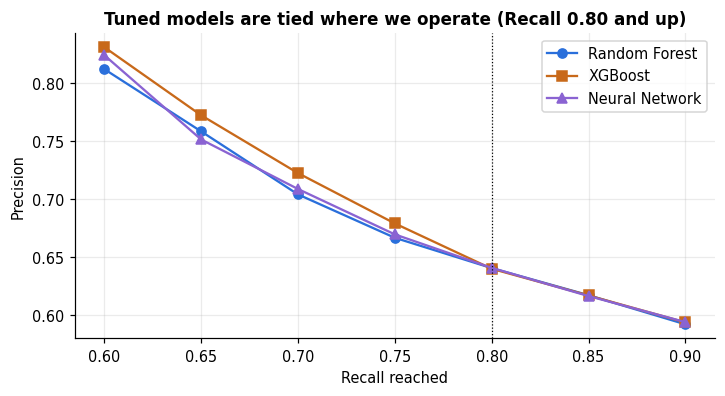

In [46]:
val_scores = {'Random Forest': rf_va, 'XGBoost': xgb_va, 'Neural Network': nn_va}
print('Tuned models, validation set, default 0.5 threshold:')
display(pd.DataFrame({k: ev(yva, v) for k, v in val_scores.items()}).round(4))
targets = [.60, .65, .70, .75, .80, .85, .90]
mt = pd.DataFrame({k: [precision_at_recall(yva, v, t) for t in targets] for k, v in val_scores.items()}, index=pd.Index(targets, name='Target Recall'))
print('Precision at the same Recall:'); display(mt.round(4))
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for (k, col), mk in zip([('Random Forest', BLUE), ('XGBoost', ORANGE), ('Neural Network', PURPLE)], ['o', 's', '^']):
    ax.plot(targets, mt[k], mk + '-', color=col, label=k)
ax.axvline(.8, color='black', lw=.8, ls=':'); ax.set_xlabel('Recall reached'); ax.set_ylabel('Precision'); ax.legend(); ax.set_title('Tuned models are tied where we operate (Recall 0.80 and up)')
plt.show()

**What we found: the three tuned models are tied at the point we actually use.**

* At Recall 0.80 and above, Precision is about **0.64** for all three, within half a point. At 0.85 and 0.90 the gaps are even smaller.
* At lower Recall targets (0.60 to 0.75), XGBoost is ahead by about 1 to 2 points. That is the part of the curve we do not use.
* On ranking (ROC AUC and PR AUC), XGBoost is the best tuned model by a small margin and Random Forest the weakest of the three. The differences are about 0.005 to 0.01.

**Decision: the final report model is the tuned Random Forest.** It was the Recall leader going into tuning, the later threshold and test sections are built on it, and at Recall 0.80 it is not worse than the others. This is a defensible choice, not a clear win. XGBoost is an equally good alternative, and much faster to explain with SHAP (1 second against about 15 minutes). Later, for the web app, we used XGBoost for exactly that reason (section 5.9).

## 5.6 SHAP explainability

This settles the `order_hour` question we left open: Random Forest's permutation importance ranked it second, while XGBoost's gain importance ranked it near last. **SHAP** shows how much each feature pushed each single prediction up or down, and does not share the biases of either built in measure. It also prototypes the "why is this risky?" panel for the app.

SHAP for a forest of 124 deep trees costs about 15 minutes on 1,000 rows, so the Random Forest values were computed once and saved (`models/shap_values_rf_n1000.npy`). We run on a **random sample of 1,000 validation rows**, which gives a near identical picture for summary plots. For XGBoost we compute SHAP values here directly (about 1 second).

Random Forest SHAP shape: (1000, 28)  XGBoost SHAP shape: (1000, 28)
order_hour rank: Random Forest 4  XGBoost 4 (of 28)


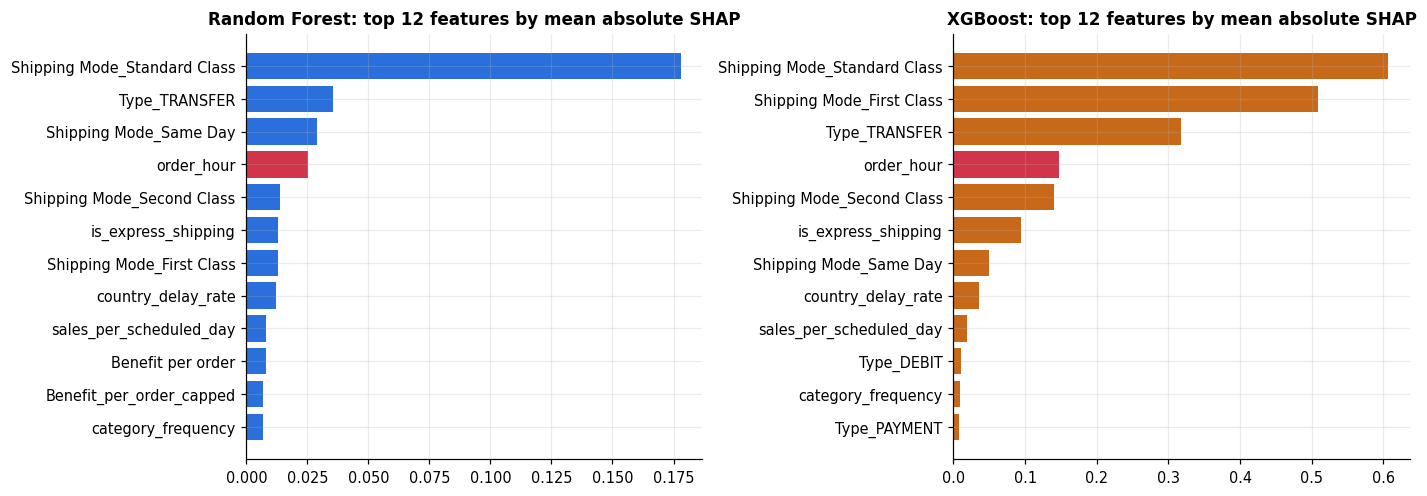

Full SHAP summary for the Random Forest (each dot is one order, red is a high feature value):


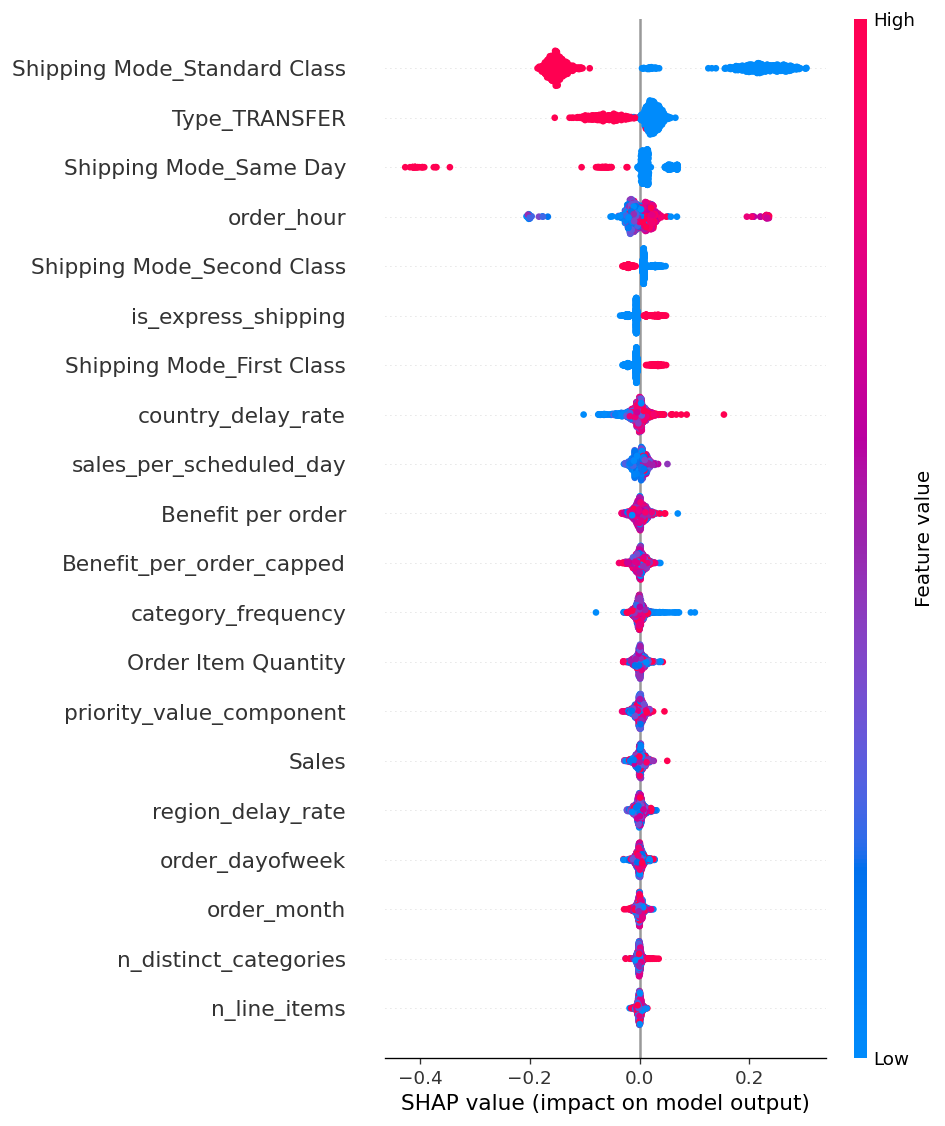

Full SHAP summary for XGBoost:


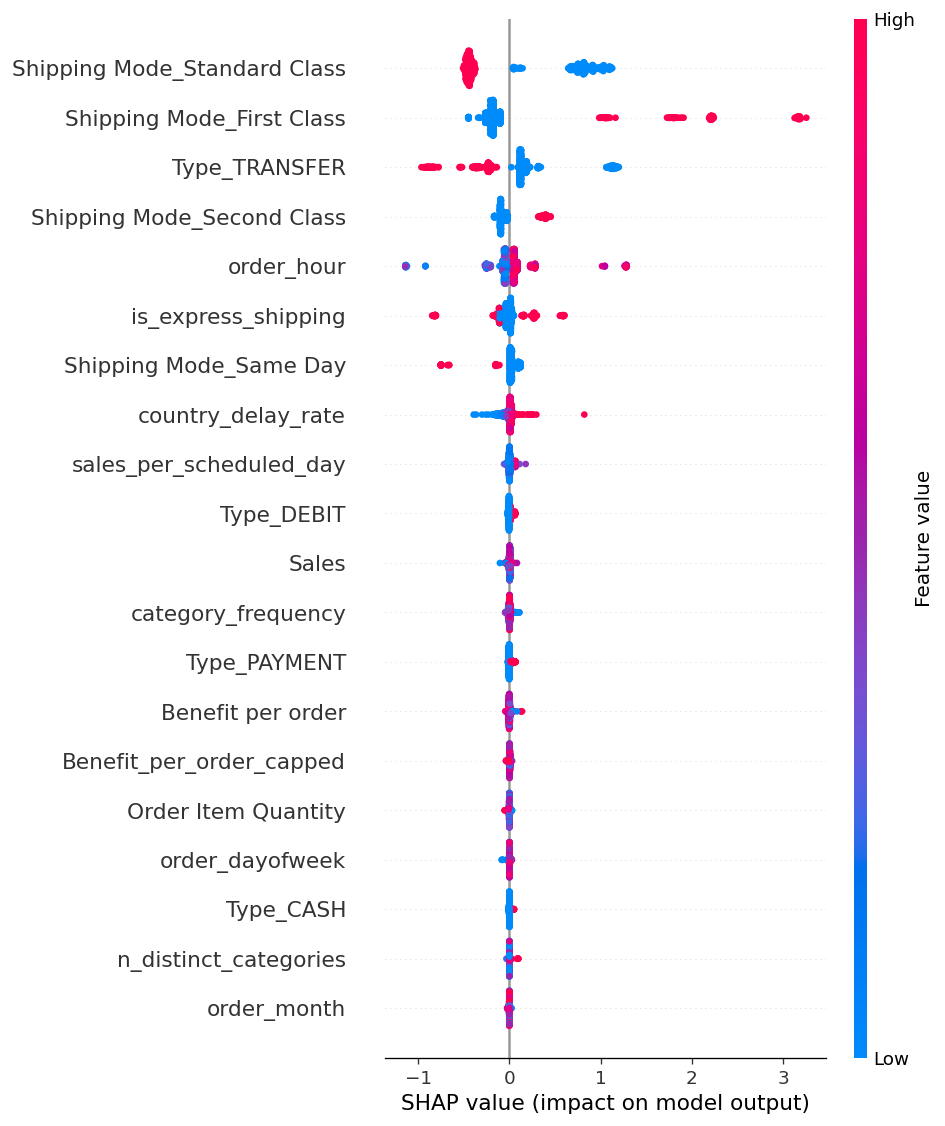

In [47]:
sample = Xva.sample(n=1000, random_state=SEED)                 # the same sample the saved Random Forest values were made on
sv_all = np.load(MODELS / 'shap_values_rf_n1000.npy')
sv_rf = sv_all[:, :, 1] if sv_all.ndim == 3 else sv_all          # the late class
contrib = bst.predict(xgb.DMatrix(sample.values, feature_names=list(sample.columns)), pred_contribs=True)
sv_xgb, xgb_base = contrib[:, :-1], contrib[0, -1]
print('Random Forest SHAP shape:', sv_rf.shape, ' XGBoost SHAP shape:', sv_xgb.shape)

imp_rf = pd.Series(np.abs(sv_rf).mean(0), index=FEATURES).sort_values(ascending=False)
imp_xgb = pd.Series(np.abs(sv_xgb).mean(0), index=FEATURES).sort_values(ascending=False)
print('order_hour rank: Random Forest', list(imp_rf.index).index('order_hour') + 1, ' XGBoost', list(imp_xgb.index).index('order_hour') + 1, '(of 28)')
fig, axs = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, imp, title, col in [(axs[0], imp_rf, 'Random Forest', BLUE), (axs[1], imp_xgb, 'XGBoost', ORANGE)]:
    t = imp.head(12).iloc[::-1]; ax.barh(t.index, t.values, color=[RED if i == 'order_hour' else col for i in t.index]); ax.set_title(f'{title}: top 12 features by mean absolute SHAP')
plt.tight_layout(); plt.show()
show_img('shap_summary_rf.png', 640, 'Full SHAP summary for the Random Forest (each dot is one order, red is a high feature value):')
show_img('shap_summary_xgb.png', 640, 'Full SHAP summary for XGBoost:')

**What we found (Random Forest).** `order_hour` ranks **4th of 28** by mean absolute SHAP value, behind `Shipping Mode_Standard Class`, `Type_TRANSFER` and `Shipping Mode_Same Day`. So SHAP confirms the permutation result: in the forest, `order_hour` is a truly important feature and not a trick of the default measure.

Shipping mode as a group still dominates. The shipping mode columns and `is_express_shipping` take 5 of the top 8 places, and `Shipping Mode_Standard Class` alone is about five times as important as the next feature. The directions match EDA: Standard Class equal to 1 pushes risk down (it had the lowest late rate, 38 percent), while First Class and `is_express_shipping` push it up. Credit is split across the shipping mode columns because they are correlated, so no single column shows the whole shipping mode effect.

Two more observations:

* `Type_TRANSFER` ranks 2nd and pushes risk down whenever it equals 1. This is a stronger payment type effect than anything the EDA suggested, and it is worth a look before the final report.
* `order_hour` does not act like a smooth effect on all orders. Most orders sit in a tight band near zero, and two small, separate groups sit at about minus 0.2 (early hours) and plus 0.2 (late hours). Much of its importance comes from those groups. Section 5.6.2 finds out who they are.

**What we found (XGBoost).** `order_hour` ranks in the **top 5 of 28** (4th in the run above, 5th in our earlier run, the two are close), behind the shipping mode columns and `Type_TRANSFER`. This is the opposite of XGBoost's gain importance (near last), so **the earlier chart was misleading, not the feature**. Both models agree on the main picture: shipping mode, `Type_TRANSFER` and `order_hour` are in the top 5, and both rank `country_delay_rate` below `order_hour`. The answer to our open question is fairly solid: **`order_hour` is a top 5 feature in both tuned models once it is measured with SHAP.**

Things to keep in mind: XGBoost values are in log odds and Random Forest values in probability units, so compare the *rankings*, not the axis widths. XGBoost ranks First Class 2nd while Random Forest ranks it 7th and gives Same Day more credit. The shipping mode columns overlap, so each model splits the credit differently. That is not a real disagreement about shipping mode.

### 5.6.2 Does `order_hour` interact with Shipping Mode?

The hour is nearly flat in EDA. Why would SHAP rank it so high? The idea: it matters only for some special group. We plot the SHAP value of `order_hour` against the hour, and colour by shipping mode.

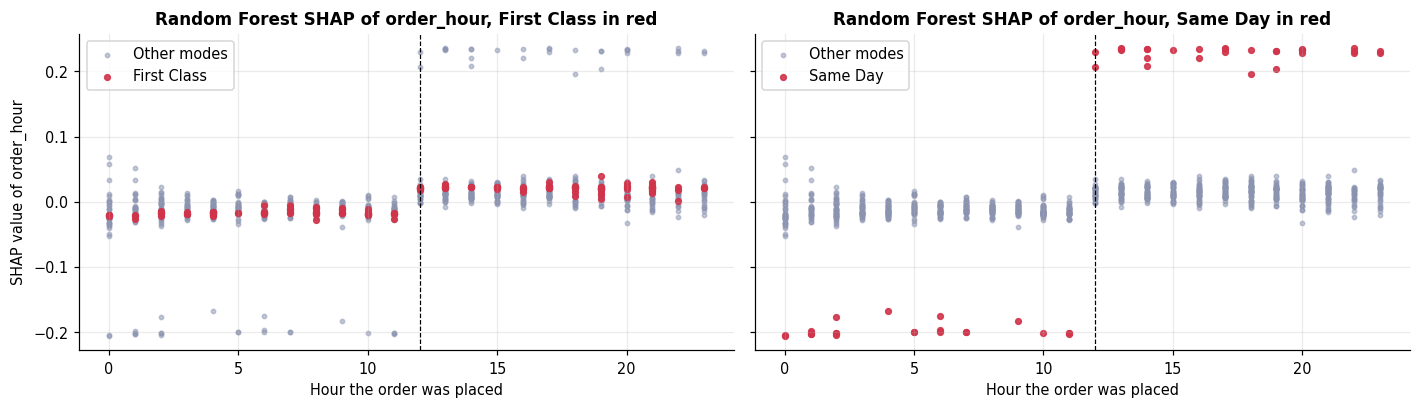

In [48]:
hour_val = val['order date (DateOrders)'].dt.hour.values[Xva.index.get_indexer(sample.index)]
j = FEATURES.index('order_hour')
fig, axs = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, col, name in [(axs[0], 'Shipping Mode_First Class', 'First Class'), (axs[1], 'Shipping Mode_Same Day', 'Same Day')]:
    m = sample[col].values == 1
    ax.scatter(hour_val[~m], sv_rf[~m, j], s=8, color=GREY, alpha=.5, label='Other modes'); ax.scatter(hour_val[m], sv_rf[m, j], s=14, color=RED, alpha=.9, label=name)
    ax.axvline(12, color='black', ls='--', lw=.8); ax.set_xlabel('Hour the order was placed'); ax.set_title(f'Random Forest SHAP of order_hour, {name} in red'); ax.legend()
axs[0].set_ylabel('SHAP value of order_hour')
plt.tight_layout(); plt.show()

**What we found.** Colouring by First Class **does not** split the points: nearly every point is grey, and the few red ones sit inside the main band. So the guess that the hour matters for First Class orders is **not supported**. What the left picture does show:

* **A step at noon.** In the main band, orders before 12:00 have a slightly negative SHAP value (about minus 0.01) and orders from 12:00 a slightly positive one (about plus 0.01). That is a very small effect, a point or two of probability, which fits EDA's finding that the hour is weak on its own.
* **Two separate groups far from the main band**, at about plus 0.2 (hours 12 to 23) and about minus 0.2 (hours 0 to 11). They follow the same noon split but are ten times bigger. They are not First Class orders, so another feature is involved. The right picture (colour by Same Day) and the next cell find out which.

53 of 1000 sampled orders have |SHAP of order_hour| above 0.1



,share in the large effect group,share in all sampled orders
Shipping Mode_First Class,0.0,0.154
Shipping Mode_Same Day,1.0,0.053
Shipping Mode_Second Class,0.0,0.211
Shipping Mode_Standard Class,0.0,0.582


,Data,Same Day orders,Orders,Late rate
0,Train,placed before 12:00,1332,0.000
1,Train,placed 12:00 or later,1146,0.960
2,Validation,placed before 12:00,206,0.000
3,Validation,placed 12:00 or later,236,0.945


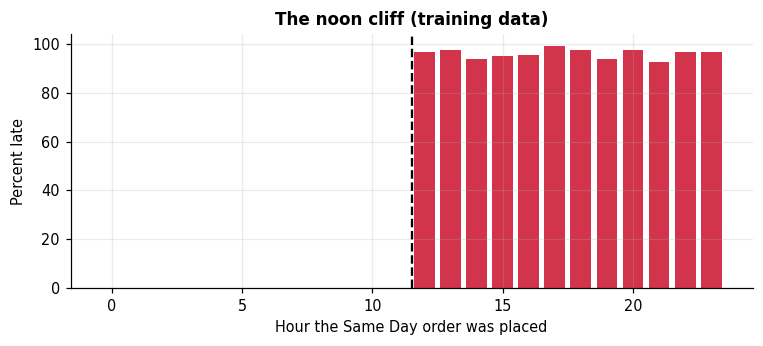

In [49]:
big = np.abs(sv_rf[:, j]) > 0.1
print(f'{big.sum()} of {len(big)} sampled orders have |SHAP of order_hour| above 0.1\n')
mode_cols = [c for c in FEATURES if c.startswith('Shipping Mode_')]
who = pd.DataFrame({'share in the large effect group': sample.loc[big, mode_cols].mean(), 'share in all sampled orders': sample[mode_cols].mean()}).round(3); display(who)

# The noon cliff in the real data, training and validation
rows = []
for name, part in [('Train', train), ('Validation', val)]:
    sd = part[part['Shipping Mode'] == 'Same Day']; h = sd['order date (DateOrders)'].dt.hour
    rows.append([name, 'placed before 12:00', int((h < 12).sum()), sd.loc[h < 12, 'Late_delivery_risk'].mean()])
    rows.append([name, 'placed 12:00 or later', int((h >= 12).sum()), sd.loc[h >= 12, 'Late_delivery_risk'].mean()])
cliff = pd.DataFrame(rows, columns=['Data', 'Same Day orders', 'Orders', 'Late rate']); display(cliff.round(3))
sd = train[train['Shipping Mode'] == 'Same Day']; hh = sd['order date (DateOrders)'].dt.hour
rate_by_hour = sd.groupby(hh)['Late_delivery_risk'].mean() * 100
fig, ax = plt.subplots(figsize=(8, 3)); ax.bar(rate_by_hour.index, rate_by_hour.values, color=[TEAL if h < 12 else RED for h in rate_by_hour.index])
ax.axvline(11.5, color='black', ls='--'); ax.set_xlabel('Hour the Same Day order was placed'); ax.set_ylabel('Percent late'); ax.set_title('The noon cliff (training data)')
plt.show()

**What we found: the large `order_hour` effects belong to Same Day shipping, and the interaction is very strong.**

All 53 sampled orders with a large hour effect are **Same Day** orders. Same Day is only 5 percent of the sample, so this is essentially every Same Day order. 30 were placed from 12:00 onward and pushed risk up, 23 were placed before noon and pushed it down. XGBoost's large effect group is the same 53 orders, so both models found the same thing.

The training data shows why: **Same Day orders placed before 12:00 were never late (0 of 1,332). Same Day orders placed at 12:00 or later were late 96 percent of the time (about 1,100 of 1,146).** The validation set shows the same (0 percent against about 95 percent). So `order_hour` matters through one single interaction: for Same Day shipping, the hour of the order decides almost everything.

**This solves the original puzzle.** EDA found the hour flat because Same Day orders are only about 5 to 6 percent of the data, so the effect disappears when all orders are averaged together. The default importance measures could see it because a tree uses the hour to split exactly those orders.

Two points for the report. First, **this is not leakage**: both the shipping mode and the order hour are known when the order is placed. Second, a split this clean (0 against 96 percent) looks like a rule built into the dataset, for example a same day cutoff around noon. It may be stronger than real operations would show. It also makes a very explainable message for the app: "Same Day order placed after noon".

### 5.6.3 One order explained (prototype for the app panel)

A waterfall shows how one prediction is built: it starts at the average risk and each feature pushes it up (red) or down (green).

Order in the sample (scaled values shown for the number features). Shipping mode: ['Shipping Mode_Standard Class']


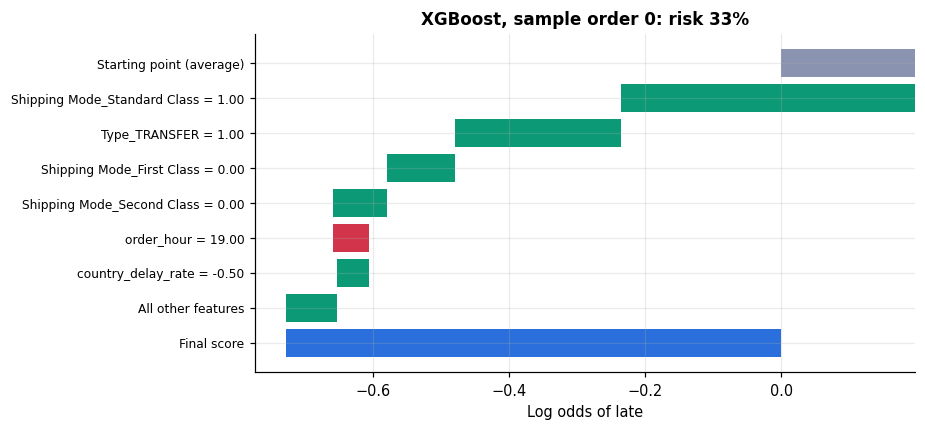

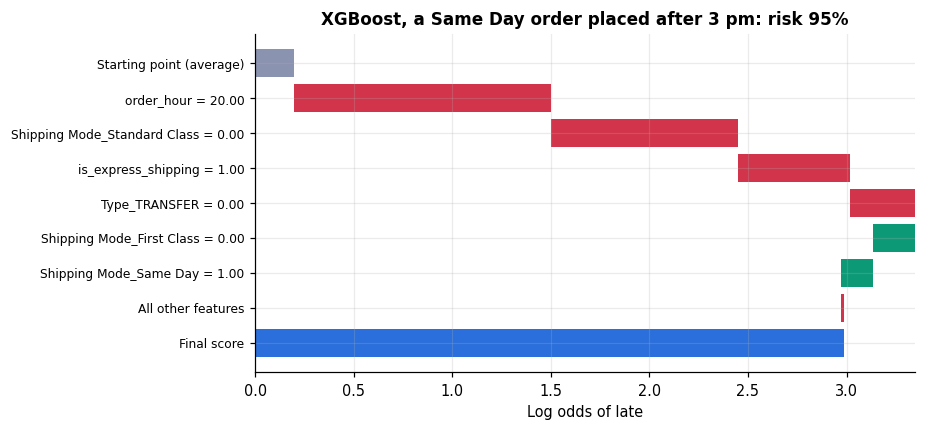

In [50]:
def waterfall(sv_row, base, title, k=6):
    s = pd.Series(sv_row, index=FEATURES); top = s.reindex(s.abs().sort_values(ascending=False).index)[:k]; rest = s.sum() - top.sum()
    labels = ['Starting point (average)'] + [f'{n} = {sample.iloc[idx][n]:.2f}' for n in top.index] + ['All other features', 'Final score']
    steps = [base] + list(top.values) + [rest]; cum = np.cumsum(steps); prev = 0
    fig, ax = plt.subplots(figsize=(8.5, 4))
    for i, v in enumerate(steps):
        ax.barh(i, v, left=0 if i == 0 else prev, color=GREY if i == 0 else (RED if v > 0 else GREEN)); prev = cum[i]
    ax.barh(len(steps), cum[-1], color=BLUE); ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8); ax.invert_yaxis()
    ax.set_xlabel('Log odds of late'); ax.set_title(f'{title}: risk {100 / (1 + np.exp(-cum[-1])):.0f}%'); plt.tight_layout(); plt.show()

idx = 0
print('Order in the sample (scaled values shown for the number features). Shipping mode:', [c for c in mode_cols if sample.iloc[idx][c] == 1])
waterfall(sv_xgb[idx], xgb_base, 'XGBoost, sample order 0')
same_after = np.where((sample['Shipping Mode_Same Day'].values == 1) & (hour_val >= 15))[0][0]; idx = same_after
waterfall(sv_xgb[idx], xgb_base, 'XGBoost, a Same Day order placed after 3 pm')

**What we found:** the first order (sample 0) has a low risk: Standard Class shipping is the biggest push down, followed by `Type_TRANSFER` and `sales_per_scheduled_day`, with `order_hour` and a negative `Benefit per order` pushing a little up. This matches the summary plots, so the explanation agrees with the model's overall behaviour. The second order, a Same Day order placed after 3 pm, shows the noon rule at work.

It is not ready for non technical operations users yet, for three reasons: (1) feature names are technical (`Shipping Mode_Standard Class = 1.0`), and the app should say "shipped by Standard Class"; (2) values are mixed, raw for some and standardized for others (a scaled `sales_per_scheduled_day = -0.88` means nothing to a user), so the app should show real units; (3) the top 3 to 5 reasons in words read better than 28 labels. All three were done in the web app.

## 5.7 Choosing the alert threshold (validation data only)

All models so far used the default 0.5 line. The business says a missed late order costs more than an unnecessary check, so the line should reflect that. Everything in this section uses the **validation set** and the tuned Random Forest.

### 5.7.1 A cost based threshold, and why it fails here

We start with placeholder costs: a missed late order costs 3, a false alarm costs 1. We search for the threshold with the lowest total cost.

Threshold with the lowest expected cost: 0.11  (Recall 0.9998, Precision 0.5575, flagged 97.3%)
Cost, flag nothing:          12,837
Cost, default 0.5:           5,545
Cost, best threshold:        3,399
Cost, flag EVERYTHING:       3,611


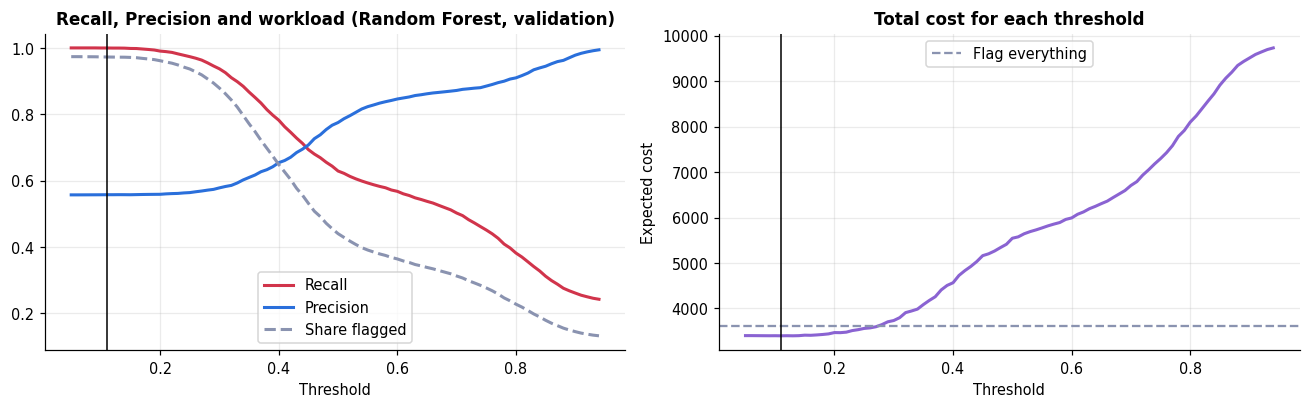

In [51]:
COST_FN, COST_FP = 3.0, 1.0
ths = np.round(np.arange(0.05, 0.95, 0.01), 2)
def sweep(y, s):
    rows = []
    for t in ths:
        pred = s >= t; tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
        rows.append({'threshold': t, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp, 'recall': tp / (tp + fn), 'precision': tp / max(tp + fp, 1), 'flagged': pred.mean()})
    return pd.DataFrame(rows)
R = sweep(yva, rf_va); R['cost'] = R['fn'] * COST_FN + R['fp'] * COST_FP
best = R.loc[R['cost'].idxmin()]
print(f'Threshold with the lowest expected cost: {best.threshold:.2f}  (Recall {best.recall:.4f}, Precision {best.precision:.4f}, flagged {best.flagged * 100:.1f}%)')
n_pos, n_neg = yva.sum(), (1 - yva).sum()
print(f'Cost, flag nothing:          {n_pos * COST_FN:,.0f}')
print(f'Cost, default 0.5:           {R.loc[R.threshold == .5, "cost"].iloc[0]:,.0f}')
print(f'Cost, best threshold:        {best.cost:,.0f}')
print(f'Cost, flag EVERYTHING:       {n_neg * COST_FP:,.0f}')
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8))
axs[0].plot(R.threshold, R.recall, color=RED, lw=2, label='Recall'); axs[0].plot(R.threshold, R.precision, color=BLUE, lw=2, label='Precision'); axs[0].plot(R.threshold, R.flagged, color=GREY, ls='--', lw=2, label='Share flagged')
axs[0].axvline(best.threshold, color='black', lw=1); axs[0].set_xlabel('Threshold'); axs[0].legend(); axs[0].set_title('Recall, Precision and workload (Random Forest, validation)')
axs[1].plot(R.threshold, R.cost, color=PURPLE, lw=2); axs[1].axhline(n_neg * COST_FP, color=GREY, ls='--', label='Flag everything'); axs[1].axvline(best.threshold, color='black', lw=1)
axs[1].set_xlabel('Threshold'); axs[1].set_ylabel('Expected cost'); axs[1].legend(); axs[1].set_title('Total cost for each threshold')
plt.tight_layout(); plt.show()

**What we found.** With a 3 to 1 cost ratio the cost best threshold is **0.11**, giving Recall 0.9998 and Precision 0.5575. That looks like a big win over the default 0.5 (Recall 0.629, Precision 0.775), but it is **not a useful result**.

Precision 0.5575 is almost exactly the late share in validation (54.2 percent). At this line the model flags about **97 percent of all orders**, which is the same as flagging everything. The reference costs prove it: flagging everything costs 3,611, the "best" threshold costs 3,399 (only about 6 percent lower), and the default 0.5 costs about 5,545, which is *worse than flagging everything*.

The reason is arithmetic, not a bug. When more than half the orders are late and a miss costs 3 times a false alarm, "act on everything" is cheaper than any selective rule that a model with ROC AUC near 0.76 can make. A cost matrix like this cannot produce a short, actionable list, and a short list is the whole point of the project.

### 5.7.2 Would a different cost ratio fix it?

In [52]:
rows = []
for ratio in [1, 2, 3, 5, 10]:
    c = R['fn'] * ratio + R['fp']; r = R.loc[c.idxmin()]
    rows.append({'cost of a miss : cost of a false alarm': f'{ratio}:1', 'best threshold': round(r.threshold, 2), 'recall': round(r.recall, 3), 'precision': round(r.precision, 3), 'share flagged': f'{r.flagged * 100:.0f}%'})
display(pd.DataFrame(rows))

,cost of a miss : cost of a false alarm,best threshold,recall,precision,share flagged
0,1:1,0.58,0.578,0.838,37%
1,2:1,0.13,1.000,0.558,97%
2,3:1,0.11,1.000,0.557,97%
3,5:1,0.09,1.000,0.557,97%
4,10:1,0.09,1.000,0.557,97%


**What we found:** only a 1 to 1 ratio gives a selective rule (threshold 0.58, Recall 0.578, Precision 0.838, 37 percent flagged), and that simply means "both mistakes cost the same", which contradicts our Recall first framing. From 2 to 1 upward the best rule flags 97 percent of orders. The rule jumps from selective to "flag everything" somewhere between 1 to 1 and 2 to 1.

**Conclusion:** a single cost ratio is the wrong tool for choosing the line on this dataset. We choose the operating point from a **Recall target** and the **share of orders the team can realistically check**.

### 5.7.3 Choosing the line from a Recall target and a workload limit

For each Recall target we find the **highest** threshold that still reaches it (the highest threshold flags the fewest orders and so gives the best Precision), and we report how many orders the team would have to act on.

,Recall target,threshold,recall,precision,orders flagged
0,0.65,0.48,0.655,0.754,47%
1,0.70,0.44,0.712,0.695,56%
2,0.75,0.41,0.762,0.661,63%
3,0.80,0.38,0.814,0.633,70%
4,0.85,0.36,0.851,0.617,75%
5,0.90,0.32,0.910,0.586,84%


,team can act on,share that are truly late,share of all late orders caught
0,top 5% (394 orders),1.000,0.092
1,top 10% (789 orders),1.000,0.184
2,"top 20% (1,578 orders)",0.932,0.344
3,"top 30% (2,367 orders)",0.877,0.485


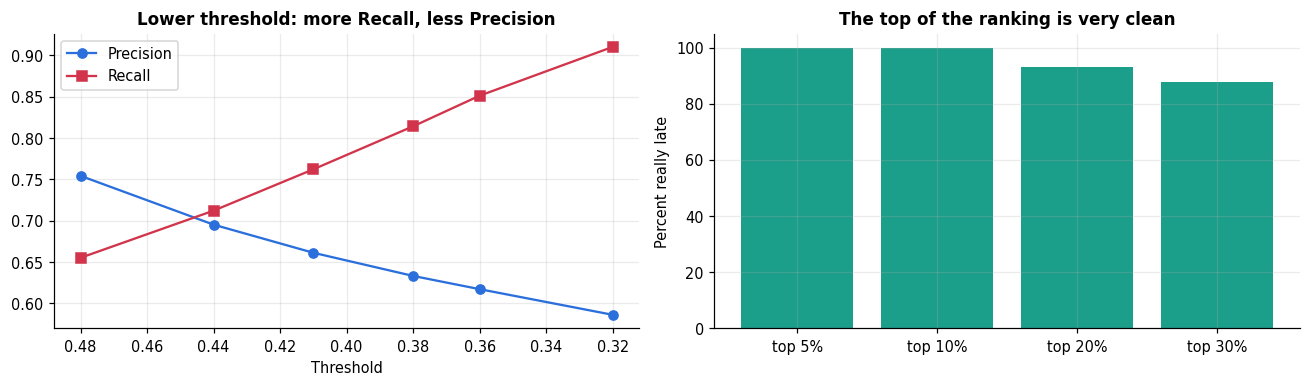

In [53]:
rows = []
for target in [.65, .70, .75, .80, .85, .90]:
    ok = R[R.recall >= target]; r = ok.loc[ok.threshold.idxmax()]
    rows.append({'Recall target': target, 'threshold': round(r.threshold, 2), 'recall': round(r.recall, 3), 'precision': round(r.precision, 3), 'orders flagged': f'{r.flagged * 100:.0f}%'})
tgt = pd.DataFrame(rows); display(tgt)

def top_k(y, s, ks=(.05, .10, .20, .30)):
    order = np.argsort(-s, kind='stable'); rows = []
    for k in ks:
        n = int(len(y) * k); idx = order[:n]
        rows.append({'team can act on': f'top {k * 100:.0f}% ({n:,} orders)', 'share that are truly late': y[idx].mean(), 'share of all late orders caught': y[idx].sum() / y.sum()})
    return pd.DataFrame(rows)
tk = top_k(yva, rf_va); display(tk.round(3))

fig, axs = plt.subplots(1, 2, figsize=(12, 3.6))
axs[0].plot(tgt['threshold'], tgt['precision'], 'o-', color=BLUE, label='Precision'); axs[0].plot(tgt['threshold'], tgt['recall'], 's-', color=RED, label='Recall')
axs[0].set_xlabel('Threshold'); axs[0].invert_xaxis(); axs[0].legend(); axs[0].set_title('Lower threshold: more Recall, less Precision')
axs[1].bar(tk['team can act on'].str.extract(r'(top \d+%)')[0], tk['share that are truly late'] * 100, color=TEAL); axs[1].set_ylim(0, 105); axs[1].set_ylabel('Percent really late'); axs[1].set_title('The top of the ranking is very clean')
plt.tight_layout(); plt.show()

**What we found.** Recall rises steadily as the threshold falls, and Precision falls with it:

| Recall target | Threshold | Precision | Orders flagged |
|---|---|---|---|
| 0.65 | 0.48 | 0.754 | 47% |
| 0.70 | 0.44 | 0.695 | 56% |
| 0.75 | 0.41 | 0.661 | 63% |
| 0.80 | 0.38 | 0.633 | 70% |
| 0.85 | 0.36 | 0.617 | 75% |
| 0.90 | 0.32 | 0.586 | 84% |

Going from the default 0.5 (Recall 0.629, Precision 0.775) to **0.38** buys about 18 points of Recall (to 0.81) for about 14 points of Precision, but the team must then act on 70 percent of orders. Above a 0.85 target the gain flattens: the last five points of Recall cost 9 percent more orders flagged and 3 more points of Precision.

For the second lens, **the top of the ranking is very clean**: the 10 percent of orders with the highest risk are late 100 percent of the time (about 789 orders) and the top 20 percent are 93 percent late. Ranking by risk, then by value, is where the model is most useful, more than the yes or no alert.

**Recommended default: Recall target 0.80, threshold 0.38.** This is a placeholder for a group decision: the right target depends on how many orders the team can really check each day, which we do not know yet.

### 5.7.4 Who is in the top 10 percent?

The top of the ranking is perfectly clean. Before celebrating, we check what it is made of.

Top 10% = 789 orders. Share by shipping mode:
First Class       85.3
Same Day          14.7
Second Class       0.0
Standard Class     0.0
Same Day orders placed 12:00 or later: 14.7% of the top 10%
Late rate of First Class orders overall (validation): 0.946


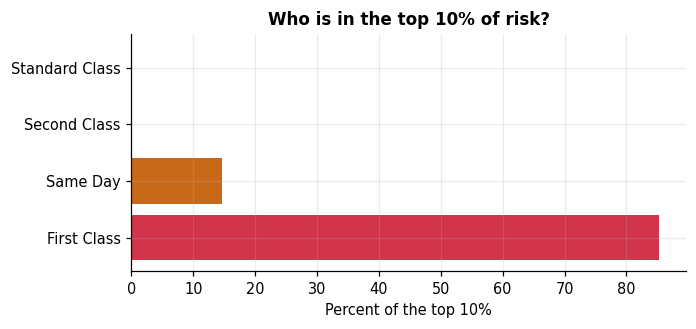

In [54]:
n_top = int(len(Xva) * .10); top_idx = np.argsort(-rf_va, kind='stable')[:n_top]
top10 = Xva.iloc[top_idx]
share_mode = top10[mode_cols].mean().rename(lambda c: c.replace('Shipping Mode_', ''))
h = val['order date (DateOrders)'].dt.hour.values[top_idx]
after_noon_sd = ((top10['Shipping Mode_Same Day'].values == 1) & (h >= 12)).mean()
print(f'Top 10% = {n_top} orders. Share by shipping mode:'); print((share_mode * 100).round(1).to_string())
print(f'Same Day orders placed 12:00 or later: {after_noon_sd * 100:.1f}% of the top 10%')
print(f'Late rate of First Class orders overall (validation): {val.loc[val["Shipping Mode"] == "First Class", "Late_delivery_risk"].mean():.3f}')
fig, ax = plt.subplots(figsize=(6.5, 2.8)); ax.barh(share_mode.index, share_mode.values * 100, color=[RED, ORANGE, TEAL, GREEN]); ax.set_xlabel('Percent of the top 10%'); ax.set_title('Who is in the top 10% of risk?'); plt.show()

**What we found:** the top 10 percent is made of **First Class orders (about 85 percent)** and **Same Day orders placed from noon on (about 15 percent)**. These are the two groups that were already about 95 percent late. So the clean top of the list is concentrated in the shipping mode groups that EDA flagged, not spread across all kinds of orders. The model does add something inside those groups: the top 789 contain no on time order, even though First Class has some, so it ranks the late ones above the on time ones.

**For the report, say plainly:** the "top 10 percent are all late" result is largely a shipping mode result, and the harder question is how well the model ranks the middle of the list.

In [55]:
ok = R[R.recall >= 0.80]; chosen = ok.loc[ok.threshold.idxmax()]
saved_thr = json.load(open(DATA / 'chosen_threshold.json'))
assert abs(chosen.threshold - saved_thr['threshold']) < 1e-9 and abs(best.threshold - saved_thr['cost_optimal_threshold_for_reference']) < 1e-9
CHOSEN = float(chosen.threshold)
print(f'Chosen threshold {CHOSEN} (validation Recall {chosen.recall:.3f}, Precision {chosen.precision:.3f}, {chosen.flagged * 100:.0f}% flagged). It matches chosen_threshold.json.')

Chosen threshold 0.38 (validation Recall 0.814, Precision 0.633, 70% flagged). It matches chosen_threshold.json.


## 5.8 Final test set evaluation

**This is the one and only time the test set is opened for the report model.** Everything above (model comparison, tuning, threshold) used train and validation only. We apply the tuned Random Forest and the saved threshold to the test data and report the result as it is.

### 5.8.1 Leakage audit before opening the test data

A last check that no column from after the delivery made it into the features.

In [56]:
leak_fields = ['Delivery Status', 'Days for shipping (real)', 'shipping date (DateOrders)']
assert not [c for c in leak_fields if c in Xte.columns], 'leakage field found'
assert list(Xte.columns) == list(Xtr.columns)
print('Leakage audit passed: no after delivery column among the features, and test columns match the training columns.')
print(f'Test set: {Xte.shape[0]:,} orders, {Xte.shape[1]} features. Final model: tuned Random Forest, threshold {CHOSEN}')

Leakage audit passed: no after delivery column among the features, and test columns match the training columns.
Test set: 11,836 orders, 28 features. Final model: tuned Random Forest, threshold 0.38


### 5.8.2 Results at the default and the chosen threshold

,"Validation, 0.5","Test, 0.5","Validation, 0.38","Test, 0.38"
recall,0.6289,0.6522,0.8140,0.8823
precision,0.7751,0.7314,0.6329,0.6061
F1,0.6944,0.6895,0.7121,0.7186
roc_auc,0.7621,0.7515,0.7621,0.7515
pr_auc,0.8266,0.8227,0.8266,0.8227


Matches final_test_results.json
Share of orders flagged at 0.38: validation 70%, test 80%.  Average score: validation 0.550, test 0.553


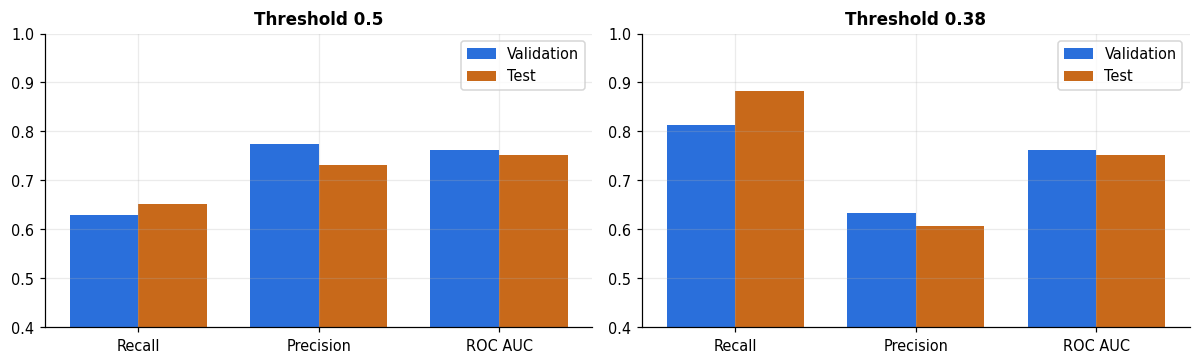

In [57]:
rf_te = p_rf(Xte)
tt = pd.DataFrame({'Validation, 0.5': ev(yva, rf_va, .5), 'Test, 0.5': ev(yte, rf_te, .5),
                   f'Validation, {CHOSEN}': ev(yva, rf_va, CHOSEN), f'Test, {CHOSEN}': ev(yte, rf_te, CHOSEN)}).drop(index='f1').round(4)
tt.loc['F1'] = [f1_score(yva, rf_va >= .5), f1_score(yte, rf_te >= .5), f1_score(yva, rf_va >= CHOSEN), f1_score(yte, rf_te >= CHOSEN)]
tt = tt.loc[['recall', 'precision', 'F1', 'roc_auc', 'pr_auc']]; display(tt.round(4))
fin = json.load(open(DATA / 'final_test_results.json'))
assert abs(recall_score(yte, rf_te >= CHOSEN) - fin['test_recall']) < 1e-9 and abs(roc_auc_score(yte, rf_te) - fin['test_roc_auc']) < 1e-6
print('Matches final_test_results.json')
print(f'Share of orders flagged at {CHOSEN}: validation {(rf_va >= CHOSEN).mean() * 100:.0f}%, test {(rf_te >= CHOSEN).mean() * 100:.0f}%.  Average score: validation {rf_va.mean():.3f}, test {rf_te.mean():.3f}')

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4)); x = np.arange(3); w = .38
for ax, thr in zip(axs, [.5, CHOSEN]):
    ax.bar(x - w / 2, [recall_score(yva, rf_va >= thr), precision_score(yva, rf_va >= thr), roc_auc_score(yva, rf_va)], w, color=BLUE, label='Validation')
    ax.bar(x + w / 2, [recall_score(yte, rf_te >= thr), precision_score(yte, rf_te >= thr), roc_auc_score(yte, rf_te)], w, color=ORANGE, label='Test')
    ax.set_xticks(x); ax.set_xticklabels(['Recall', 'Precision', 'ROC AUC']); ax.set_ylim(.4, 1); ax.legend(); ax.set_title(f'Threshold {thr}')
plt.tight_layout(); plt.show()

**What we found.** The model generalizes reasonably well, with a small drop in ranking quality, but the chosen threshold does not carry over exactly. The test set has 11,836 orders, 55.1 percent of them late (validation 54.2 percent).

| Metric | Validation, 0.5 | Test, 0.5 | Validation, 0.38 | Test, 0.38 |
|---|---|---|---|---|
| Recall | 0.629 | 0.652 | 0.814 | **0.882** |
| Precision | 0.775 | 0.731 | 0.633 | **0.606** |
| ROC AUC | 0.762 | 0.752 | 0.762 | 0.752 |
| PR AUC | 0.827 | 0.823 | 0.827 | 0.823 |

* **Ranking quality held up, with a small drop.** ROC AUC fell about 0.01 (0.762 to 0.752) and PR AUC about 0.004. These two do not depend on the threshold, so they are the fairest validation to test comparison. A drop this small suggests the selection effect of tuning on validation was minor.
* **Precision fell at both thresholds** (0.775 to 0.731 at 0.5 and 0.633 to 0.606 at 0.38), in line with the slightly weaker ranking.
* **The higher test Recall at 0.38 (0.882 against 0.814) is not an improvement in the model.** The average score is almost the same (0.550 on validation, 0.553 on test), but more test orders landed just above the 0.38 line, so more of them crossed it: **about 80 percent of test orders are flagged, against 70 percent on validation.** More orders flagged means more late orders caught but also more false alarms. Treat 0.88 as the result of flagging more orders, not as proof that the model got better on new data. We did not investigate why the scores moved up on the newest orders. The small change in late rate (55.1 against 54.2 percent) is not enough to explain it.
* **Takeaway:** a fixed threshold chosen on validation does not give the same workload on later data. In real use, re check how many orders the line flags as new data arrives.

### 5.8.3 Full evaluation at the chosen threshold

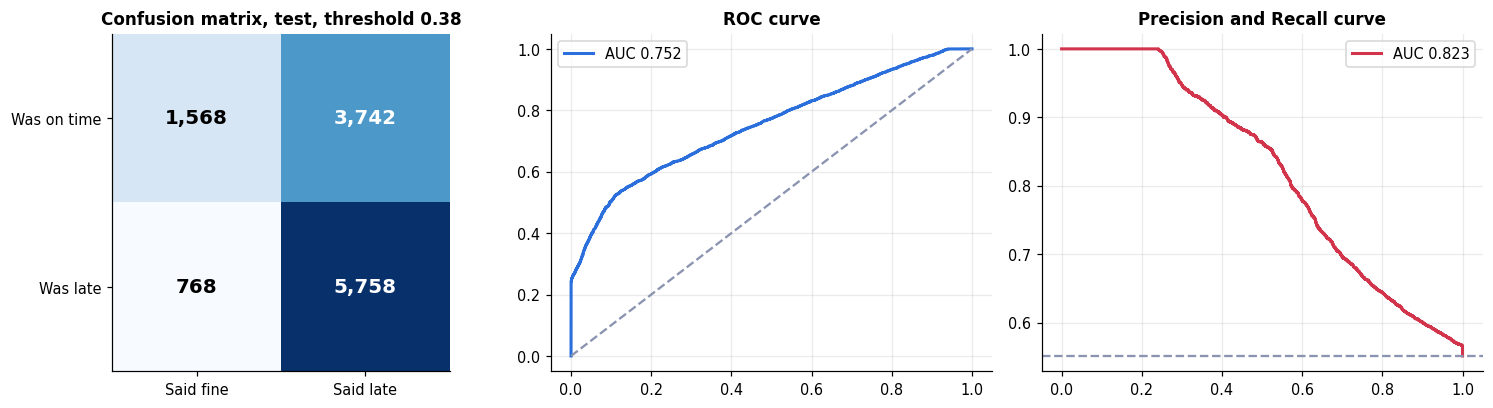

              precision    recall  f1-score   support

 On time (0)       0.67      0.30      0.41      5310
    Late (1)       0.61      0.88      0.72      6526

    accuracy                           0.62     11836
   macro avg       0.64      0.59      0.56     11836
weighted avg       0.64      0.62      0.58     11836

Top K view on the test set (for the prioritization lens):


,team can act on,share that are truly late,share of all late orders caught
0,top 5% (591 orders),1.000,0.091
1,"top 10% (1,183 orders)",1.000,0.181
2,"top 20% (2,367 orders)",0.931,0.338
3,"top 30% (3,550 orders)",0.875,0.476


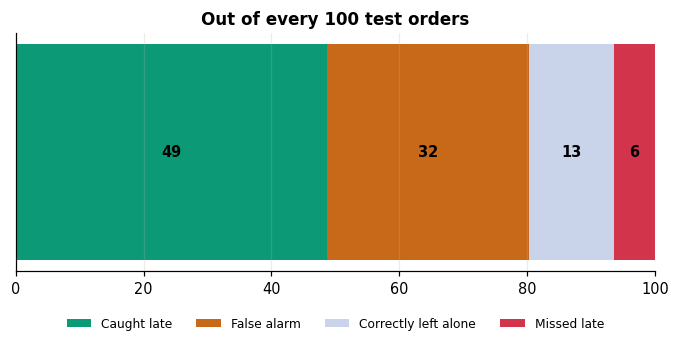

In [58]:
pred = (rf_te >= CHOSEN).astype(int); cm = confusion_matrix(yte, pred); tn, fp, fn, tp = cm.ravel()
fig, axs = plt.subplots(1, 3, figsize=(14, 3.8))
axs[0].imshow(cm, cmap='Blues'); axs[0].grid(False)
for (i, j), v in np.ndenumerate(cm): axs[0].text(j, i, f'{v:,}', ha='center', va='center', fontsize=13, fontweight='bold', color='white' if v > cm.max() / 2 else 'black')
axs[0].set_xticks([0, 1]); axs[0].set_xticklabels(['Said fine', 'Said late']); axs[0].set_yticks([0, 1]); axs[0].set_yticklabels(['Was on time', 'Was late']); axs[0].set_title('Confusion matrix, test, threshold 0.38')
fpr, tpr, _ = roc_curve(yte, rf_te); axs[1].plot(fpr, tpr, color=BLUE, lw=2, label=f'AUC {roc_auc_score(yte, rf_te):.3f}'); axs[1].plot([0, 1], [0, 1], '--', color=GREY); axs[1].legend(); axs[1].set_title('ROC curve')
pr, rc, _ = precision_recall_curve(yte, rf_te); axs[2].plot(rc, pr, color=RED, lw=2, label=f'AUC {average_precision_score(yte, rf_te):.3f}'); axs[2].axhline(yte.mean(), color=GREY, ls='--'); axs[2].legend(); axs[2].set_title('Precision and Recall curve')
plt.tight_layout(); plt.show()
print(classification_report(yte, pred, target_names=['On time (0)', 'Late (1)']))
print('Top K view on the test set (for the prioritization lens):'); display(top_k(yte, rf_te).round(3))

# Business picture: every 100 orders
per = np.array([tp, fp, tn, fn]) / len(yte) * 100
fig, ax = plt.subplots(figsize=(7.5, 2.8)); lab = ['Caught late', 'False alarm', 'Correctly left alone', 'Missed late']; cols = [GREEN, ORANGE, '#c9d3ea', RED]; left = 0
for v, l, c in zip(per, lab, cols): ax.barh(0, v, left=left, color=c); ax.text(left + v / 2, 0, f'{v:.0f}', ha='center', va='center', fontweight='bold'); left += v
ax.set_xlim(0, 100); ax.set_yticks([]); ax.legend(lab, ncol=4, loc='upper center', bbox_to_anchor=(.5, -.15), frameon=False, fontsize=8); ax.set_title('Out of every 100 test orders')
plt.show()

**What we found.** At the chosen threshold of 0.38, the final model catches **5,758 of the 6,526 late orders on the test set (88.2 percent Recall)** and misses 768. To do that it flags **9,500 of 11,836 orders (80 percent)**, and 3,742 of those alerts are false alarms (Precision 60.6 percent).

In business terms, for every 100 orders: about 80 are flagged, about 49 of those are truly late, about 32 are false alarms, about 13 are correctly left alone, and about 6 late orders are missed.

**The honest reading: this is a high Recall, low selectivity setup.** Only 1,568 of the 5,310 on time orders (30 percent) are correctly cleared, so the team would still look at most orders. Flagging every order gives Recall 100 percent and Precision 55.1 percent. So the model's Precision of 60.6 percent is only 5.5 points above flagging everything, in exchange for 12 points of Recall. The model adds real value over a blanket "check everything" rule, but a modest amount at this line, and about 6 percent of late orders still go unnoticed.

**The top of the ranking is where the model is strongest.** On the test set the 10 percent of orders with the highest scores (1,183 orders) are all late, and the top 20 percent are 93 percent late. For the second lens, a ranked list of the highest risk, highest value orders is far more selective and useful than the yes or no flag.

**Recommendation for the final report:** present both uses. The threshold gives a broad "watch list" with high Recall. The ranked top of the list gives a short, high confidence action queue.

## 5.9 The live app model: tuned XGBoost

For the web app we use the tuned XGBoost instead of the Random Forest. Both tuned models are tied at the operating point (section 5.5), and XGBoost is much smaller (0.88 MB against about 21 MB), explains in about one second, and can run inside a browser. We choose its threshold the same way: the highest threshold with validation Recall of at least 0.80.

,Threshold,Recall,Precision,F1,ROC AUC,PR AUC,Share flagged
Random Forest (report model),0.38,0.882,0.606,0.719,0.752,0.823,0.803
XGBoost (live app model),0.39,0.855,0.631,0.726,0.772,0.837,0.747


XGBoost threshold 0.39: validation Recall 0.809, Precision 0.636, flagged 69.0%. It matches the app config.


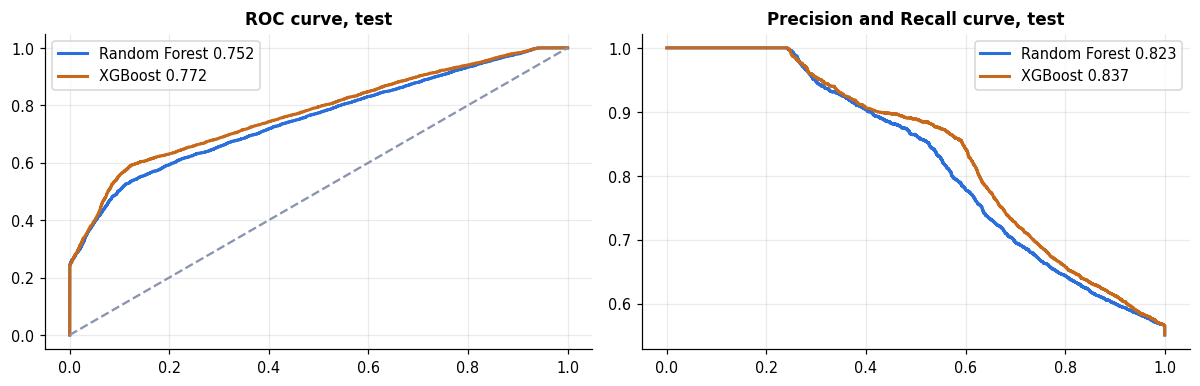

In [59]:
Rx = sweep(yva, xgb_va); okx = Rx[Rx.recall >= .80]; chx = okx.loc[okx.threshold.idxmax()]
THR_XGB, THR_RF = float(chx.threshold), CHOSEN
cfg = json.load(open(ART / 'config.json')); assert abs(THR_XGB - cfg['risk_threshold']) < 1e-9
xgb_te = p_xgb(Xte)
final = pd.DataFrame({
    'Random Forest (report model)': {'Threshold': THR_RF, **{k: v for k, v in ev(yte, rf_te, THR_RF).items()}, 'Share flagged': (rf_te >= THR_RF).mean()},
    'XGBoost (live app model)': {'Threshold': THR_XGB, **{k: v for k, v in ev(yte, xgb_te, THR_XGB).items()}, 'Share flagged': (xgb_te >= THR_XGB).mean()}}).T
final.columns = ['Threshold', 'Recall', 'Precision', 'F1', 'ROC AUC', 'PR AUC', 'Share flagged']
display(final.round(3))
print(f'XGBoost threshold {THR_XGB}: validation Recall {chx.recall:.3f}, Precision {chx.precision:.3f}, flagged {chx.flagged * 100:.1f}%. It matches the app config.')
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
for k, s, col in [('Random Forest', rf_te, BLUE), ('XGBoost', xgb_te, ORANGE)]:
    fpr, tpr, _ = roc_curve(yte, s); axs[0].plot(fpr, tpr, color=col, lw=2, label=f'{k} {roc_auc_score(yte, s):.3f}')
    pr, rc, _ = precision_recall_curve(yte, s); axs[1].plot(rc, pr, color=col, lw=2, label=f'{k} {average_precision_score(yte, s):.3f}')
axs[0].plot([0, 1], [0, 1], '--', color=GREY); axs[0].legend(); axs[0].set_title('ROC curve, test'); axs[1].legend(); axs[1].set_title('Precision and Recall curve, test')
plt.tight_layout(); plt.show()

**What we found:** on the test set XGBoost reaches Recall 0.855 and Precision 0.631 (flagging about 75 percent of orders) with a better ranking than the forest (ROC AUC 0.772 against 0.752, PR AUC 0.837 against 0.823). The forest has the higher Recall (0.882) but only because it flags more orders (80 percent). Both models tell the same story: a broad watch list with high Recall and modest Precision, and a very clean top of the ranking.

# Part 6. Shipment prioritization (the second lens)

**The question this part answers:** we cannot chase every order. Which ones should the team work on first?

**The idea in one minute.** Part 5 gave every order a chance of being late (a number from 0 to 1). A late order worth a lot of money hurts more than a late order worth little. So we multiply the two:

**priority = chance of being late × Sales**

Example: a 900 dollar order with a 60 percent chance of being late has priority 540. A 40 dollar order that is 99 percent sure to be late has priority 40. The first goes first.

**What you will see**

1. The data and the model we use (the tuned Random Forest, as in the report).
2. A check that the chances can be trusted.
3. A fair contest: Heads Up against simpler ways of ordering the work.
4. A simple rule that turns out to be a strong rival.
5. A dial that trades money against accuracy.
6. Three action tiers for the app.

**Two numbers judge a work queue.** Say we only have time to review the top 10 percent of orders.

* **Revenue reached:** of all the money in orders that really were late, how much sits inside our top 10 percent?
* **Precision:** of the orders we reviewed, how many were really late?

## 6.1 Data and model

We reuse the validation and test scores of the tuned Random Forest from Part 5. The order tables hold the real **Sales** amounts in currency (not the scaled numbers used for modelling).

In [60]:
THRESHOLD = CHOSEN
raw_tr, raw_va, raw_te = train, val, test
p_va, p_te = rf_va, rf_te
y_va, y_te = yva, yte
print(f'Risk threshold from Part 5: {THRESHOLD}')
print(f'validation: {len(y_va):,} orders, {y_va.mean() * 100:.1f}% late, ROC AUC {roc_auc_score(y_va, p_va):.3f}')
print(f'test:       {len(y_te):,} orders, {y_te.mean() * 100:.1f}% late, ROC AUC {roc_auc_score(y_te, p_te):.3f}')

Risk threshold from Part 5: 0.38
validation: 7,890 orders, 54.2% late, ROC AUC 0.762
test:       11,836 orders, 55.1% late, ROC AUC 0.752


### What does lateness depend on?

One picture explains most of this part. Shipping mode alone separates late from on time orders very well. Same Day orders placed before noon are never late. Same Day orders placed at noon or later are almost always late.

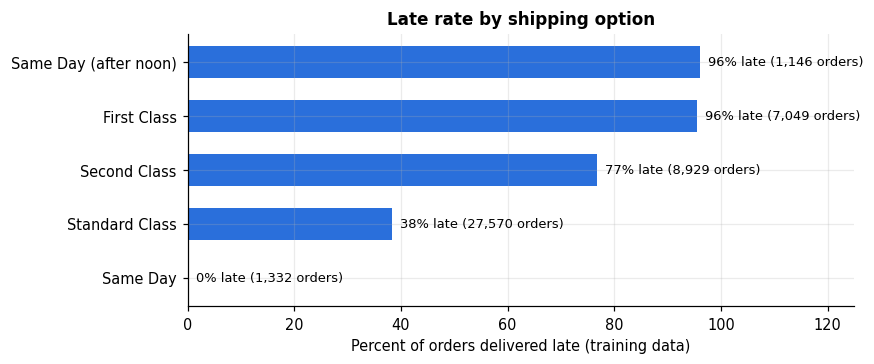

In [61]:
def hour_of(df): return df['order date (DateOrders)'].dt.hour
def rule_key(df):
    pm = (df['Shipping Mode'] == 'Same Day') & (hour_of(df) >= 12)
    return df['Shipping Mode'].astype(str) + np.where(pm, ' (after noon)', '')
g = raw_tr.assign(rk=rule_key(raw_tr)).groupby('rk')['Late_delivery_risk'].agg(['mean', 'size']).sort_values('mean')
rate_mode = raw_tr.groupby('Shipping Mode')['Late_delivery_risk'].mean(); rate_key = g['mean']
fig, ax = plt.subplots(figsize=(8, 3.4)); bars = ax.barh(g.index, g['mean'] * 100, color=BLUE, height=.6)
for b, (m, n) in zip(bars, zip(g['mean'], g['size'])): ax.text(b.get_width() + 1.5, b.get_y() + b.get_height() / 2, f'{m:.0%} late ({n:,} orders)', va='center', fontsize=8.5)
ax.set_xlim(0, 125); ax.set_xlabel('Percent of orders delivered late (training data)'); ax.set_title('Late rate by shipping option'); plt.tight_layout(); plt.show()

### Order value changes over time

The data is split by date: train is oldest, test is newest. The picture shows that orders in the test period are **smaller**. We come back to this at the end.

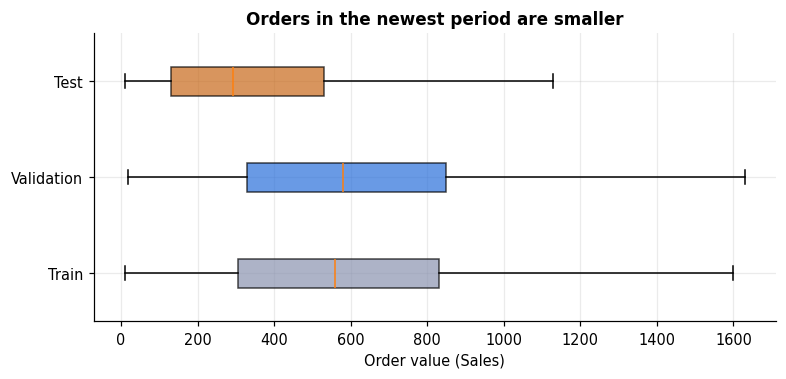

{'Train': 591, 'Validation': 612, 'Test': 401} (average order value)


In [62]:
fig, ax = plt.subplots(figsize=(8, 3.4))
parts6 = [(raw_tr, 'Train', GREY), (raw_va, 'Validation', BLUE), (raw_te, 'Test', ORANGE)]
bp = ax.boxplot([d.Sales for d, _, _ in parts6], labels=[n for _, n, _ in parts6], vert=False, patch_artist=True, showfliers=False)
for patch, (_, _, c) in zip(bp['boxes'], parts6): patch.set_facecolor(c); patch.set_alpha(.7)
ax.set_xlabel('Order value (Sales)'); ax.set_title('Orders in the newest period are smaller'); plt.show()
print({n: round(d.Sales.mean()) for d, n, _ in parts6}, '(average order value)')

## 6.2 The priority score, shown with a small example

Three made up orders. Look at which one wins on priority, and which would win if we looked only at risk or only at money.

,Order,Chance late,Sales,Priority
0,A: big and likely late,0.60,900,540.0
1,B: small but almost sure,0.99,40,39.6
2,C: big but unlikely,0.15,1000,150.0


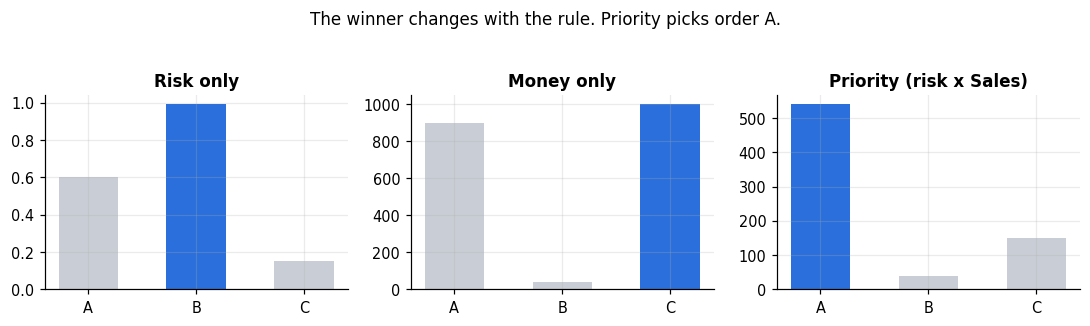

In [63]:
exm = pd.DataFrame({'Order': ['A: big and likely late', 'B: small but almost sure', 'C: big but unlikely'], 'Chance late': [.60, .99, .15], 'Sales': [900, 40, 1000]})
exm['Priority'] = exm['Chance late'] * exm['Sales']; display(exm)
fig, axs = plt.subplots(1, 3, figsize=(10, 2.8))
for ax, col, t in zip(axs, ['Chance late', 'Sales', 'Priority'], ['Risk only', 'Money only', 'Priority (risk x Sales)']):
    v = exm[col].values; b = v.argmax(); ax.bar(['A', 'B', 'C'], v, color=[BLUE if i == b else '#c9ced6' for i in range(3)], width=.55); ax.set_title(t)
fig.suptitle('The winner changes with the rule. Priority picks order A.', y=1.04, fontsize=11); plt.tight_layout(); plt.show()

## 6.3 Can we trust the chances?

Before multiplying a chance by money, the chance must be honest. If the model says 80 percent, about 80 of 100 such orders should really be late. In the left picture, dots near the dashed line mean the model is honest.

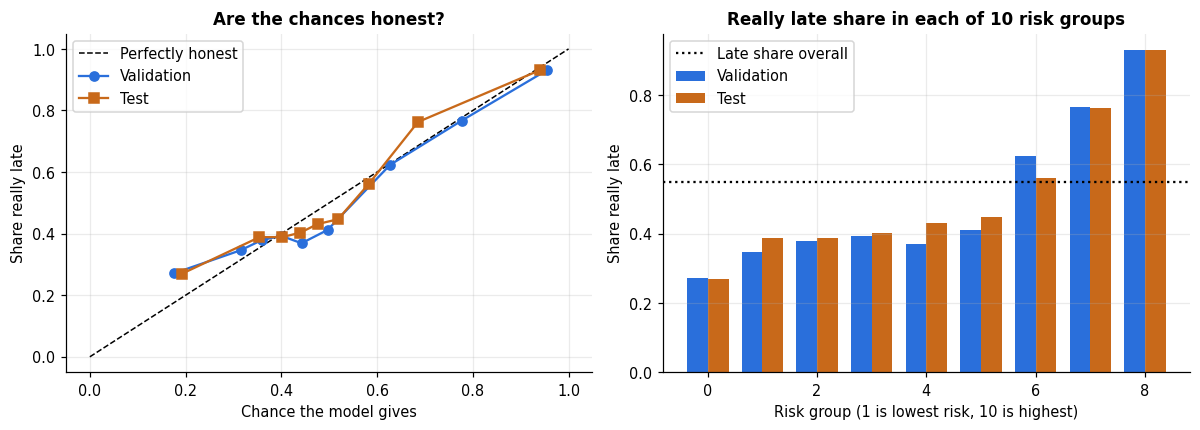

,"(-0.001, 0.285]","(0.285, 0.339]","(0.339, 0.379]","(0.379, 0.421]","(0.421, 0.464]","(0.464, 0.537]","(0.537, 0.718]","(0.718, 0.828]","(0.828, 1.0]"
predicted,0.176,0.315,0.359,0.400,0.442,0.496,0.627,0.776,0.955
actual,0.271,0.346,0.379,0.393,0.369,0.412,0.624,0.767,0.932
n,789.000,789.000,789.000,789.000,789.000,789.000,789.000,789.000,1578.000


In [64]:
def calib(p, y):
    q = pd.qcut(p, 10, duplicates='drop')
    return pd.DataFrame({'p': p, 'y': y}).groupby(q, observed=True).agg(predicted=('p', 'mean'), actual=('y', 'mean'), n=('y', 'size'))
g_va, g_te = calib(p_va, y_va), calib(p_te, y_te); base = ytr.mean()
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].plot([0, 1], [0, 1], '--', color='black', lw=1, label='Perfectly honest')
axs[0].plot(g_va.predicted, g_va.actual, 'o-', color=BLUE, label='Validation'); axs[0].plot(g_te.predicted, g_te.actual, 's-', color=ORANGE, label='Test')
axs[0].set_xlabel('Chance the model gives'); axs[0].set_ylabel('Share really late'); axs[0].legend(); axs[0].set_title('Are the chances honest?')
w = .38; x = np.arange(len(g_va)); axs[1].bar(x - w / 2, g_va.actual, w, color=BLUE, label='Validation'); axs[1].bar(x + w / 2, g_te.actual, w, color=ORANGE, label='Test')
axs[1].axhline(base, color='black', ls=':', label='Late share overall'); axs[1].set_xlabel('Risk group (1 is lowest risk, 10 is highest)'); axs[1].set_ylabel('Share really late'); axs[1].legend(); axs[1].set_title('Really late share in each of 10 risk groups')
plt.tight_layout(); plt.show()
display(g_va.round(3).T)

**What we found:** dots are close to the dashed line, so the chances are honest. The one weak spot is the lowest risk group: the model says about 18 percent but about 27 percent were really late. Across the ten groups the really late share climbs steadily, so the ranking is sound.

## 6.4 The contest

We test Heads Up against simpler ways of ordering the work. Every method gets the same effort, for example the top 10 percent of orders.

* **Random order:** pick by luck.
* **Sales only:** biggest orders first.
* **Risk only:** most likely late first.
* **Simple rule:** look up the late rate of the shipping option (and split Same Day at noon). No machine learning.
* **Oracle:** a perfect helper that already knows which orders are late. Nobody can do better, so it is the ceiling.

In [65]:
KS = (.05, .10, .20, .30)
def make_scores(df, p, y):
    S = df['Sales'].values; rng = np.random.default_rng(SEED)
    return {'Random order': rng.random(len(y)), 'Sales only': S, 'Simple rule (mode)': df['Shipping Mode'].map(rate_mode).values * S,
            'Simple rule (mode and noon)': rule_key(df).map(rate_key).values * S, 'Risk only': p + 1e-12 * S,
            'Heads Up (risk x Sales)': p * S, 'Oracle (perfect)': y * S + 1e-9 * S}
ORDER = list(make_scores(raw_va, p_va, y_va).keys())

def value_precision(sc, S, y, k):
    n = int(len(y) * k); idx = np.argsort(-sc, kind='stable')[:n]
    return (S * y)[idx].sum() / (S * y).sum(), y[idx].mean()

def evaluate(df, p, y):
    S = df['Sales'].values; rows = []
    for sn, sc in make_scores(df, p, y).items():
        for k in KS:
            v, pr = value_precision(sc, S, y, k); rows.append(dict(scheme=sn, K=f'{k:.0%}', revenue_reached=v, precision=pr))
    return pd.DataFrame(rows)
ev_va, ev_te = evaluate(raw_va, p_va, y_va), evaluate(raw_te, p_te, y_te)
def showt(ev_, col): return ev_.pivot(index='scheme', columns='K', values=col).loc[ORDER][[f'{k:.0%}' for k in KS]]
print('VALIDATION, revenue reached (higher is better)'); display(showt(ev_va, 'revenue_reached').round(3))
print('VALIDATION, precision'); display(showt(ev_va, 'precision').round(3))

VALIDATION, revenue reached (higher is better)


K,5%,10%,20%,30%
scheme,,,,
Random order,0.054,0.106,0.201,0.301
Sales only,0.109,0.203,0.364,0.508
Simple rule (mode),0.152,0.266,0.433,0.566
Simple rule (mode and noon),0.155,0.273,0.447,0.583
Risk only,0.146,0.220,0.343,0.482
Heads Up (risk x Sales),0.158,0.272,0.444,0.574
Oracle (perfect),0.193,0.347,0.596,0.783


VALIDATION, precision


K,5%,10%,20%,30%
scheme,,,,
Random order,0.579,0.561,0.541,0.545
Sales only,0.523,0.530,0.529,0.538
Simple rule (mode),0.873,0.849,0.773,0.700
Simple rule (mode and noon),0.878,0.866,0.807,0.732
Risk only,1.000,1.000,0.932,0.877
Heads Up (risk x Sales),0.911,0.863,0.786,0.725
Oracle (perfect),1.000,1.000,1.000,1.000


### How much late revenue do we reach as we review more orders?

Each line is a method. The higher the line, the more at risk money is reached for the same effort. The dashed black line is the oracle ceiling.

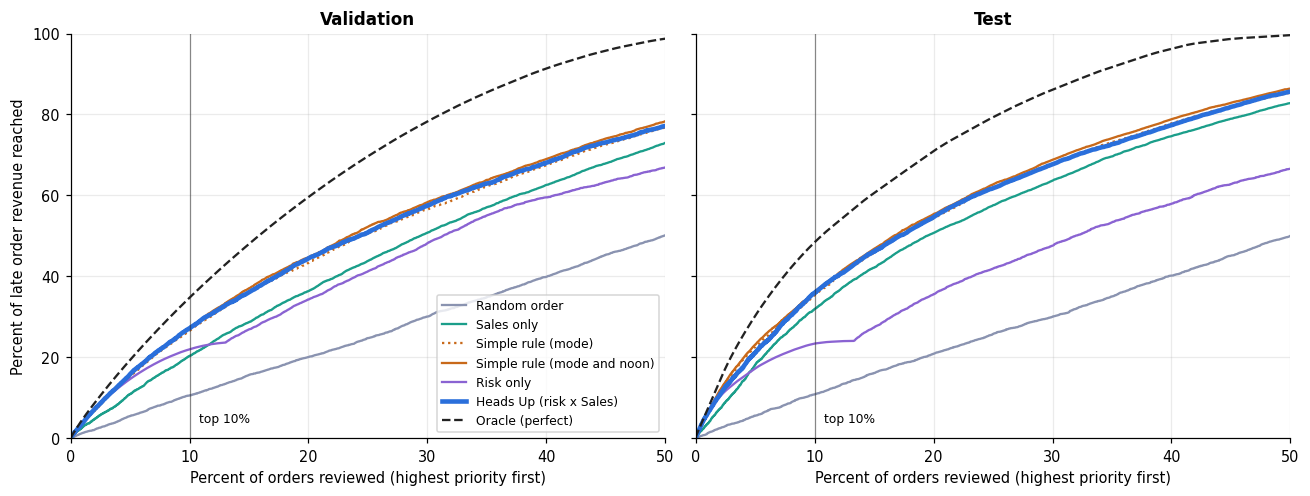

In [66]:
def gain_curve(sc, S, y):
    idx = np.argsort(-sc, kind='stable'); cum = np.cumsum((S * y)[idx]) / (S * y).sum()
    return np.arange(1, len(y) + 1) / len(y) * 100, cum * 100
COL = {'Random order': GREY, 'Sales only': TEAL, 'Simple rule (mode)': ORANGE, 'Simple rule (mode and noon)': ORANGE, 'Risk only': PURPLE, 'Heads Up (risk x Sales)': BLUE, 'Oracle (perfect)': '#222222'}
fig, axs = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, (nm, df, p, y) in zip(axs, (('Validation', raw_va, p_va, y_va), ('Test', raw_te, p_te, y_te))):
    S = df['Sales'].values
    for sn, sc in make_scores(df, p, y).items():
        x_, c_ = gain_curve(sc, S, y); ls = '--' if 'Oracle' in sn else (':' if sn == 'Simple rule (mode)' else '-')
        ax.plot(x_, c_, ls, color=COL[sn], lw=3 if 'Heads Up' in sn else 1.5, label=sn)
    ax.axvline(10, color='#222', lw=.8, alpha=.5); ax.text(10.8, 4, 'top 10%', fontsize=8); ax.set_xlim(0, 50); ax.set_ylim(0, 100); ax.set_xlabel('Percent of orders reviewed (highest priority first)'); ax.set_title(nm)
axs[0].set_ylabel('Percent of late order revenue reached'); axs[0].legend(fontsize=8, loc='lower right'); plt.tight_layout(); plt.show()

### The top 10 percent side by side

Left: money reached. Right: how many reviewed orders were really late.

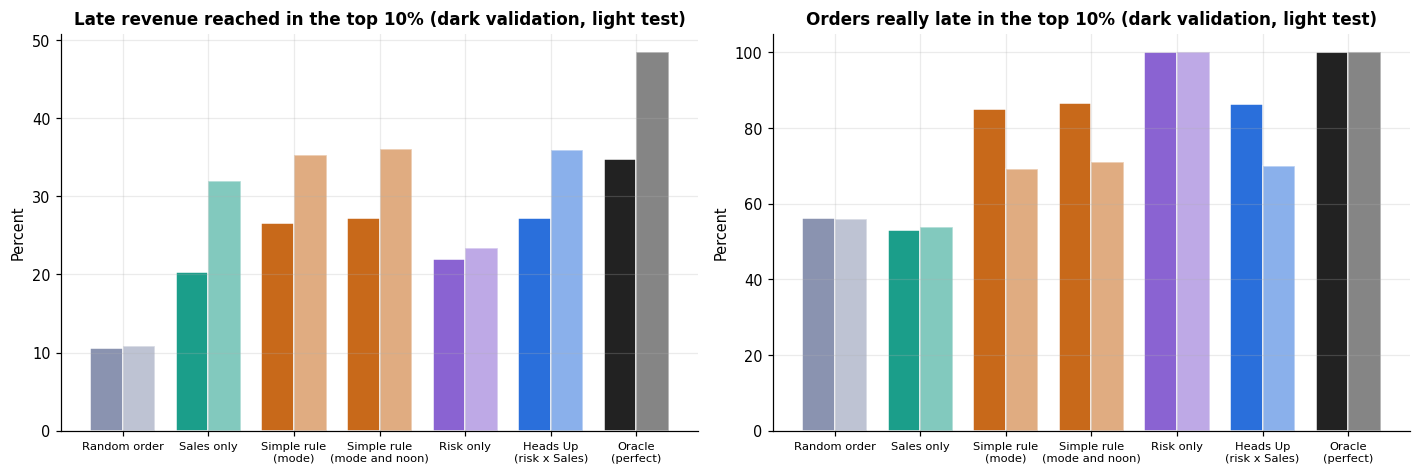

TEST, revenue reached


K,5%,10%,20%,30%
scheme,,,,
Random order,0.056,0.108,0.208,0.300
Sales only,0.180,0.319,0.507,0.636
Simple rule (mode),0.225,0.353,0.543,0.678
Simple rule (mode and noon),0.231,0.360,0.554,0.688
Risk only,0.172,0.234,0.355,0.476
Heads Up (risk x Sales),0.211,0.359,0.546,0.677
Oracle (perfect),0.302,0.484,0.709,0.861


TEST, precision


K,5%,10%,20%,30%
scheme,,,,
Random order,0.569,0.560,0.553,0.548
Sales only,0.526,0.539,0.542,0.548
Simple rule (mode),0.849,0.691,0.680,0.668
Simple rule (mode and noon),0.865,0.710,0.703,0.683
Risk only,1.000,1.000,0.931,0.875
Heads Up (risk x Sales),0.751,0.700,0.694,0.668
Oracle (perfect),1.000,1.000,1.000,1.000


At the top 10% on validation, Heads Up reaches 78% of what a perfect oracle could reach.


In [67]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.4)); w = .38; xs = np.arange(len(ORDER))
for ax, col, title in zip(axs, ['revenue_reached', 'precision'], ['Late revenue reached in the top 10%', 'Orders really late in the top 10%']):
    for j, (nm, ev_, off, al) in enumerate((('Validation', ev_va, -w / 2, 1.0), ('Test', ev_te, w / 2, .55))):
        v = ev_[ev_.K == '10%'].set_index('scheme').loc[ORDER, col] * 100
        ax.bar(xs + off, v.values, w, color=[COL[s] for s in ORDER], alpha=al, edgecolor='white')
    ax.set_xticks(xs); ax.set_xticklabels([s.replace(' (', '\n(') for s in ORDER], fontsize=7.5); ax.set_title(title + ' (dark validation, light test)'); ax.set_ylabel('Percent')
plt.tight_layout(); plt.show()
print('TEST, revenue reached'); display(showt(ev_te, 'revenue_reached').round(3))
print('TEST, precision'); display(showt(ev_te, 'precision').round(3))
orc = ev_va[(ev_va.K == '10%') & (ev_va.scheme == 'Oracle (perfect)')].revenue_reached.iloc[0]; hu = ev_va[(ev_va.K == '10%') & (ev_va.scheme == 'Heads Up (risk x Sales)')].revenue_reached.iloc[0]
print(f'At the top 10% on validation, Heads Up reaches {hu / orc * 100:.0f}% of what a perfect oracle could reach.')

### Where does the top 10 percent queue come from?

Each dot is a validation order. "Risk only" picks the right edge, "Sales only" picks the top edge. Heads Up picks the upper right corner, where both are high.

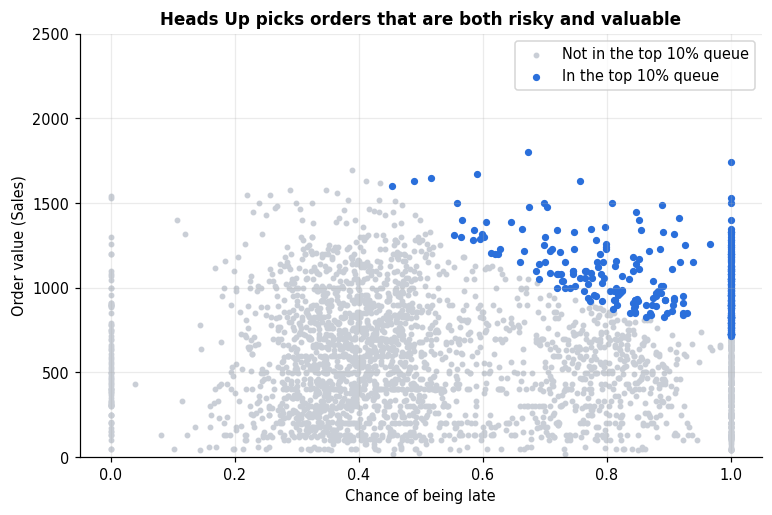

In [68]:
rs = np.random.default_rng(1).choice(len(y_va), 3000, replace=False); S_va = raw_va.Sales.values; pr_va = p_va * S_va
q_crit_check = np.quantile(pr_va, .90); inq = pr_va >= q_crit_check
fig, ax = plt.subplots(figsize=(8, 5)); ax.scatter(p_va[rs][~inq[rs]], S_va[rs][~inq[rs]], s=8, color='#c9ced6', label='Not in the top 10% queue')
ax.scatter(p_va[rs][inq[rs]], S_va[rs][inq[rs]], s=14, color=BLUE, label='In the top 10% queue')
ax.set_xlabel('Chance of being late'); ax.set_ylabel('Order value (Sales)'); ax.set_ylim(0, 2500); ax.legend(); ax.set_title('Heads Up picks orders that are both risky and valuable'); plt.show()

**What we found**

* The curves of the three smart methods rise much faster than random order. **Risk only** fills the queue with cheap orders (it is very clean, almost always late, but reaches less money). **Sales only** picks big orders that are often not late. Together, risk times Sales reaches the most money.
* On validation, the top 10 percent reaches about 27 percent of all late revenue, against about 35 percent for the perfect oracle. So **Heads Up reaches about three quarters (78 percent) of the best possible result.**
* On the test data the numbers look different (the top 10 percent reaches about 36 percent against an oracle of about 48 percent), because test orders are on average smaller and more of the late revenue sits in big orders.

## 6.5 Is the model better than a simple rule?

This is the fair question. A simple rule says: "First Class is almost always late, Standard Class is often fine, Same Day after noon is late." It takes two minutes to build. The picture compares model and rule in the top 10 percent queue.

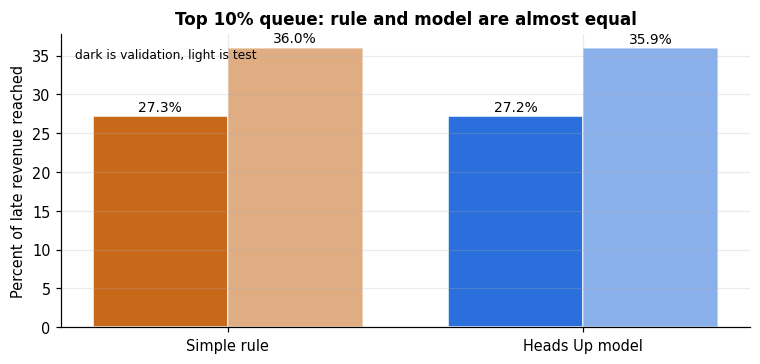

In [69]:
names = ['Simple rule (mode and noon)', 'Heads Up (risk x Sales)']
fig, ax = plt.subplots(figsize=(7, 3.4))
for j, (nm, ev_, al) in enumerate((('Validation', ev_va, 1.0), ('Test', ev_te, .55))):
    v = ev_[ev_.K == '10%'].set_index('scheme').loc[names, 'revenue_reached'] * 100
    ax.bar(np.arange(2) + (j - .5) * .38, v.values, .38, color=[COL[n] for n in names], alpha=al, edgecolor='white')
    for x_, val_ in zip(np.arange(2) + (j - .5) * .38, v.values): ax.text(x_, val_ + .6, f'{val_:.1f}%', ha='center', fontsize=9)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Simple rule', 'Heads Up model']); ax.set_ylabel('Percent of late revenue reached'); ax.set_title('Top 10% queue: rule and model are almost equal'); ax.text(.02, .95, 'dark is validation, light is test', transform=ax.transAxes, fontsize=8, va='top')
plt.tight_layout(); plt.show()

**Could this tiny gap be luck?** We repeat the comparison 300 times on random re drawn samples of the orders. Each repeat gives one gap. The black line is zero, which means a tie. If the bars sit on both sides of zero, there is no clear winner.

Validation: average gap -0.10 points, middle 90 percent from -0.54 to 0.30


Test: average gap -0.19 points, middle 90 percent from -0.69 to 0.33


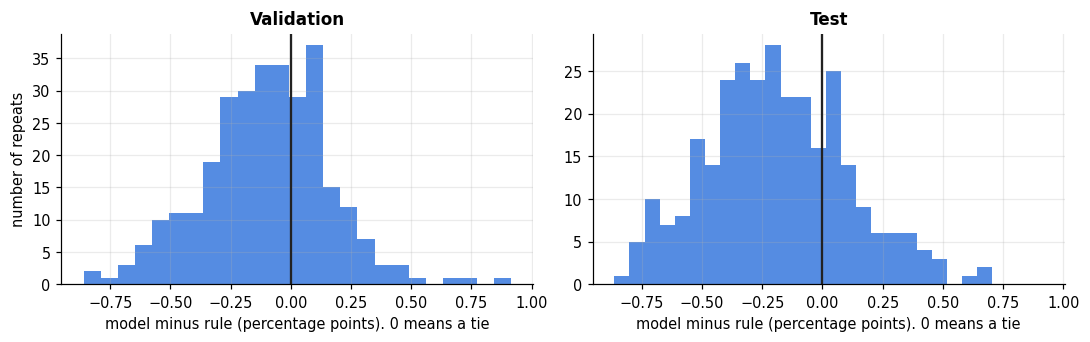

In [70]:
def boot_diff(df, p, y, k=.10, n_boot=300):
    S = df['Sales'].values; model = p * S; r2 = rule_key(df).map(rate_key).values * S; rng = np.random.default_rng(0); d = []
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y)); d.append(value_precision(model[i], S[i], y[i], k)[0] - value_precision(r2[i], S[i], y[i], k)[0])
    return np.array(d)
fig, axs = plt.subplots(1, 2, figsize=(10, 3.2), sharex=True)
for ax, (nm, df, p, y) in zip(axs, (('Validation', raw_va, p_va, y_va), ('Test', raw_te, p_te, y_te))):
    d = boot_diff(df, p, y) * 100; ax.hist(d, bins=25, color=BLUE, alpha=.8); ax.axvline(0, color='#222', lw=1.5); ax.set_title(nm); ax.set_xlabel('model minus rule (percentage points). 0 means a tie')
    print(f'{nm}: average gap {d.mean():.2f} points, middle 90 percent from {np.percentile(d, 5):.2f} to {np.percentile(d, 95):.2f}')
axs[0].set_ylabel('number of repeats'); plt.tight_layout(); plt.show()

**What this means.** For ordering the top 10 percent, **the model and the simple rule tie.** We say this openly in the report. The model still adds value in two ways: it gives a separate chance for every order, and SHAP explains why each order is risky. A simple rule cannot do either.

## 6.6 A dial: how much should risk count compared with money?

So far the score is chance times Sales. We can give more weight to risk, or more weight to money, with an exponent called alpha: `priority = chance ^ alpha × Sales`. We try six settings.

* **Money first (alpha 0):** the biggest orders go first.
* **Balanced (alpha 1):** chance times Sales. This is our choice.
* **Risk first (large alpha):** the most likely late orders go first.

,data,alpha,meaning,revenue reached,precision
0,Validation,0.0,Money first,0.203,0.530
1,Validation,0.5,,0.257,0.750
2,Validation,1.0,Balanced,0.272,0.863
3,Validation,2.0,,0.269,0.919
4,Validation,3.0,,0.258,0.928
5,Validation,5.0,Risk first,0.248,0.959
6,Test,0.0,Money first,0.319,0.539
7,Test,0.5,,0.352,0.643
8,Test,1.0,Balanced,0.359,0.700
9,Test,2.0,,0.335,0.844


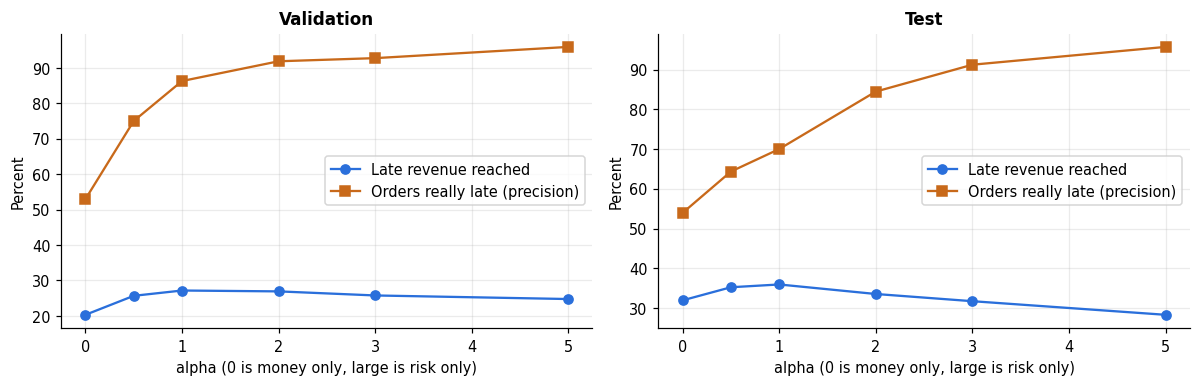

In [71]:
dial = {0: 'Money first', .5: '', 1: 'Balanced', 2: '', 3: '', 5: 'Risk first'}
rows = []
for nm, df, y, p in (('Validation', raw_va, y_va, p_va), ('Test', raw_te, y_te, p_te)):
    S = df['Sales'].values
    for a in dial:
        sc = (p ** a) * S if a > 0 else S; v, pr = value_precision(sc, S, y, .10); rows.append({'data': nm, 'alpha': a, 'meaning': dial[a], 'revenue reached': v, 'precision': pr})
dd = pd.DataFrame(rows); display(dd.round(3))
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for ax, nm in zip(axs, ['Validation', 'Test']):
    d = dd[dd.data == nm]; ax.plot(d.alpha, d['revenue reached'] * 100, 'o-', color=BLUE, label='Late revenue reached'); ax.plot(d.alpha, d['precision'] * 100, 's-', color=ORANGE, label='Orders really late (precision)')
    ax.set_title(nm); ax.set_xlabel('alpha (0 is money only, large is risk only)'); ax.set_ylabel('Percent'); ax.legend()
plt.tight_layout(); plt.show()

**What we found:** going to the right gives a **cleaner queue** (more orders really late) but reaches **less money**. Balanced (alpha 1) reaches the most money or very close to it. That is why we keep alpha at 1, with the dial available in the app.

## 6.7 Three action tiers

A long list of scores is hard to act on, so we sort orders into three groups.

* **Critical:** the top 10 percent by priority. Act today.
* **High:** the next 20 percent. Act this week.
* **Standard:** everything else. Normal handling.

We set the cut points on the **validation** data. Then we use the same cut points on the test data. A risk gate also applies: an order below the risk threshold cannot be High (only Critical can bypass it).

Cut points on validation: Critical at 707.6, High at 407.1   (saved: 707.6 and 407.1)
Validation


,Orders,Share really late,Average order value,Share of all orders,Share of late revenue
tier,,,,,
1 Critical,789,0.86,1054.56,0.10,0.27
2 High,1487,0.67,818.61,0.19,0.28
3 Standard,5614,0.46,494.93,0.71,0.44


Test


,Orders,Share really late,Average order value,Share of all orders,Share of late revenue
tier,,,,,
1 Critical,710,0.73,1282.42,0.06,0.24
2 High,1082,0.70,843.56,0.09,0.22
3 Standard,10044,0.52,291.54,0.85,0.54


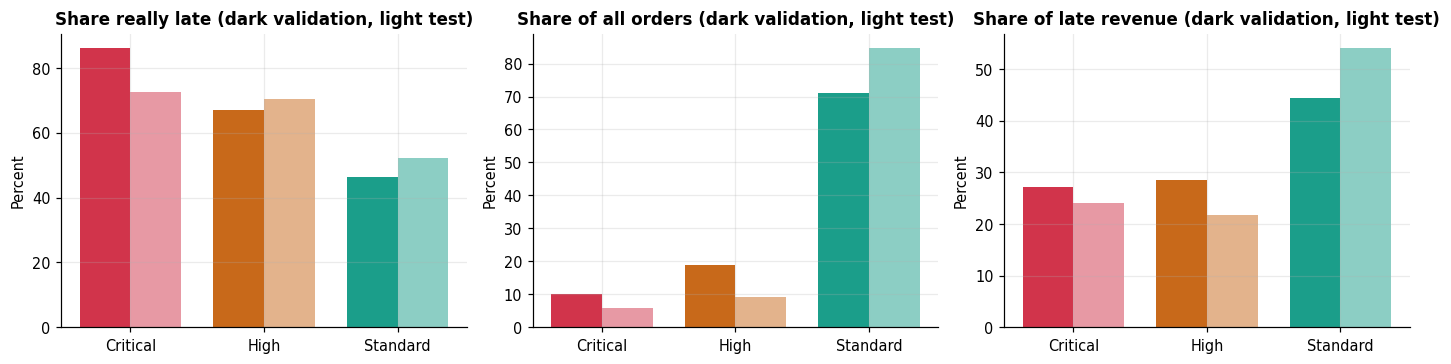

In [72]:
q_crit, q_high = np.quantile(pr_va, [.90, .70])
pcfg = json.load(open(DATA / 'priority_config.json'))
print(f'Cut points on validation: Critical at {q_crit:.1f}, High at {q_high:.1f}   (saved: {pcfg["tier_cutoffs_priority_score"]["critical_min"]:.1f} and {pcfg["tier_cutoffs_priority_score"]["high_min"]:.1f})')
assert abs(q_crit - pcfg['tier_cutoffs_priority_score']['critical_min']) < .01 and abs(q_high - pcfg['tier_cutoffs_priority_score']['high_min']) < .01

def tier(p, S):
    pr = p * S; t = np.where(pr >= q_crit, '1 Critical', np.where(pr >= q_high, '2 High', '3 Standard'))
    return np.where((p < THRESHOLD) & (t != '1 Critical'), '3 Standard', t)

def tier_table(df, p, y):
    t = tier(p, df['Sales'].values); S = df['Sales'].values
    d = pd.DataFrame({'tier': t, 'late': y, 'S': S}); late_rev = (S * y).sum()
    out = d.groupby('tier').agg(Orders=('late', 'size'), **{'Share really late': ('late', 'mean'), 'Average order value': ('S', 'mean')})
    out['Share of all orders'] = out['Orders'] / len(d); out['Share of late revenue'] = d.assign(r=d.S * d.late).groupby('tier')['r'].sum() / late_rev
    return out
tv, tt_ = tier_table(raw_va, p_va, y_va), tier_table(raw_te, p_te, y_te)
print('Validation'); display(tv.round(2)); print('Test'); display(tt_.round(2))
fig, axs = plt.subplots(1, 3, figsize=(13, 3.4)); tcol = [RED, ORANGE, TEAL]
for ax, col, title in zip(axs, ['Share really late', 'Share of all orders', 'Share of late revenue'], ['Share really late', 'Share of all orders', 'Share of late revenue']):
    x = np.arange(3); ax.bar(x - .19, tv[col] * 100, .38, color=tcol, alpha=1); ax.bar(x + .19, tt_[col] * 100, .38, color=tcol, alpha=.5)
    ax.set_xticks(x); ax.set_xticklabels(['Critical', 'High', 'Standard']); ax.set_title(title + ' (dark validation, light test)'); ax.set_ylabel('Percent')
plt.tight_layout(); plt.show()

**What we found:** the tiers behave as we want. In validation, **Critical orders were 86 percent late and held 27 percent of all late revenue with only 10 percent of the orders.** In the test period, Critical is 73 percent late, High 70 percent and Standard 52 percent, so the order of the tiers holds. The test Critical group is smaller than 10 percent of orders (about 6 percent) because test orders are smaller, so fewer cross the money based cut point.

### What the queue will look like in the app

The ten highest priority orders in the test set. The last column shows what really happened (the app will not know this at order time).

In [73]:
q = raw_te[['Order Id', 'Shipping Mode', 'Order Region', 'Sales']].copy()
q['Chance late'] = p_te.round(2); q['Priority'] = (p_te * raw_te.Sales.values).round(0); q['Tier'] = tier(p_te, raw_te.Sales.values)
q['Really late?'] = np.where(y_te == 1, 'yes', 'no'); q = q.sort_values('Priority', ascending=False).head(10).reset_index(drop=True); q['Sales'] = q['Sales'].round(0)
display(q)

,Order Id,Shipping Mode,Order Region,Sales,Chance late,Priority,Tier,Really late?
0,68736,First Class,Northern Europe,2260.0,1.00,2260.0,1 Critical,yes
1,68883,First Class,Western Europe,2150.0,1.00,2150.0,1 Critical,yes
2,68703,Standard Class,Northern Europe,3450.0,0.59,2045.0,1 Critical,no
3,68724,Standard Class,Western Europe,2860.0,0.66,1885.0,1 Critical,yes
4,68858,Standard Class,Southern Europe,2840.0,0.62,1772.0,1 Critical,no
5,68809,Standard Class,Southern Europe,2780.0,0.60,1655.0,1 Critical,yes
6,68345,Same Day,Northern Europe,1630.0,1.00,1630.0,1 Critical,yes
7,65909,First Class,Western Europe,1590.0,1.00,1590.0,1 Critical,yes
8,68316,First Class,Western Europe,1530.0,1.00,1530.0,1 Critical,yes
9,68569,First Class,Western Europe,1530.0,1.00,1530.0,1 Critical,yes


## 6.8 Settings for the app, and a check with the live app model

The app reads its ranking settings from a file. We confirm the saved file matches what we just computed. We also run the same ranking with the **XGBoost** model used in the live app, and check its cut points against the app's own configuration.

{
 "formula": "priority = p_late ** alpha * Sales",
 "alpha": 1.0,
 "risk_threshold": 0.38,
 "tier_cutoffs_priority_score": {
  "critical_min": 707.5980169246834,
  "high_min": 407.10172694931333
 },
 "tiers_defined_on": "validation priority score: top 10 percent Critical, next 20 percent High",
 "value_column": "Sales (order level, real currency)",
 "default_review_budgets": [
  0.05,
  0.1,
  0.2,
  0.3
 ]
}

App model cut points on validation: Critical 696.5, High 397.6   (app config: 696.5 and 397.6)


,Late revenue reached in the top 10%,Share really late in the top 10%
Random order,10.8,56.0
Risk only,19.0,100.0
Sales only,31.9,53.9
Simple rule (mode and noon),36.0,71.0
"Heads Up, Random Forest",35.9,70.0
"Heads Up, XGBoost (app)",36.2,73.5
Oracle (perfect),48.4,100.0


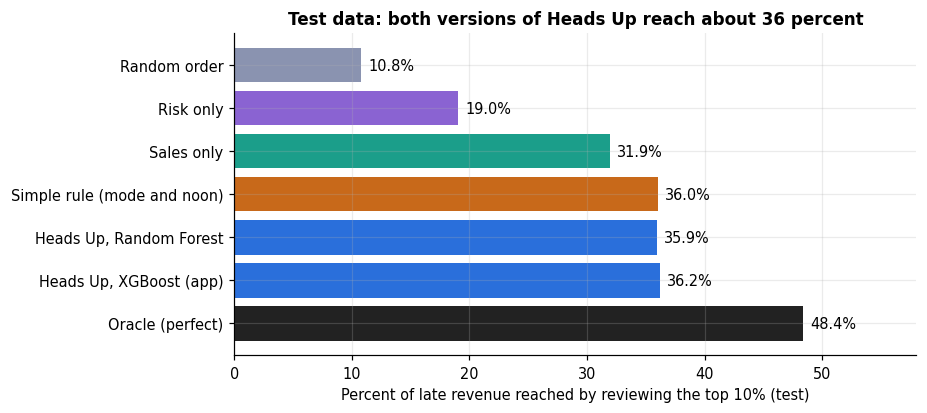

In [74]:
print(json.dumps(pcfg, indent=1)[:600])
# the same ranking, with the live app model
pa_va, pa_te = xgb_va, xgb_te
prx_va = pa_va * raw_va.Sales.values
qc_x, qh_x = np.quantile(prx_va, [.90, .70])
print(f'\nApp model cut points on validation: Critical {qc_x:.1f}, High {qh_x:.1f}   (app config: {cfg["tier_cutoffs"]["critical_min"]:.1f} and {cfg["tier_cutoffs"]["high_min"]:.1f})')
assert abs(qc_x - cfg['tier_cutoffs']['critical_min']) < 1 and abs(qh_x - cfg['tier_cutoffs']['high_min']) < 1

S_te = raw_te.Sales.values; late_rev_te = (S_te * y_te).sum(); rng = np.random.default_rng(SEED)
def reached_k(sc, k=.10):
    idx = np.argsort(-sc, kind='stable')[:int(len(sc) * k)]; return (S_te[idx] * y_te[idx]).sum() / late_rev_te, y_te[idx].mean()
rule_te = rule_key(raw_te).map(rate_key).values * S_te
cmp_app = pd.DataFrame({k: reached_k(v) for k, v in {'Random order': rng.random(len(y_te)), 'Risk only': pa_te + 1e-12 * S_te, 'Sales only': S_te, 'Simple rule (mode and noon)': rule_te,
                                                     'Heads Up, Random Forest': p_te * S_te, 'Heads Up, XGBoost (app)': pa_te * S_te, 'Oracle (perfect)': y_te * S_te + 1e-9 * S_te}.items()},
                        index=['Late revenue reached in the top 10%', 'Share really late in the top 10%']).T
display((cmp_app * 100).round(1))
fig, ax = plt.subplots(figsize=(8, 3.8)); v = cmp_app['Late revenue reached in the top 10%'] * 100
ax.barh(v.index, v.values, color=[GREY, PURPLE, TEAL, ORANGE, BLUE, BLUE, '#222']); ax.invert_yaxis()
for i, x_ in enumerate(v.values): ax.text(x_ + .6, i, f'{x_:.1f}%', va='center')
ax.set_xlim(0, 58); ax.set_xlabel('Percent of late revenue reached by reviewing the top 10% (test)'); ax.set_title('Test data: both versions of Heads Up reach about 36 percent'); plt.show()

**What we found:** both versions of Heads Up (Random Forest and XGBoost) reach about 36 percent of late revenue in the top 10 percent of the test data, the same as the simple rule, and far more than random order (11 percent), risk only (19 percent) or Sales only (32 percent). The perfect oracle would reach about 48 percent.

### Summary of Part 6 in plain words

**What we built:** a score for every order, chance of being late times Sales. Orders with the highest score are handled first.

1. **The chances are honest.** When the model says 80 percent, about 80 percent of those orders are really late. The only weak group is the lowest risk one.
2. **Using both risk and money works best.** Risk only fills the queue with cheap orders. Sales only picks big orders that are often not late. Together they reach the most late revenue.
3. **We reach about three quarters of the best possible result** (validation: 27 percent against 35 percent for the oracle).
4. **A simple rule ties the model for ordering the queue.** We state this openly. The model still gives a chance for each order, and SHAP explains it.
5. **Balanced is the best setting.** Giving more weight to risk cleans the queue but reaches less money.
6. **Order values dropped in the test period.** The average order was about 590 to 610 before and about 400 in the test period. In real use, the tier cut points must be updated with recent data.
7. **The tiers work.** In validation, Critical orders were 86 percent late and held 27 percent of all late revenue with only 10 percent of the orders.

**Decision for the app:** rank by chance times Sales, flag orders with chance 0.38 or higher (0.39 for the XGBoost app model), show the three tiers, and explain each flagged order with SHAP.

# Part 7. Wrap up

## 7.1 Model and method comparison

One table with the main options we tried and what we learned.

,Method,Data and line,Recall,Precision,ROC AUC,Why it matters
0,Rule baseline (shipping mode only),"Validation, 0.5",0.535,0.839,0.727,Simple and clear. Weakest ranking.
1,Logistic Regression,"Validation, 0.5",0.554,0.838,0.739,Easy to read. Same as the linear SVM.
2,"Random Forest, default","Validation, 0.5",0.617,0.792,0.758,Best Recall at the default line.
3,"Neural Network, default","Validation, 0.5",0.586,0.846,0.765,Best ranking at defaults. Hard to explain and to run in a browser.
4,Voting and Stacking (4 tree models),"Validation, 0.5",0.597,0.830,0.764,No gain. The base models are too alike.
5,"Random Forest, tuned (report model)","Test, 0.38",0.882,0.606,0.752,Highest Recall. Larger file (about 21 MB).
6,"XGBoost, tuned (live app model)","Test, 0.39",0.855,0.631,0.772,Better ranking. Tiny file (0.88 MB). Runs in the browser.


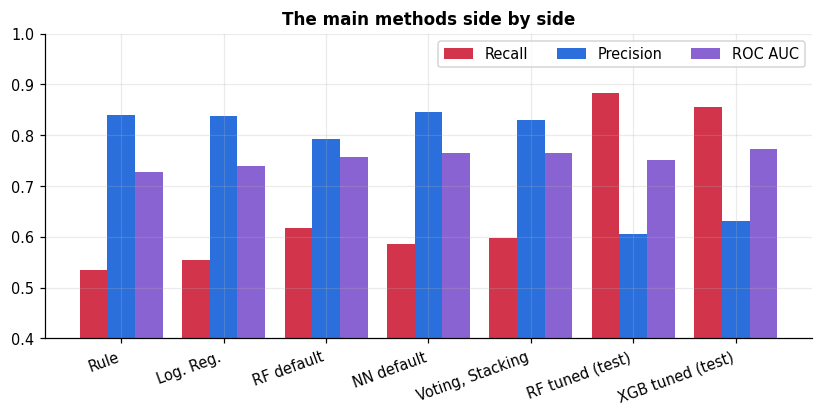

In [75]:
cmp = pd.DataFrame([
 ['Rule baseline (shipping mode only)', 'Validation, 0.5', lb.loc['Rule baseline', 'recall'], lb.loc['Rule baseline', 'precision'], lb.loc['Rule baseline', 'roc_auc'], 'Simple and clear. Weakest ranking.'],
 ['Logistic Regression', 'Validation, 0.5', lb.loc['Logistic Regression', 'recall'], lb.loc['Logistic Regression', 'precision'], lb.loc['Logistic Regression', 'roc_auc'], 'Easy to read. Same as the linear SVM.'],
 ['Random Forest, default', 'Validation, 0.5', lb.loc['Random Forest', 'recall'], lb.loc['Random Forest', 'precision'], lb.loc['Random Forest', 'roc_auc'], 'Best Recall at the default line.'],
 ['Neural Network, default', 'Validation, 0.5', lb.loc['Neural Network (PyTorch)', 'recall'], lb.loc['Neural Network (PyTorch)', 'precision'], lb.loc['Neural Network (PyTorch)', 'roc_auc'], 'Best ranking at defaults. Hard to explain and to run in a browser.'],
 ['Voting and Stacking (4 tree models)', 'Validation, 0.5', lb.loc['Stacking Classifier', 'recall'], lb.loc['Stacking Classifier', 'precision'], lb.loc['Stacking Classifier', 'roc_auc'], 'No gain. The base models are too alike.'],
 ['Random Forest, tuned (report model)', f'Test, {THR_RF}', final.iloc[0]['Recall'], final.iloc[0]['Precision'], final.iloc[0]['ROC AUC'], 'Highest Recall. Larger file (about 21 MB).'],
 ['XGBoost, tuned (live app model)', f'Test, {THR_XGB}', final.iloc[1]['Recall'], final.iloc[1]['Precision'], final.iloc[1]['ROC AUC'], 'Better ranking. Tiny file (0.88 MB). Runs in the browser.'],
], columns=['Method', 'Data and line', 'Recall', 'Precision', 'ROC AUC', 'Why it matters'])
display(cmp.round(3))
fig, ax = plt.subplots(figsize=(9, 3.6)); x = np.arange(len(cmp)); w = .27
for j, (c, colr) in enumerate([('Recall', RED), ('Precision', BLUE), ('ROC AUC', PURPLE)]): ax.bar(x + (j - 1) * w, cmp[c], w, label=c, color=colr)
ax.set_xticks(x); ax.set_xticklabels(['Rule', 'Log. Reg.', 'RF default', 'NN default', 'Voting, Stacking', 'RF tuned (test)', 'XGB tuned (test)'], rotation=20, ha='right'); ax.set_ylim(.4, 1); ax.legend(ncol=3); ax.set_title('The main methods side by side')
plt.show()

**Reading the table:** the first five rows are scored on validation data at the default 0.5 line. The last two rows are the final tuned models on the test data at their chosen lines, so the Recall values in the last two rows are higher mainly because the alert line is lower and more orders are flagged, not because the models changed.

### Method choices in one view

| Choice | What we did | Why |
|---|---|---|
| Unit | One row per order | A delivery is late for the whole order |
| Split | By time (70, 12 and 18 percent) | Real use predicts the future |
| Leakage control | Drop after delivery columns. Learn encodings and scaling on train only | Honest scores |
| Baseline | Shipping mode rule (a first version that used region was broken and fixed) | Every model must beat a fair floor |
| Models | One baseline and eleven models from five families | Test whether complexity helps |
| Tuning goal | PR AUC for XGBoost and Neural Network, Recall for Random Forest | A Recall goal made XGBoost worse in ranking |
| Main metric | Recall, then Precision and ranking quality | A miss costs more than a false alarm |
| Threshold | Highest line with validation Recall at least 0.80 | A cost ratio flagged 97 percent of orders |
| Explanation | SHAP | Built in importance charts disagreed |
| Ranking | Risk times Sales, three tiers | A team can only act on a short list |

## 7.2 The web app

The model is wrapped in a web app so that a non technical user can use it without any code. The live site is at https://huggingface.co/spaces/nayanasisil2700/heads-up and the code is in the `app` folder.

* **Check an order:** type the order details and see the risk, the tier, and a waterfall of reasons.
* **Orders to handle:** the ranked queue with Critical, High and Standard tiers and a threshold slider.
* **Noon heat map:** the hour and shipping mode picture from Part 1.
* **Technical pages:** one page for each part of this notebook, and the full decision log.

The XGBoost model runs inside the browser (no server needed). A Python copy of the same model sits behind a FastAPI backend, and the two are tested to give the same answer (16 automated tests).

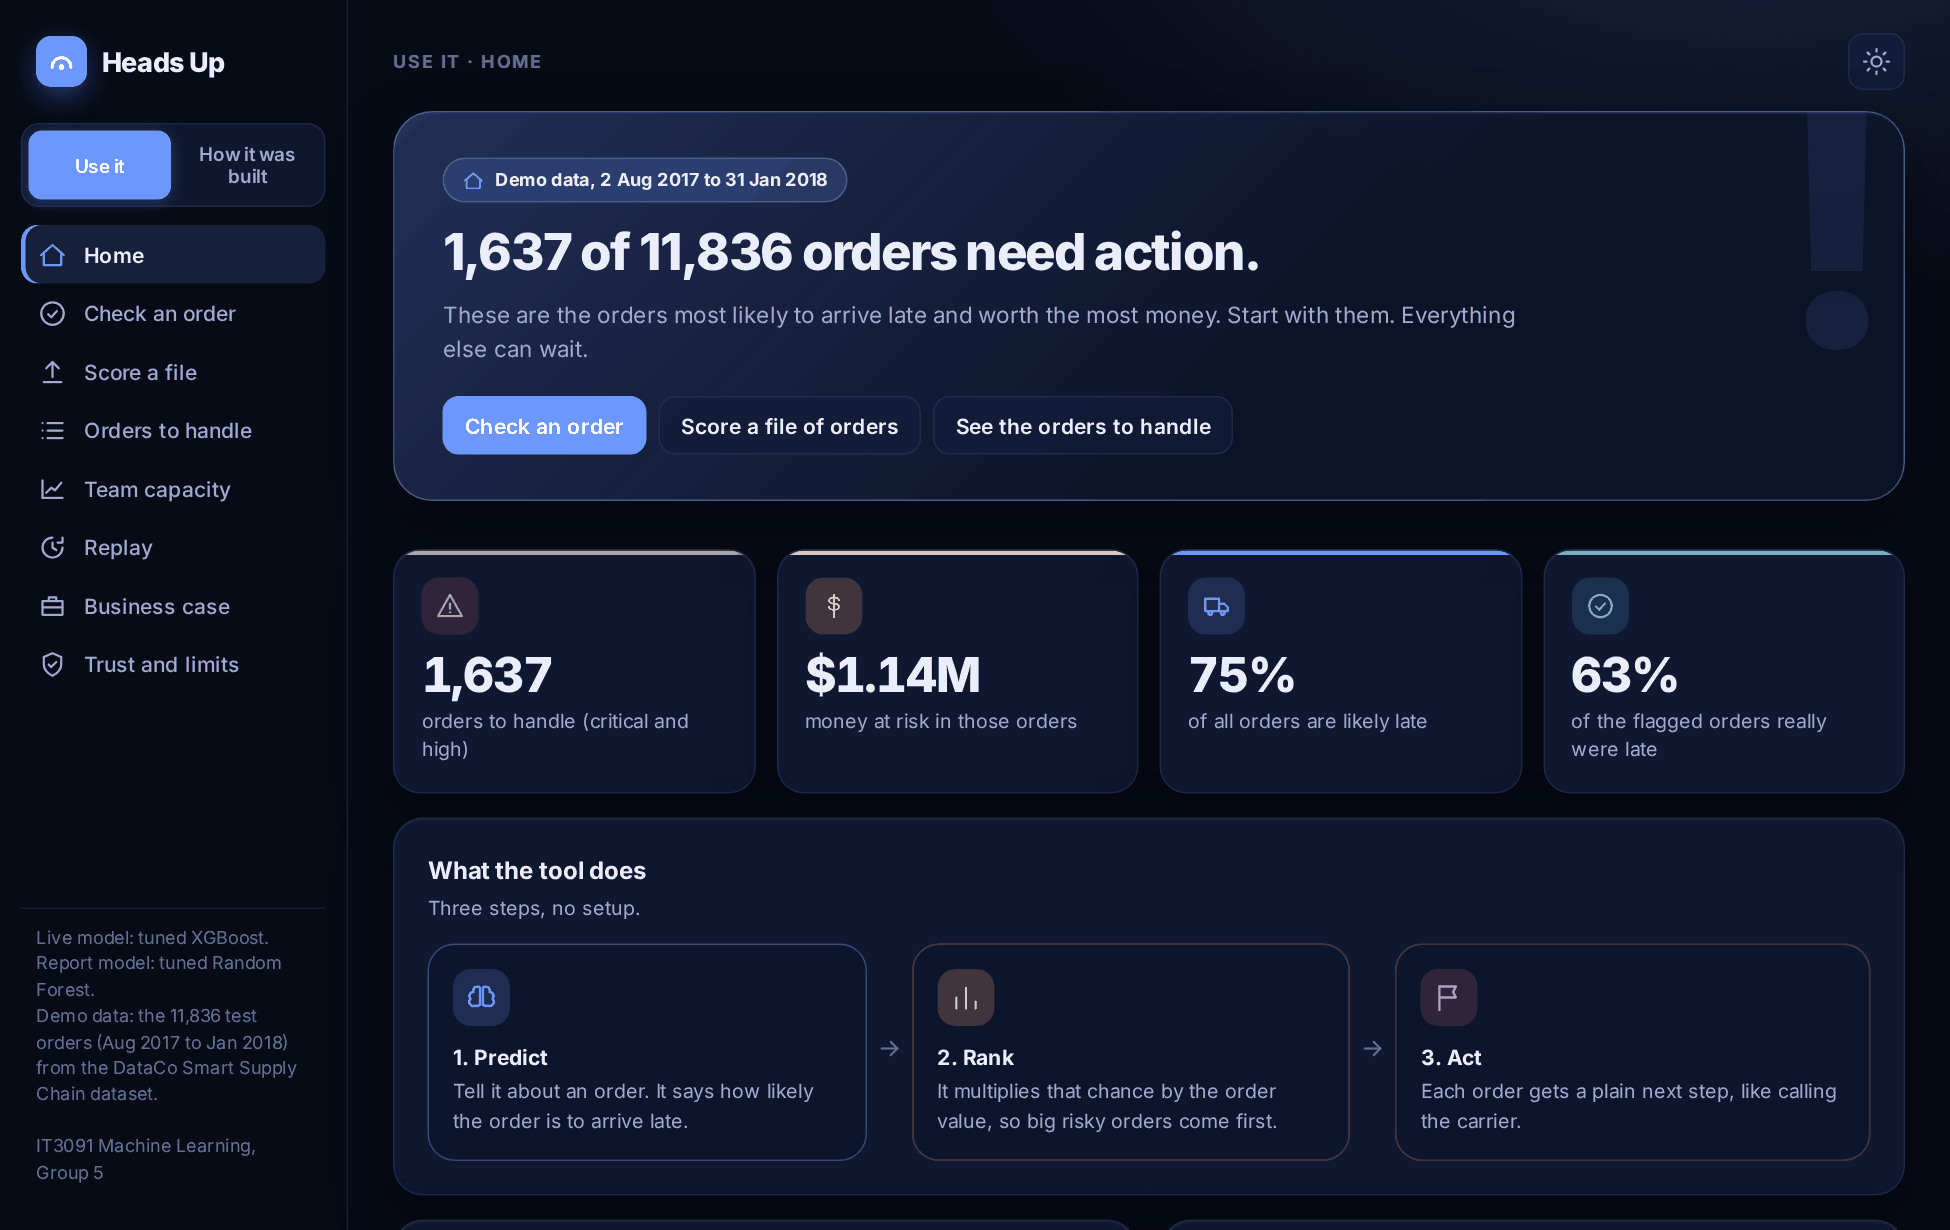

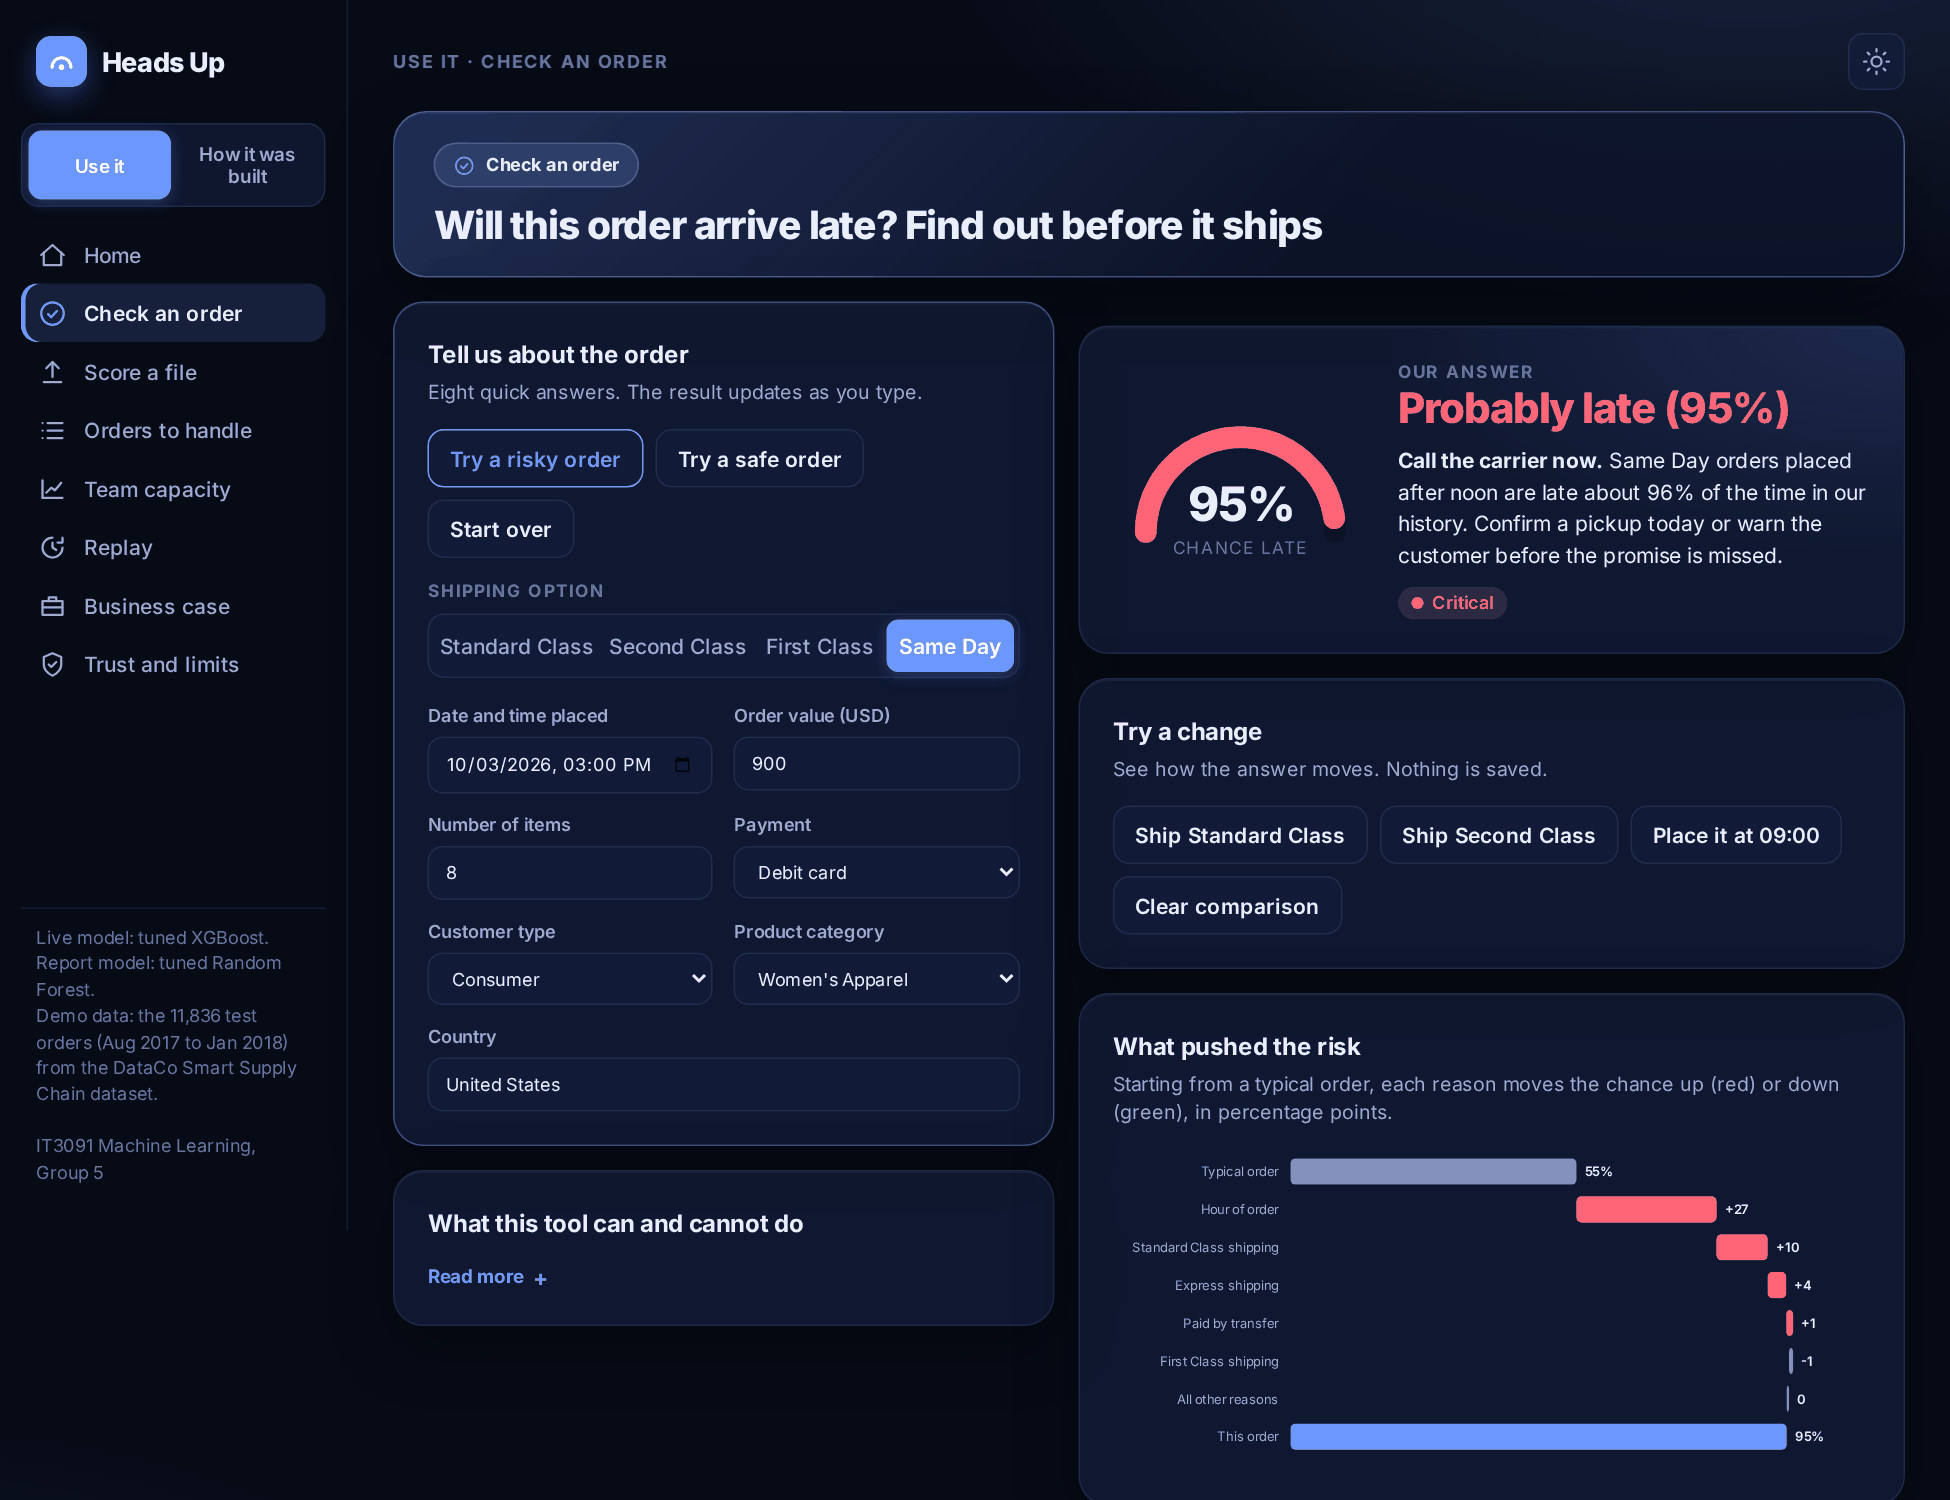

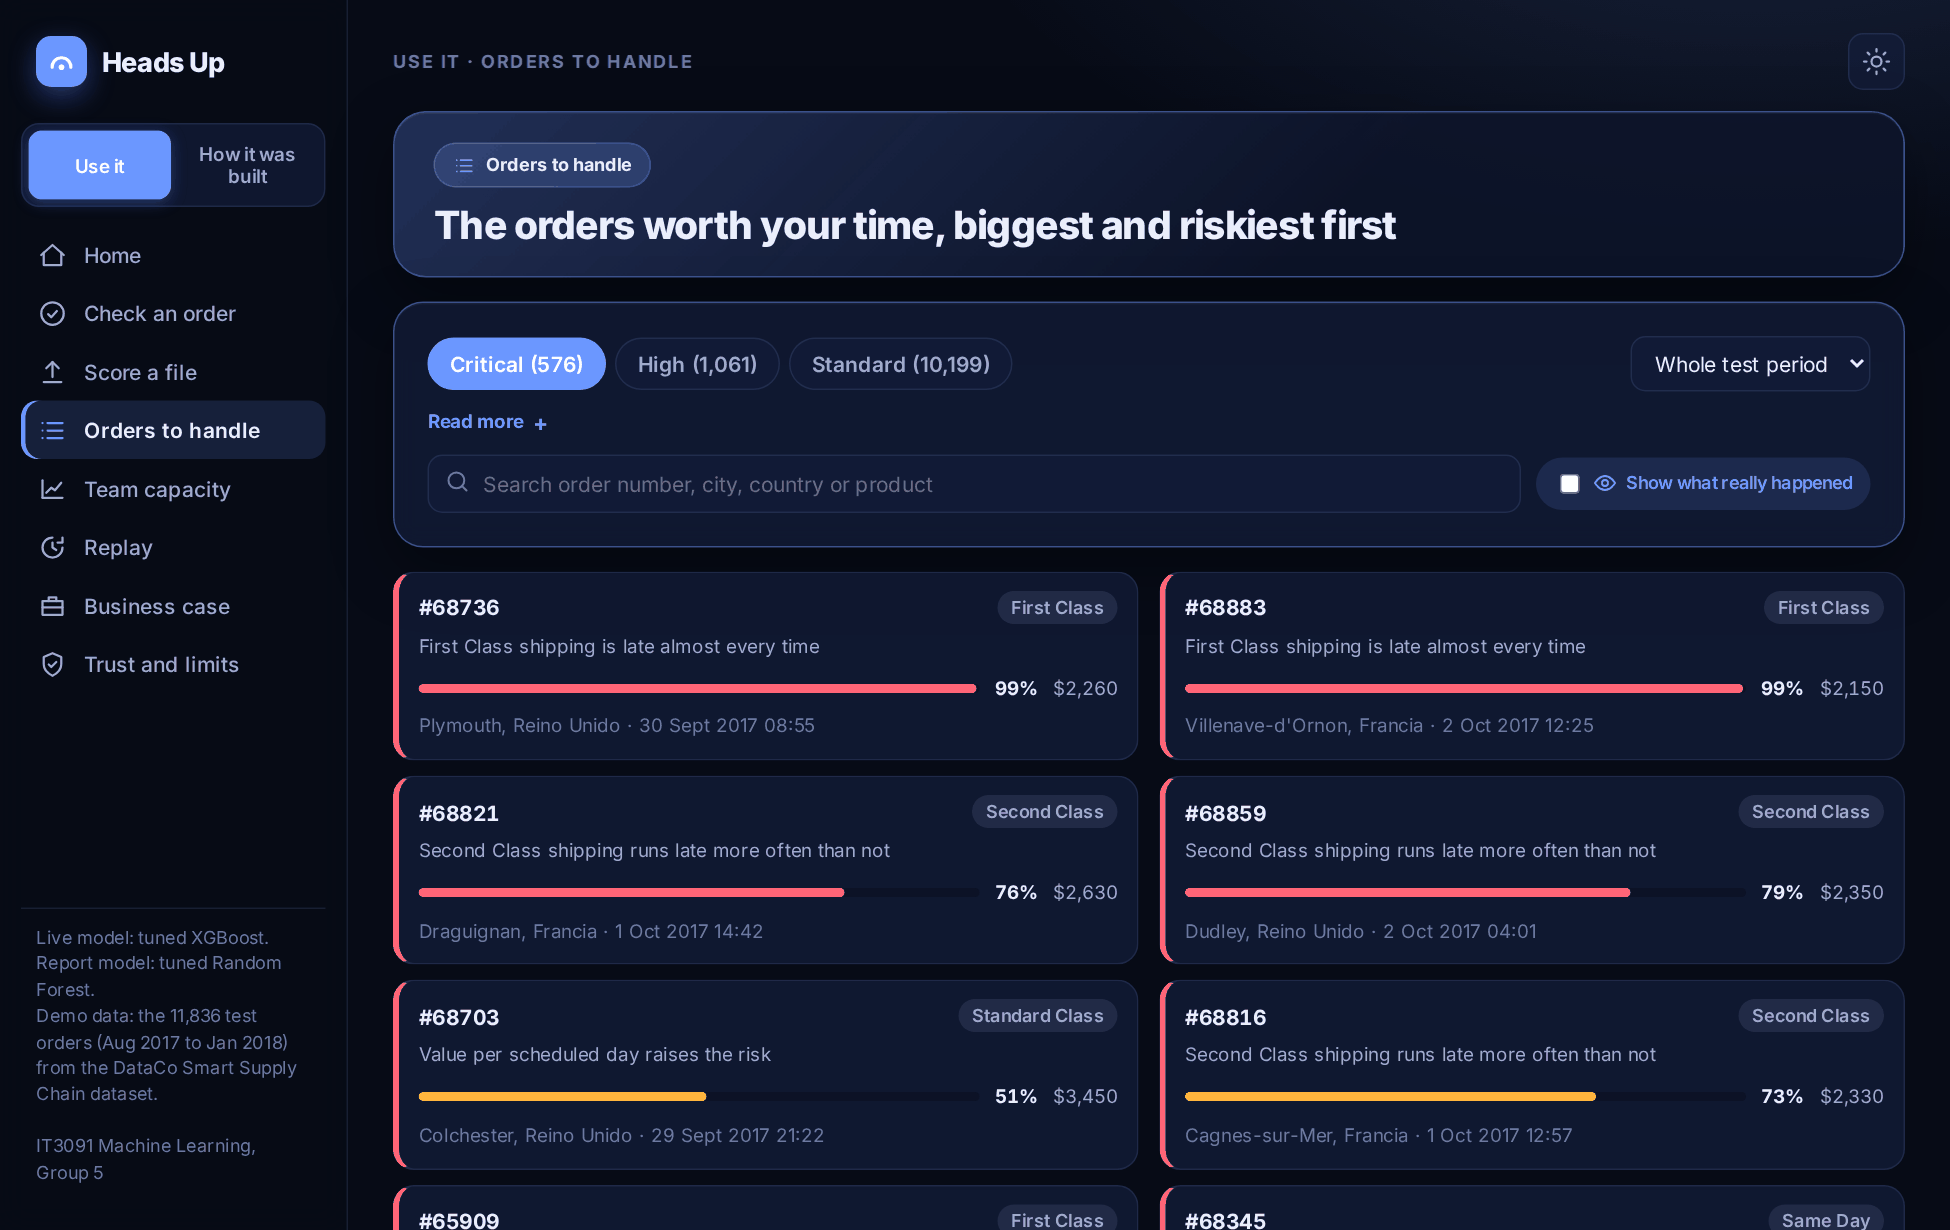

In [76]:
for f in ['01-home.png', '02-check-an-order.png', '03-orders-to-handle.png']:
    p = ROOT / 'docs' / 'images' / f
    if p.exists(): display(Image(filename=str(p), width=720))

## 7.3 Decision log

Every important choice was written down with the date, the options we considered and the reason. The full file is `DECISION_LOG.md` in the project root. Here is the list of all entries by stage, read straight from that file.

47 decisions recorded


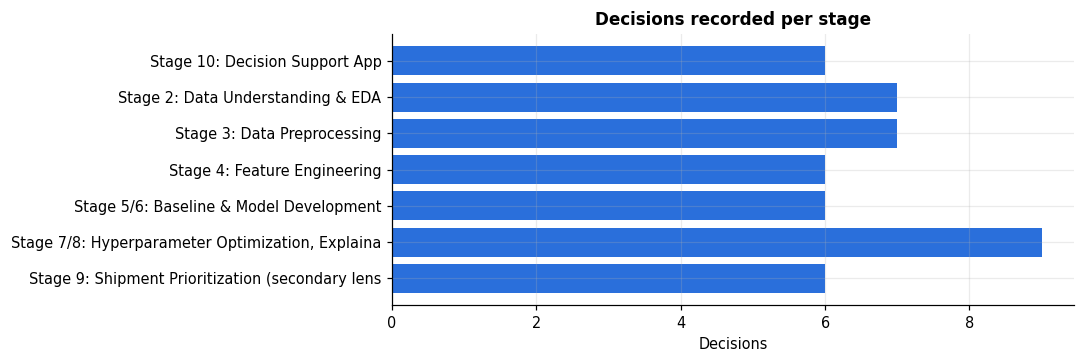

,Stage,Date,Decision
0,Stage 2: Data Understanding & EDA,2026-09-10,Unit of analysis: aggregate to Order Id
1,Stage 2: Data Understanding & EDA,2026-09-12,Primary evaluation metric: Recall
2,Stage 2: Data Understanding & EDA,2026-09-15,Recall justification revisited after EDA
3,Stage 2: Data Understanding & EDA,2026-09-15,Shipping canceled orders stay coded as not late
4,Stage 2: Data Understanding & EDA,2026-09-17,"Train/test split: chronological by proportion, not calendar year"
5,Stage 2: Data Understanding & EDA,2026-09-17,Order Country naming appears to need standardizing
6,Stage 2: Data Understanding & EDA,2026-09-17,"Benefit per order: outliers found, treatment deferred"
7,Stage 3: Data Preprocessing,2026-09-16,Order-level aggregation rule per column
8,Stage 3: Data Preprocessing,2026-09-17,"Category Name/Id require mode, not first, and two new features added"
9,Stage 3: Data Preprocessing,2026-09-17,Order Zipcode dropped entirely


In [77]:
text = (ROOT / 'DECISION_LOG.md').read_text(encoding='utf-8')
stage, rows = '', []
for line in text.splitlines():
    if line.startswith('## '): stage = line[3:].strip()
    m = re.match(r'### \[(.*?)\]\s*(.*)', line)
    if m and 'YYYY' not in m.group(1): rows.append([stage, m.group(1), m.group(2)])
dl = pd.DataFrame(rows, columns=['Stage', 'Date', 'Decision'])
print(len(dl), 'decisions recorded')
cnt = dl.groupby('Stage').size()
fig, ax = plt.subplots(figsize=(8, 3.2)); ax.barh(cnt.index.str.slice(0, 48), cnt.values, color=BLUE); ax.invert_yaxis(); ax.set_xlabel('Decisions'); ax.set_title('Decisions recorded per stage'); plt.show()
dl

## 7.4 Limits and lessons

**What the model can and cannot do**

* The ranking skill is **modest** (ROC AUC about 0.75 to 0.77). The information available at order time explains part of lateness, not all of it. Weather, port delays and carrier load are not in the data.
* Our alarms are **noisy by design.** To catch 80 percent or more of late orders we accept that about 4 in 10 alarms are false. At the chosen line the model is only about 5 points of Precision above "flag everything", and the team must still look at most orders.
* **Late is the normal case here** (55 percent), so Precision looks good even for a weak model. We therefore look at Recall, ranking quality and revenue reached together.
* A **simple rule** (shipping mode plus the noon cliff, times Sales) ties the model for ranking the top 10 percent by revenue. The model's real extras are a separate chance for every order, the explanation and the tiers.
* The top of the ranking is **mostly a shipping mode result** (First Class and Same Day after noon).
* The noon cliff is so clean (0 percent against 96 percent) that it may be a **rule built into this dataset**, stronger than real operations would show.
* The **test Recall of 0.88 is partly a result of flagging 80 percent of orders** (70 percent on validation). A fixed threshold does not give the same workload on later data, so it must be re checked.
* Order values were lower in the test period (about 400 against about 600), so the tier cut points need regular updating.
* The data covers **2015 to 2018** and one company. It may not carry over to other firms or years without retraining.
* `Shipping canceled` orders are labelled "not late". This is a documented choice, not a fact.
* Region and country effects must lead to **extra support**, never to worse service for those places.
* The Random Forest result is the best of 50 tries on one validation set, which is slightly optimistic. The test set confirmed the ranking quality (ROC AUC fell only 0.01).

**What we learned**

1. Check for leakage first. Many columns look useful and are not available at order time.
2. Split by time, not at random, and learn encodings and scaling on training data only.
3. Check surprising results before believing them (the broken baseline, the SVM that had not converged, the misleading importance charts, the XGBoost Recall search that only moved the line).
4. A cost ratio can be the wrong tool. When most orders are late, it says "flag everything".
5. The threshold matters more than the model name. Eleven models landed within a few points of each other in ranking.
6. A simple, honest baseline is a strong teacher. It showed where the model really adds value.
7. A good explanation and a small model make adoption easier than a few more points of accuracy.
8. Writing decisions down as we went made the report and the app much easier to build.

## 7.5 Where to find everything we submit

| Requirement | Where it lives |
|---|---|
| Final notebook and code | This notebook, plus `src`, `notebooks` and `app` |
| Dataset and data dictionary | `data/raw data`, Part 1 section 1.2 of this notebook, and `data/processed/data_dictionary_raw_columns.csv` |
| Decision logs | `DECISION_LOG.md` (index in section 7.3) |
| Model and method comparison | Part 4 section 4.8, Part 5 sections 5.5 and 5.9, and section 7.1 |
| Live demo | https://huggingface.co/spaces/nayanasisil2700/heads-up |

---
Group 5, IT3091 Machine Learning. Data: DataCo Smart Supply Chain (public dataset).